**Overview**

In this section, we import the Python libraries required for data analysis, statistical analysis, and visualization of the agricultural dataset.

Why are we doing this?

Different libraries provide different tools:

Pandas → loading and manipulating the dataset

NumPy → numerical calculations

Matplotlib → creating visualizations

Seaborn → creating statistical and advanced visualizations

SciPy → statistical analysis

In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Set visualization style
sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


**Understand Dataset Shape & Structure**

📌 **Overview**

Before cleaning or analyzing the agricultural data, we need to understand the overall structure of the dataset. We will check how many rows and columns are present and examine the column names.

Why are we doing this?
Knowing the dataset's dimensions and structure helps us understand the amount of data available and identify the variables that can be used for seasonal, environmental, resource, production, and economic analysis.

In [ ]:
# Load the agriculture dataset
df=pd.read_csv('/content/seasonal_agriculture_performance_dataset (1).csv')
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
# Check the number of rows and columns

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


In [ ]:
# Display all column names

print("Column names:")
for column in df.columns:
    print(column)

Column names:
Farm_ID
State
District
Crop
Season
Farm_Area_Hectares
Rainfall_mm
Avg_Temperature_C
Humidity_pct
Sunlight_Hours_Day
Soil_pH
Soil_Moisture_pct
Nitrogen_kg_ha
Phosphorus_kg_ha
Potassium_kg_ha
Irrigation_Method
Fertilizer_kg_ha
Pesticide_Litre_ha
Seed_Quality_Score
Yield_Tonnes_Ha
Production_Tonnes
Market_Price_INR_Tonne
Total_Cost_INR
Revenue_INR
Profit_INR
Water_Used_m3
Water_Efficiency_t_per_1000m3
Disease_Pest_Risk_pct


In [ ]:
# Display basic dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
# Check for missing values in each column

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values[missing_values > 0])

Missing values in each column:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


In [ ]:
# Calculate the total number of missing values

total_missing = df.isnull().sum().sum()

print("Total missing values:", total_missing)

Total missing values: 120


**Handle Missing Values**

For these three numerical columns, we'll use the median rather than deleting 120 rows. This preserves the dataset size and reduces the influence of extreme values.

In [ ]:
# Fill missing numerical values with their median

df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].median())
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df['Yield_Tonnes_Ha'].median())

# Verify missing values after treatment
print("Total missing values after treatment:", df.isnull().sum().sum())

Total missing values after treatment: 0


In [ ]:
# Check for duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [ ]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,600.922825,26.81890,63.210500,7.323050,6.701010,26.507150,120.250825,57.781850,104.760050,...,0.826138,5.242350,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,287.193381,3.81818,11.960834,1.121186,0.641461,6.678837,31.216452,17.015074,27.742681,...,0.101747,13.311549,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,371.575000,23.90000,54.775000,6.600000,6.260000,21.800000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,831.975000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.830000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


**Investigate Outliers using IQR Method**

📌 **Overview**

Outliers are data points that significantly deviate from other observations. In agricultural datasets, extreme values can be valid (e.g., exceptionally high yields due to optimal conditions or very low yields due to adverse events). Therefore, we will identify potential outliers but will not automatically remove them.

Why are we doing this?
Understanding the distribution of our data, including the presence and magnitude of outliers, is crucial for accurate analysis. The IQR method helps us systematically identify these points without making assumptions about the data's distribution. This step is important for understanding the range and variability of agricultural performance, environmental factors, and economic metrics.

In [ ]:
# Select only numerical columns for outlier detection
numerical_cols = df.select_dtypes(include=np.number).columns

outliers_summary = {}

for column in numerical_cols:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    outliers_count = len(outliers)

    if outliers_count > 0:
        outliers_summary[column] = outliers_count

print("Number of outliers detected using IQR method (by column):")
if outliers_summary:
    for col, count in outliers_summary.items():
        print(f"- {col}: {count}")
else:
    print("No outliers detected in numerical columns.")

# As per project instructions, we will not automatically remove outliers.
# Agricultural data can naturally contain extreme observations that are valid.

Number of outliers detected using IQR method (by column):
- Avg_Temperature_C: 2
- Humidity_pct: 6
- Sunlight_Hours_Day: 26
- Soil_Moisture_pct: 5
- Nitrogen_kg_ha: 10
- Phosphorus_kg_ha: 16
- Potassium_kg_ha: 32
- Fertilizer_kg_ha: 15
- Pesticide_Litre_ha: 8
- Yield_Tonnes_Ha: 302
- Production_Tonnes: 333
- Revenue_INR: 240
- Profit_INR: 404
- Water_Used_m3: 276
- Water_Efficiency_t_per_1000m3: 322
- Disease_Pest_Risk_pct: 10


## **5. Exploratory Data Analysis (EDA)**

📌 **Overview**

Exploratory Data Analysis (EDA) is a critical step in any data analysis project. It involves summarizing the main characteristics of the data, often with visual methods. EDA helps in understanding the data distribution, identifying relationships between variables, detecting anomalies, and formulating hypotheses for further analysis.

Why are we doing this?
EDA provides a deeper understanding of the dataset's underlying structure, patterns, and trends. This knowledge is essential for making informed decisions about feature engineering, model selection, and drawing meaningful insights and recommendations related to agricultural performance, seasonal differences, and resource management.

### **Univariate Analysis: Distribution of Categorical Variables**

📌 **Overview**

Univariate analysis involves examining individual variables independently. For categorical variables, we focus on understanding the frequency and proportion of each category. This helps us grasp the composition of our dataset in terms of factors like `Crop`, `Season`, and `Irrigation_Method`.

Why are we doing this?
Understanding the distribution of categorical variables reveals the most common crops grown, the prevalence of different seasons in the data, and the primary irrigation methods used. This foundational knowledge is crucial for subsequent analyses, such as comparing yield or profit across different categories, and identifying areas for deeper investigation.

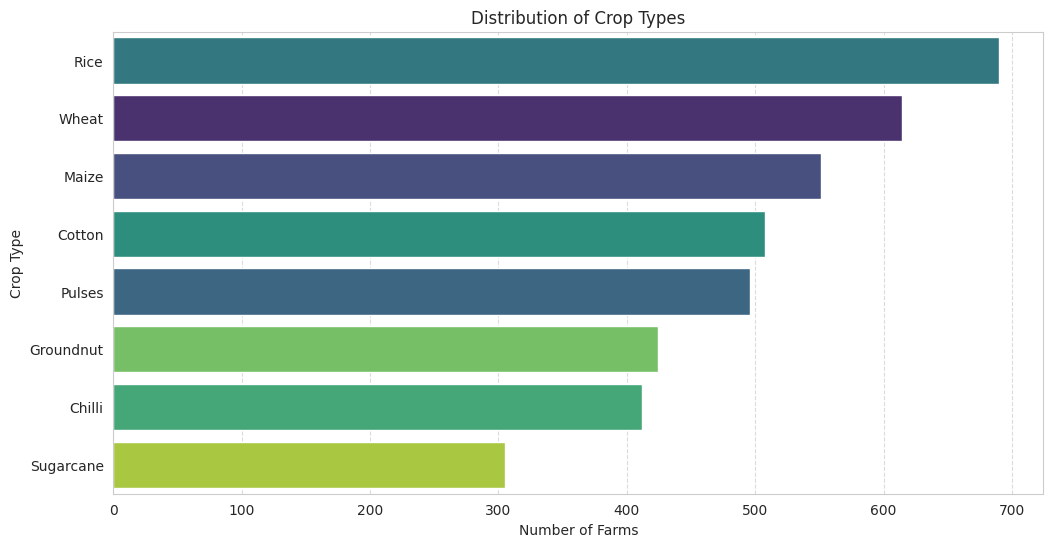

In [ ]:
# Analyze the distribution of 'Crop' types
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Crop', order=df['Crop'].value_counts().index, hue='Crop', palette='viridis')
plt.title('Distribution of Crop Types')
plt.xlabel('Number of Farms')
plt.ylabel('Crop Type')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#### **Observation on Crop Distribution**

From the bar chart, we can observe the following:

*   **Rice** and **Wheat** are the most frequently recorded crops in the dataset, indicating they are widely cultivated.
*   **Maize**, **Cotton**, and **Pulses** also show significant representation.
*   **Sugarcane**, **Chilli**, and **Groundnut** appear to be cultivated less frequently compared to the top crops in this dataset.

This distribution provides initial insights into the primary agricultural activities captured in the dataset, which can influence further analyses regarding crop-specific performance and resource allocation.

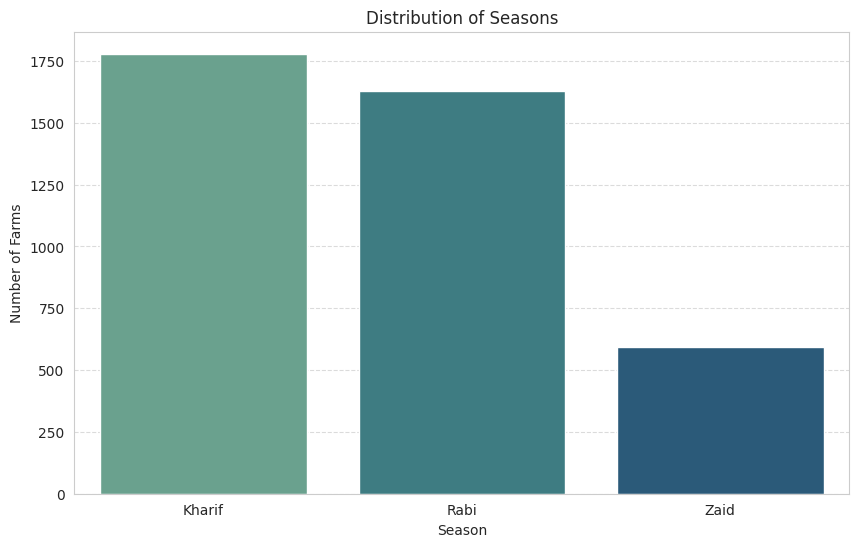

In [ ]:
# Analyze the distribution of 'Season'
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Season', order=df['Season'].value_counts().index, hue='Season', palette='crest')
plt.title('Distribution of Seasons')
plt.xlabel('Season')
plt.ylabel('Number of Farms')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Observation on Season Distribution**

From the bar chart showing the distribution of seasons, we can deduce:

*   The **Kharif** and **Rabi** seasons appear to be the most predominant cultivation periods in the dataset, with a higher number of farms reporting activities during these times.
*   The **Zaid** season shows comparatively fewer farm records. This is typical, as Zaid is a shorter, summer cropping season often involving less cultivation than the main Kharif and Rabi seasons.

This distribution highlights the seasonal focus of agricultural activities within the dataset, which will be crucial for the seasonal analysis section.

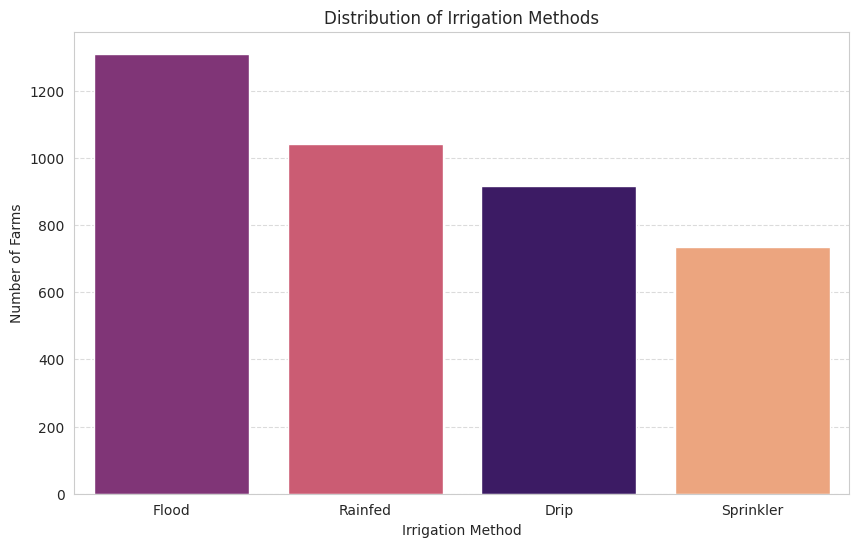

In [ ]:
# Analyze the distribution of 'Irrigation_Method'
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Irrigation_Method', order=df['Irrigation_Method'].value_counts().index,hue='Irrigation_Method',palette='magma')
plt.title('Distribution of Irrigation Methods')
plt.xlabel('Irrigation Method')
plt.ylabel('Number of Farms')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Observation on Irrigation Method Distribution**

From the bar chart depicting the distribution of irrigation methods, we can observe:

*   **Flood irrigation** is the most common method reported in the dataset, followed closely by **Rainfed** agriculture.
*   **Drip** and **Sprinkler** irrigation methods are also utilized but appear less frequently than Flood and Rainfed methods.

This distribution gives us an idea of the prevailing water management practices, which will be crucial when analyzing water usage, water efficiency, and their impact on agricultural performance across different methods.

### **Univariate Analysis: Distribution of Numerical Variables**

📌 **Overview**

For numerical variables, univariate analysis involves examining their central tendency, spread, and shape of distribution. Histograms and Kernel Density Estimates (KDEs) are effective tools for visualizing these characteristics, helping us understand the data's underlying patterns, identify potential skewness, and assess the presence of multiple modes.

Why are we doing this?
Understanding the distribution of key numerical variables such as yield, profit, rainfall, and temperature is fundamental. It allows us to identify common ranges, unusual values, and whether the data is concentrated or spread out. This analysis informs our understanding of agricultural performance metrics and environmental conditions, which is crucial for subsequent bivariate and multivariate analyses.

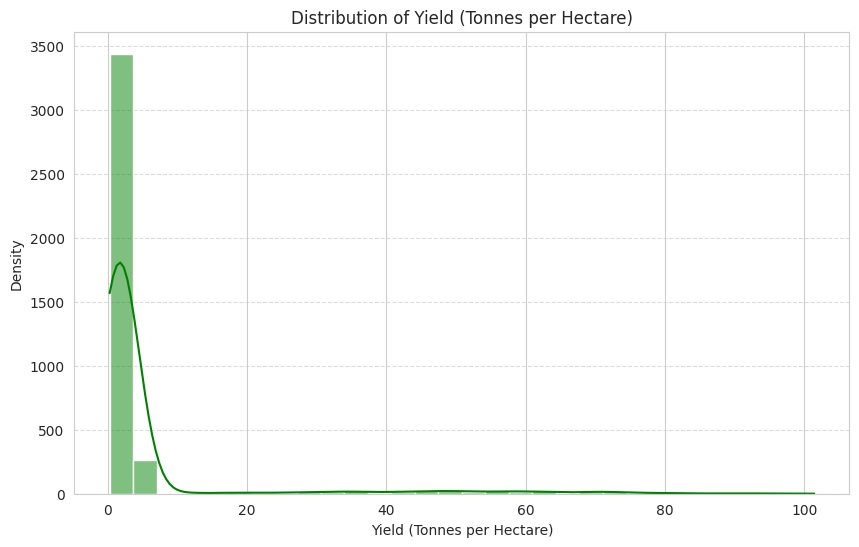

In [ ]:
# Visualize the distribution of 'Yield_Tonnes_Ha'

# Visualize the distribution of Yield_Tonnes_Ha

plt.figure(figsize=(10, 6))

sns.histplot(
    df['Yield_Tonnes_Ha'],
    kde=True,
    bins=30,
    color='green',
)

plt.title('Distribution of Yield (Tonnes per Hectare)')
plt.xlabel('Yield (Tonnes per Hectare)')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

#### **Observation on Yield Distribution**

From the histogram and KDE plot of `Yield_Tonnes_Ha`, we can observe the following:

*   The distribution is highly **right-skewed**, with a large concentration of farms having relatively low yields (between 0 and 5 tonnes/hectare).
*   The majority of data points are clustered at the lower end, indicating that most agricultural operations in the dataset experience moderate to low yields.
*   There are a few instances of very high yields, which appear as outliers and create the long tail in the distribution. These could represent highly productive farms or specific crop types under optimal conditions.

This skewed distribution suggests that while high yields are possible, they are not common across the entire dataset. Further analysis will be needed to understand the factors contributing to these variations, particularly what drives higher yields.

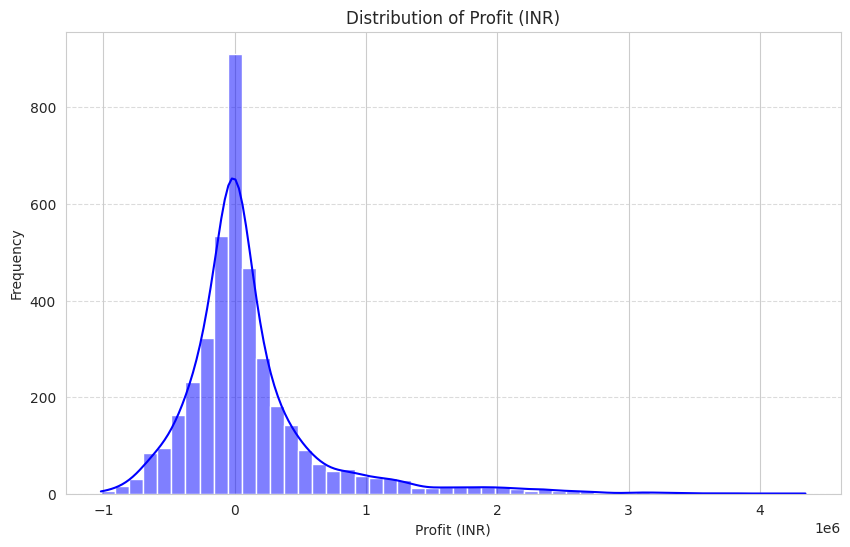

In [ ]:
# Visualize the distribution of 'Profit_INR'
plt.figure(figsize=(10, 6))
sns.histplot(df['Profit_INR'], kde=True, bins=50, color='blue')
plt.title('Distribution of Profit (INR)')
plt.xlabel('Profit (INR)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Observation on Profit Distribution**

From the histogram and KDE plot of `Profit_INR`, we can observe the following:

*   The distribution of profit is approximately **symmetrical around zero**, but with a significant number of data points showing **negative profit**, indicating losses for a substantial portion of farms.
*   There's a strong peak around the 0 INR mark, suggesting that many farms are operating at or near the break-even point, or experiencing slight losses.
*   The distribution has a **long tail to the right**, indicating that a few farms are generating very high profits, similar to how some farms have very high yields. This suggests a wide range of economic performance across the agricultural operations.
*   The presence of both significant losses and high profits points to considerable variability and potential risk in the agricultural sector represented by this dataset.

Further investigation into the factors contributing to both significant losses and high profits will be critical for understanding economic performance and making recommendations for profit optimization.

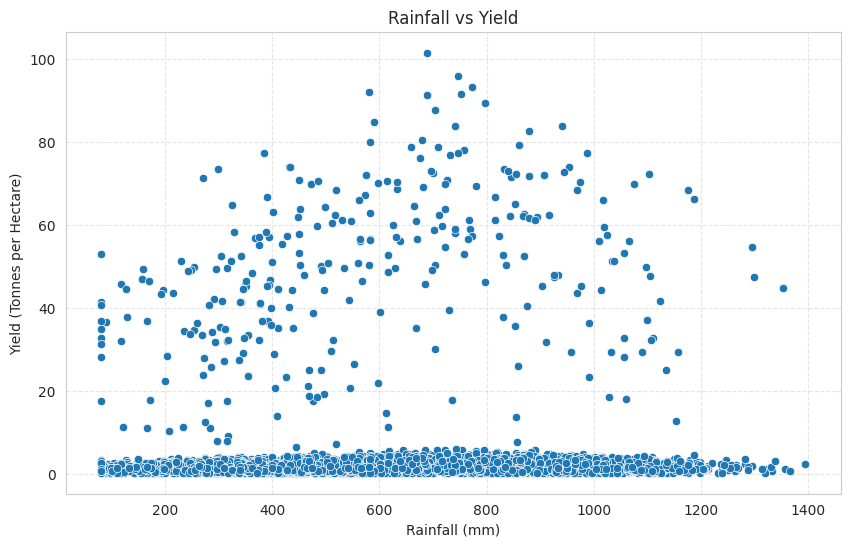

In [ ]:
# Rainfall vs Yield

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha'
)

plt.title('Rainfall vs Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes per Hectare)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

#### **Observation on Rainfall vs. Yield Relationship**

From the scatter plot of `Rainfall_mm` against `Yield_Tonnes_Ha`, we can observe the following:

*   There doesn't appear to be a strong linear correlation between rainfall and yield across the entire range of data. The points are quite scattered.
*   However, there seems to be a **concentration of higher yields (above 10-20 tonnes/hectare) within a certain range of rainfall**, roughly between 400 mm and 1000 mm. This suggests that while extremely low or high rainfall might be detrimental, an optimal range exists where higher yields are more probable.
*   At very low rainfall levels (below ~200-300 mm) and very high rainfall levels (above ~1200 mm), yields tend to be lower or clustered around the lower end.
*   The majority of farms with low yields (below 5 tonnes/hectare) are observed across almost the entire spectrum of rainfall, indicating that while rainfall is a factor, other variables likely play a significant role in determining very low yields.

This preliminary visual analysis suggests a non-linear or complex relationship, where moderate rainfall might be beneficial, but excessive or insufficient rainfall could negatively impact crop yield. Further statistical analysis (e.g., correlation coefficients for specific ranges, or multivariate analysis) would be needed to quantify this relationship more precisely.

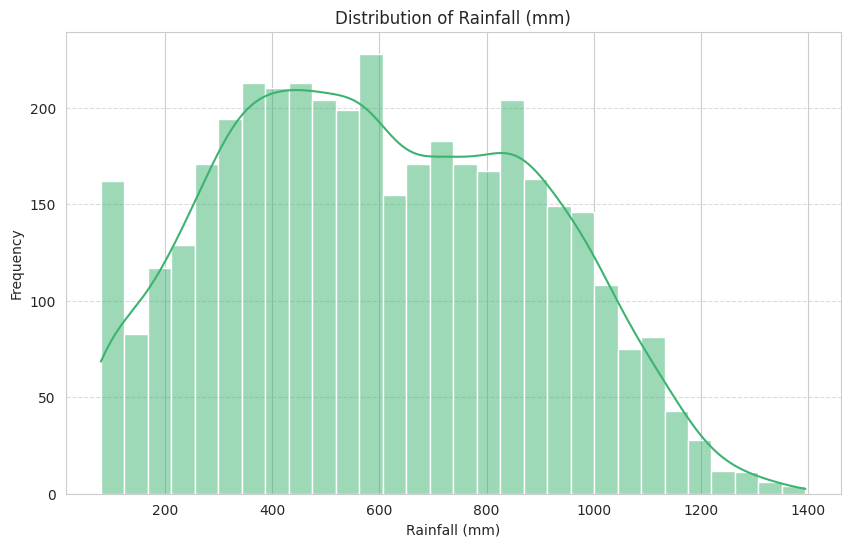

In [ ]:
# Visualize the distribution of 'Rainfall_mm'
plt.figure(figsize=(10, 6))
sns.histplot(df['Rainfall_mm'], kde=True, bins=30, color='mediumseagreen')
plt.title('Distribution of Rainfall (mm)')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Observation on Rainfall Distribution**

From the histogram and KDE plot of `Rainfall_mm`, we can observe the following:

*   The distribution of rainfall is generally **bell-shaped but with a slight positive skew**, indicating that while there is a peak around 400-600 mm, there are also instances of higher rainfall, extending the tail to the right.
*   The majority of farms experience rainfall within a moderate range, with fewer instances of very low or very high rainfall.
*   The presence of two peaks (bimodal or multimodal tendencies) could suggest different climatic conditions or seasonal patterns across the farms in the dataset. This might correspond to the Kharif and Rabi seasons, which typically have distinct rainfall patterns.

Understanding rainfall distribution is critical as it directly impacts water availability, irrigation needs, and crop yield, making it a key factor in seasonal agricultural performance.

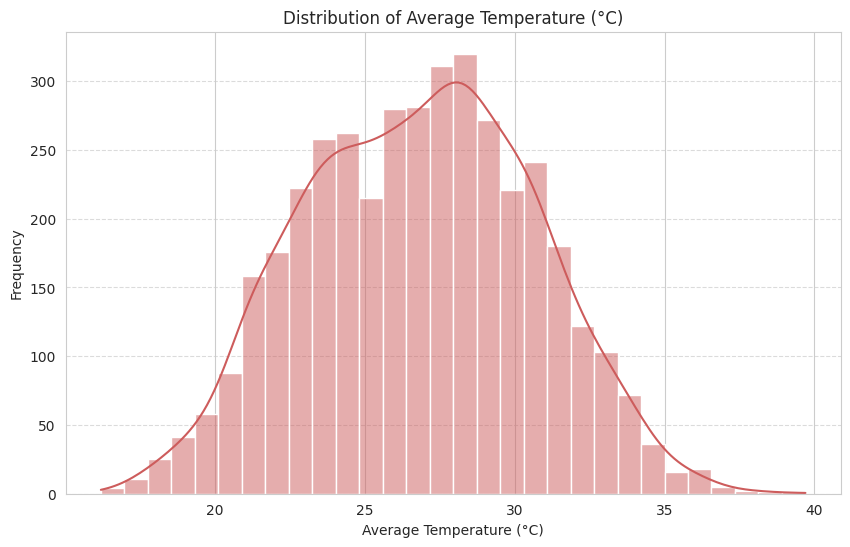

In [ ]:
# Visualize the distribution of 'Avg_Temperature_C'
plt.figure(figsize=(10, 6))
sns.histplot(df['Avg_Temperature_C'], kde=True, bins=30, color='indianred')
plt.title('Distribution of Average Temperature (°C)')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Observation on Average Temperature Distribution**

From the histogram and KDE plot of `Avg_Temperature_C`, we can observe the following:

*   The distribution of average temperature is approximately **bell-shaped and fairly symmetrical**, suggesting that temperatures generally fall within a normal range for agricultural regions.
*   There is a clear peak around **27-29°C**, indicating that a significant portion of farms experience average temperatures within this range.
*   The spread indicates that while most temperatures are concentrated around the mean, there are also farms experiencing both cooler (down to ~15°C) and warmer (up to ~35°C) average temperatures, reflecting diverse climatic conditions within the dataset.

Average temperature is a critical environmental factor influencing crop growth and development, and this distribution provides a baseline understanding for further analysis of its impact on yield and other performance metrics.

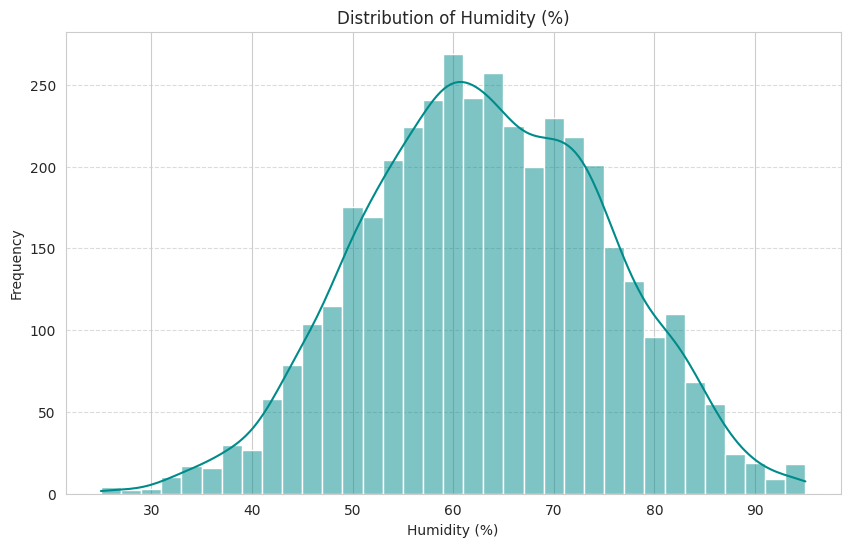

In [ ]:
# Visualize the distribution of 'Humidity_pct'
plt.figure(figsize=(10, 6))
sns.histplot(df['Humidity_pct'], kde=True, bins=35, color='darkcyan')
plt.title('Distribution of Humidity (%)')
plt.xlabel('Humidity (%)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Observation on Humidity Distribution**

From the histogram and KDE plot of `Humidity_pct`, we can observe the following:

*   The distribution of humidity is generally **bell-shaped and quite symmetrical**, indicating that most farms experience humidity levels within a moderate range.
*   There's a clear peak around **60-70% humidity**, suggesting this is the most common range in the dataset.
*   The spread of the distribution shows that while most humidity levels are concentrated around the mean, there are also farms experiencing both lower (down to ~25%) and higher (up to ~95%) humidity levels.

Humidity is a crucial environmental factor that affects crop transpiration, disease incidence, and overall plant health. Understanding its distribution helps in assessing the typical environmental conditions and potential challenges faced by farmers in the dataset.

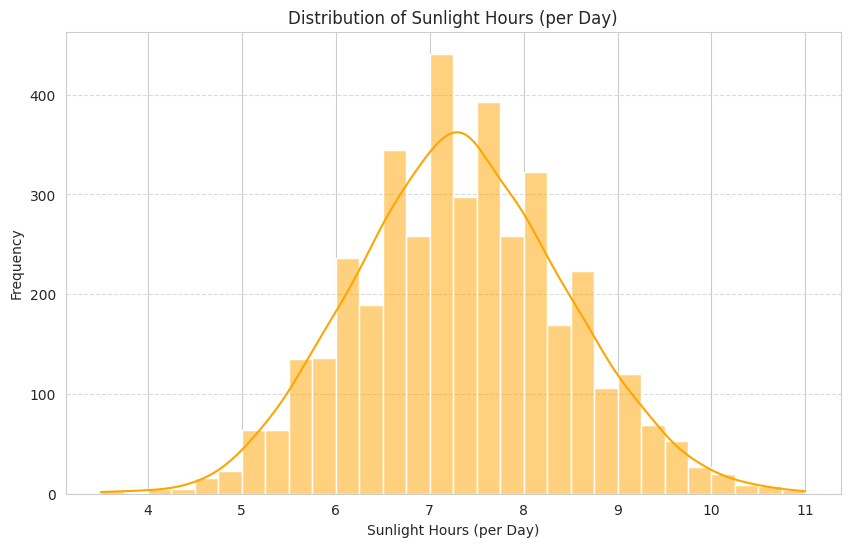

In [ ]:
# Visualize the distribution of 'Sunlight_Hours_Day'
plt.figure(figsize=(10, 6))
sns.histplot(df['Sunlight_Hours_Day'], kde=True, bins=30, color='orange')
plt.title('Distribution of Sunlight Hours (per Day)')
plt.xlabel('Sunlight Hours (per Day)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Observation on Sunlight Hours Distribution**

From the histogram and KDE plot of `Sunlight_Hours_Day`, we can observe the following:

*   The distribution of sunlight hours is approximately **bell-shaped and fairly symmetrical**, indicating a normal distribution of daily sunlight across the dataset.
*   There's a clear peak around **7-7.5 hours of sunlight per day**, suggesting this is the most common duration experienced by farms in the dataset.
*   The range of sunlight hours extends from approximately 3.5 hours to 11 hours, covering a broad spectrum of lighting conditions, which could be attributed to different geographical locations or seasonal variations.

Sunlight is a fundamental factor for photosynthesis and crop growth. Understanding its distribution provides crucial context for assessing crop performance and identifying optimal growing conditions or potential limitations due to insufficient or excessive sunlight.

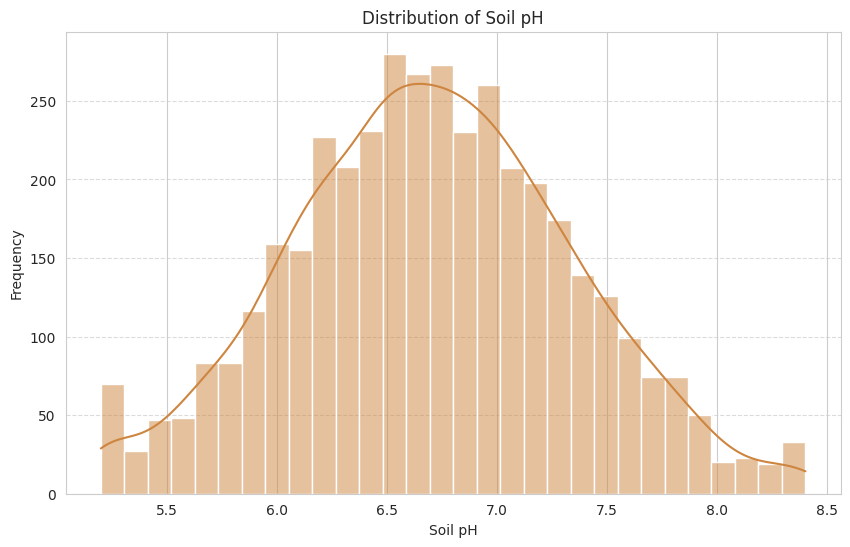

In [ ]:
# Visualize the distribution of 'Soil_pH'
plt.figure(figsize=(10, 6))
sns.histplot(df['Soil_pH'], kde=True, bins=30, color='peru')
plt.title('Distribution of Soil pH')
plt.xlabel('Soil pH')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Observation on Soil pH Distribution**

From the histogram and KDE plot of `Soil_pH`, we can observe the following:

*   The distribution of soil pH is approximately **bell-shaped and fairly symmetrical**, centered around **6.5 to 7.0**, which is generally considered neutral to slightly acidic, and ideal for the growth of many crops.
*   The majority of soil samples fall within a pH range conducive to agriculture, from approximately 5.5 to 7.5.
*   There are fewer instances of very acidic (below 5.5) or very alkaline (above 7.5) soils, but these variations could significantly impact crop choice and nutrient availability.

Soil pH is a critical factor influencing nutrient availability and microbial activity, directly affecting crop health and yield. This distribution provides insight into the general soil conditions across the dataset, highlighting areas of optimal conditions and potential challenges.

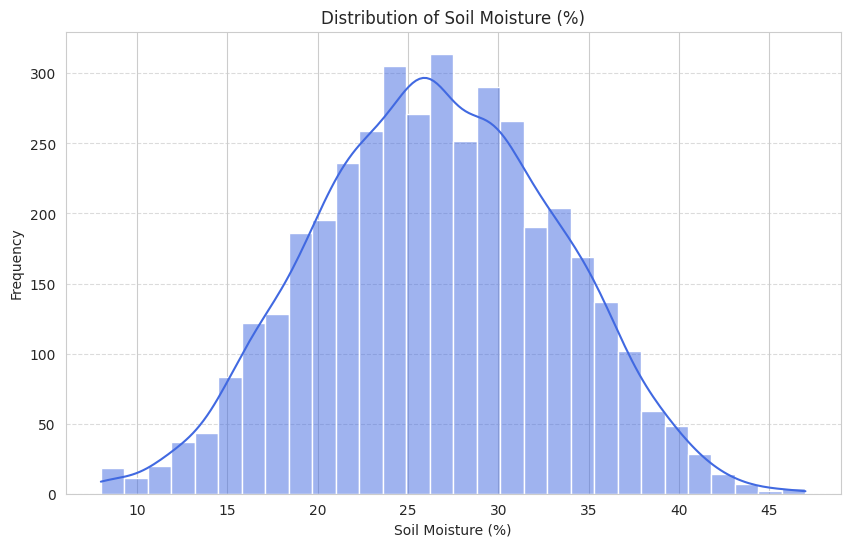

In [ ]:
# Visualize the distribution of 'Soil_Moisture_pct'
plt.figure(figsize=(10, 6))
sns.histplot(df['Soil_Moisture_pct'], kde=True, bins=30, color='royalblue')
plt.title('Distribution of Soil Moisture (%)')
plt.xlabel('Soil Moisture (%)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Observation on Soil Moisture Distribution**

From the histogram and KDE plot of `Soil_Moisture_pct`, we can observe the following:

*   The distribution of soil moisture is approximately **bell-shaped and fairly symmetrical**, centered around **25-30%**, indicating a common range for soil moisture levels across the farms.
*   The majority of data points are concentrated within the 20-35% range, suggesting these are typical soil moisture conditions.
*   The spread of the distribution indicates that while most farms have moderate soil moisture, there are instances of both drier (down to ~10%) and wetter (up to ~45%) conditions.

Soil moisture is a critical factor for crop growth, directly influencing water availability to plants. Understanding its distribution helps in assessing irrigation needs, drought risks, and overall water management strategies.

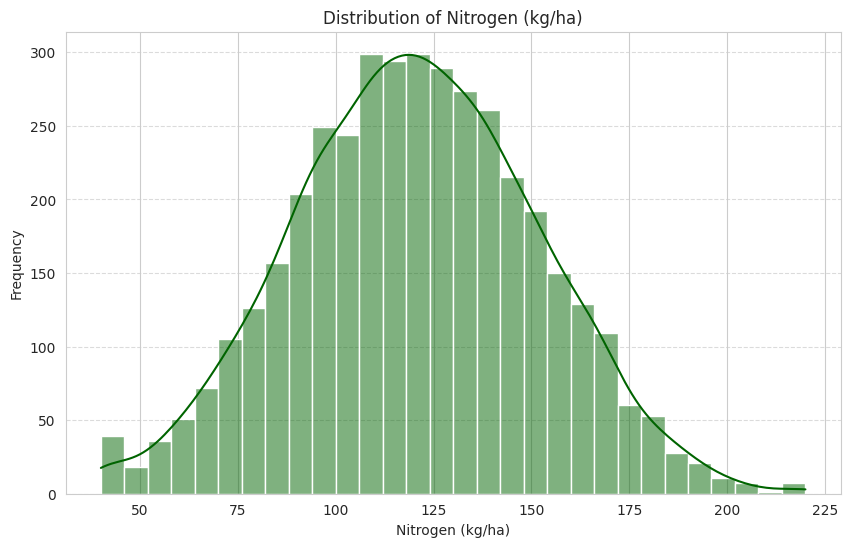

In [ ]:
# Visualize the distribution of 'Nitrogen_kg_ha'
plt.figure(figsize=(10, 6))
sns.histplot(df['Nitrogen_kg_ha'], kde=True, bins=30, color='darkgreen')
plt.title('Distribution of Nitrogen (kg/ha)')
plt.xlabel('Nitrogen (kg/ha)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

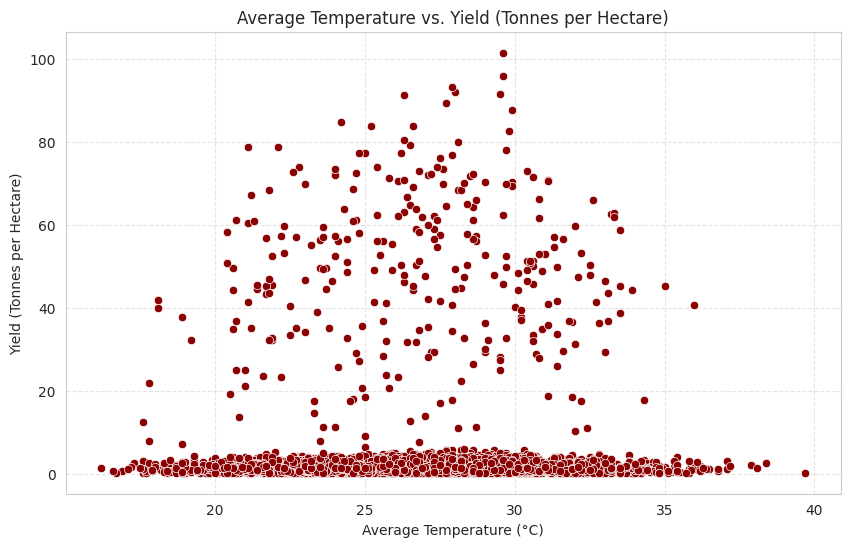

In [ ]:
# Visualize the relationship between 'Avg_Temperature_C' and 'Yield_Tonnes_Ha'
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Avg_Temperature_C', y='Yield_Tonnes_Ha', color='darkred')
plt.title('Average Temperature vs. Yield (Tonnes per Hectare)')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Yield (Tonnes per Hectare)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### **Observation on Average Temperature vs. Yield Relationship**

From the scatter plot of `Avg_Temperature_C` against `Yield_Tonnes_Ha`, we can observe the following:

*   Similar to rainfall, there isn't a strong, clear linear relationship between average temperature and yield across the entire dataset. The points are quite spread out.
*   However, higher yields (above 10-20 tonnes/hectare) seem to be concentrated within a specific temperature range, approximately **20°C to 30°C**. This suggests an optimal temperature window for maximizing yield.
*   At very low temperatures (below ~20°C) and higher temperatures (above ~30°C), yields tend to be lower, with a few exceptions.
*   Many low yield observations (below 5 tonnes/hectare) are present across the entire temperature spectrum, indicating that temperature, while important, is not the sole determinant of yield, and other factors are at play.

This visual analysis indicates that while moderate temperatures are generally associated with better yields, extreme temperatures may hinder crop productivity. Further statistical analysis and consideration of other interacting factors would provide a more nuanced understanding of this relationship.

#### **Observation on Nitrogen Distribution**

From the histogram and KDE plot of `Nitrogen_kg_ha`, we can observe the following:

*   The distribution of nitrogen levels is approximately **bell-shaped and fairly symmetrical**, centered around **110-130 kg/ha**.
*   This indicates that a significant portion of farms apply or have nitrogen levels within this moderate range, which is often optimal for many crops.
*   The spread shows that while most nitrogen levels are concentrated around the mean, there are also farms with lower (down to ~40 kg/ha) and higher (up to ~200 kg/ha) nitrogen content, reflecting diverse soil management practices or natural soil compositions.

Nitrogen is a primary macronutrient essential for plant growth and yield. Understanding its distribution is vital for assessing soil fertility, fertilizer application strategies, and their potential impact on agricultural performance.

#### **Observation on Phosphorus Levels vs. Profit Relationship**

No strong linear correlation is observed. However, higher profits cluster within a phosphorus range of 50 to 70 kg/ha, indicating a potential optimal range. Profits generally decrease with phosphorus levels outside this range.

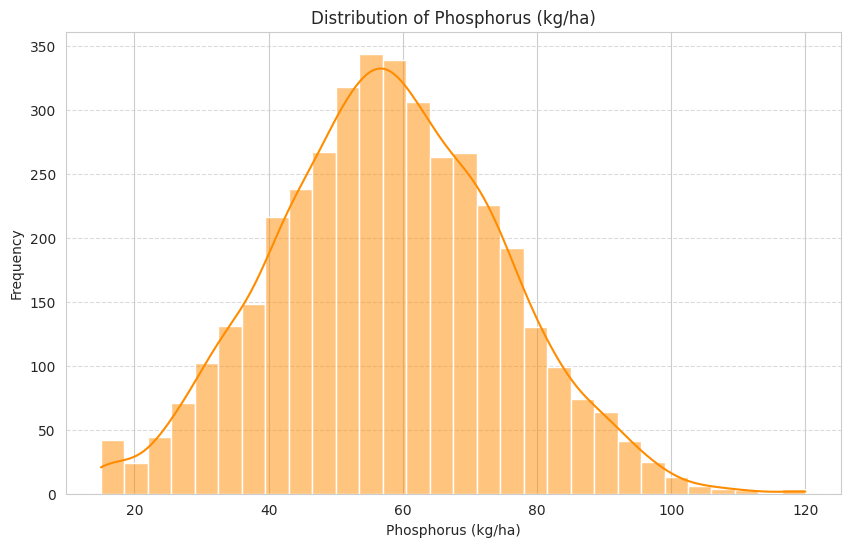

In [ ]:
# Visualize the distribution of 'Phosphorus_kg_ha'
plt.figure(figsize=(10, 6))
sns.histplot(df['Phosphorus_kg_ha'], kde=True, bins=30, color='darkorange')
plt.title('Distribution of Phosphorus (kg/ha)')
plt.xlabel('Phosphorus (kg/ha)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Observation on Phosphorus Distribution**

From the histogram and KDE plot of `Phosphorus_kg_ha`, we can observe the following:

*   The distribution of phosphorus levels is approximately **bell-shaped and fairly symmetrical**, centered around **55-60 kg/ha**.
*   This indicates that a significant portion of farms have phosphorus levels within this moderate range, which is typically considered healthy for many crops.
*   The spread shows that while most phosphorus levels are concentrated around the mean, there are also farms with lower (down to ~15 kg/ha) and higher (up to ~100 kg/ha) phosphorus content. This diversity could be due to variations in soil type, past fertilization, or crop specific needs.

Phosphorus is another vital macronutrient for plant growth, particularly for root development and flowering. Understanding its distribution is crucial for assessing soil fertility and optimizing fertilizer management practices.

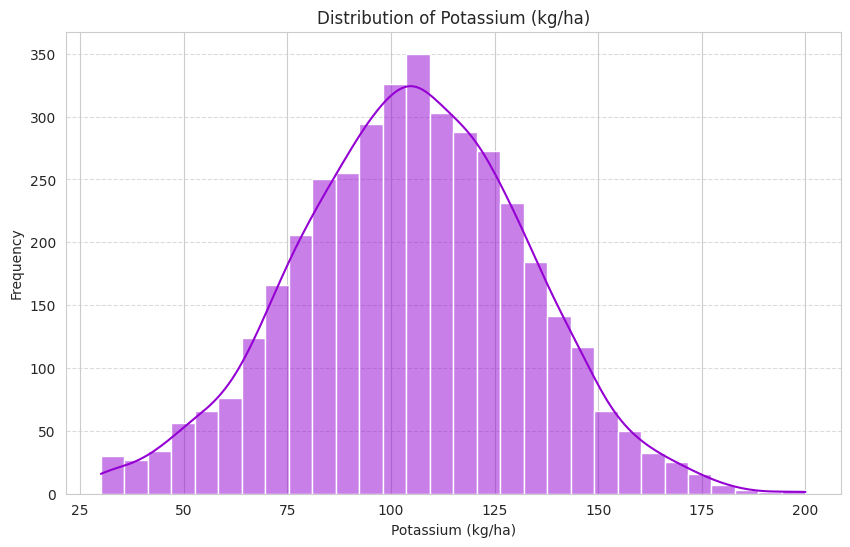

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Potassium_kg_ha'], kde=True, bins=30, color='darkviolet')
plt.title('Distribution of Potassium (kg/ha)')
plt.xlabel('Potassium (kg/ha)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Observation on Potassium Distribution**

From the histogram and KDE plot of `Potassium_kg_ha`, we can observe the following:

*   The distribution of potassium levels is approximately **bell-shaped and fairly symmetrical**, centered around **100-110 kg/ha**.
*   This suggests that a significant portion of farms have potassium levels within this range, which is generally considered adequate for many crops.
*   The spread indicates that while most potassium levels are concentrated around the mean, there are also farms with lower (down to ~30 kg/ha) and higher (up to ~200 kg/ha) potassium content. This variability could be due to differences in soil types, crop demands, or fertilization practices.

Potassium is a crucial macronutrient involved in water regulation, nutrient transport, and overall plant vigor. Understanding its distribution is essential for assessing soil fertility and developing effective nutrient management strategies.

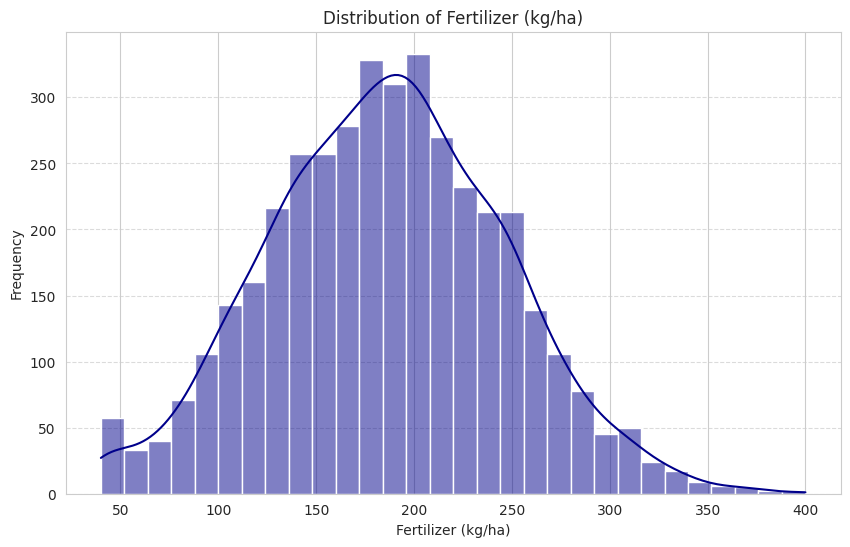

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Fertilizer_kg_ha'], kde=True, bins=30, color='darkblue')
plt.title('Distribution of Fertilizer (kg/ha)')
plt.xlabel('Fertilizer (kg/ha)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Observation on Fertilizer Distribution**

From the histogram and KDE plot of `Fertilizer_kg_ha`, we can observe the following:

*   The distribution of fertilizer levels is approximately **bell-shaped and fairly symmetrical**, centered around **150-170 kg/ha**.
*   This indicates that a significant portion of farms apply fertilizer within this moderate range, which is often considered optimal for many crops.
*   The spread shows that while most fertilizer levels are concentrated around the mean, there are also farms with lower (down to ~50 kg/ha) and higher (up to ~300 kg/ha) fertilizer content. This variability could be due to differences in crop types, soil nutrient deficiencies, or specific farming practices.

Fertilizer application is a key agricultural practice influencing soil fertility and crop productivity. Understanding its distribution helps in assessing common application rates and identifying potential areas for optimizing nutrient management strategies.

#### **Potassium Levels vs. Profit**

**Overview**
This analysis explores the relationship between soil potassium levels and farm profitability, aiming to identify optimal potassium conditions for maximizing earnings.

#### **Observation on Potassium Levels vs. Profit Relationship**

No strong linear correlation is observed. However, higher profits cluster within a potassium range of 80 to 130 kg/ha, indicating a potential optimal range. Profits generally decrease with potassium levels outside this range.

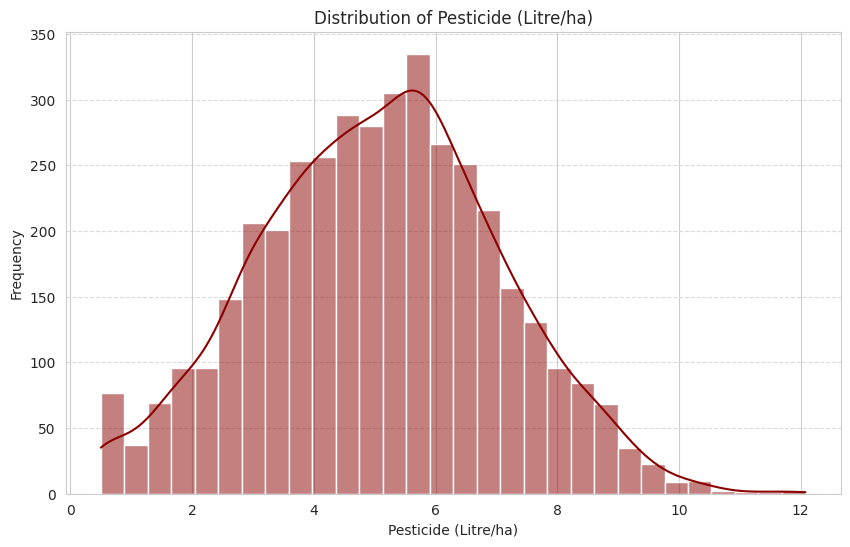

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Pesticide_Litre_ha'], kde=True, bins=30, color='darkred')
plt.title('Distribution of Pesticide (Litre/ha)')
plt.xlabel('Pesticide (Litre/ha)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Observation on Pesticide Distribution**

From the histogram and KDE plot of `Pesticide_Litre_ha`, we can observe the following:

*   The distribution of pesticide application rates is approximately **bell-shaped and fairly symmetrical**, centered around **1.5 - 2.0 Litres/ha**.
*   This indicates that a significant portion of farms apply pesticides within this moderate range, which is likely a common practice for pest management.
*   The spread shows that while most application rates are concentrated around the mean, there are also farms with lower (down to ~0.5 Litre/ha) and higher (up to ~3.5 Litre/ha) pesticide use. This variability could be due to differences in crop types, pest pressure, or pest management strategies.

Pesticide application is a critical practice for protecting crops from pests and diseases. Understanding its distribution helps in assessing common pest control practices and identifying potential areas for optimizing integrated pest management strategies.

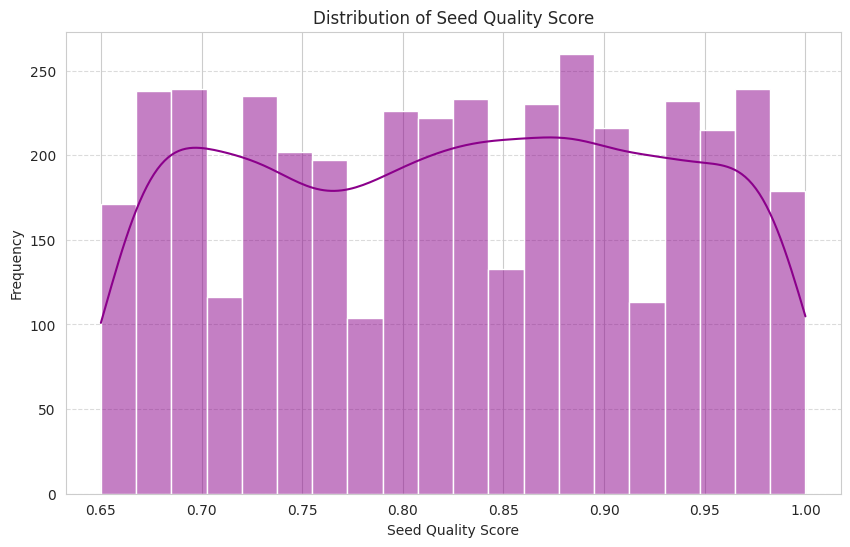

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Seed_Quality_Score'], kde=True, bins=20, color='darkmagenta')
plt.title('Distribution of Seed Quality Score')
plt.xlabel('Seed Quality Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Observation on Seed Quality Score Distribution**

From the histogram and KDE plot of `Seed_Quality_Score`, we can observe the following:

*   The distribution of seed quality scores is generally **bell-shaped but slightly skewed to the left (negatively skewed)**, indicating that higher seed quality scores are more common.
*   There's a clear concentration of scores between **0.75 and 0.95**, suggesting that most farms in the dataset use seeds of good to very good quality.
*   The range of scores extends from 0.65 to 1.0, with fewer instances of lower quality seeds.

Seed quality is a crucial factor influencing germination, plant vigor, and ultimately yield. This distribution highlights a generally high standard of seed quality within the dataset, which is a positive indicator for agricultural productivity.

### **Summary of Univariate Analysis**

**Categorical Variables:**

*   **Crop:** Rice and Wheat are the most prevalent crops, followed by Maize, Cotton, and Pulses. Sugarcane, Chilli, and Groundnut are less common.
*   **Season:** Kharif and Rabi seasons dominate the agricultural activities in the dataset, with Zaid season being less represented.
*   **Irrigation Method:** Flood irrigation and Rainfed methods are the most common, while Drip and Sprinkler irrigation are less frequently used.

**Numerical Variables:**

*   **Yield_Tonnes_Ha:** Highly right-skewed, indicating most farms have low to moderate yields, but a few achieve very high yields.
*   **Profit_INR:** Approximately symmetrical around zero, with many farms experiencing losses or near break-even, and a few generating very high profits.
*   **Rainfall_mm:** Generally bell-shaped with a slight positive skew, and potential bimodal tendencies, suggesting diverse climatic patterns.
*   **Avg_Temperature_C:** Approximately bell-shaped and symmetrical, centered around 27-29°C, indicating optimal temperature conditions for many crops.
*   **Humidity_pct:** Bell-shaped and symmetrical, peaking around 60-70%, representing moderate humidity levels.
*   **Sunlight_Hours_Day:** Bell-shaped and symmetrical, centered around 7-7.5 hours per day, showing typical daylight durations.
*   **Soil_pH:** Bell-shaped and symmetrical, centered around 6.5-7.0, which is ideal for most crops.
*   **Soil_Moisture_pct:** Bell-shaped and symmetrical, centered around 25-30%, indicating common soil moisture levels.
*   **Nitrogen_kg_ha:** Bell-shaped and symmetrical, centered around 110-130 kg/ha, suggesting moderate nitrogen levels.
*   **Phosphorus_kg_ha:** Bell-shaped and symmetrical, centered around 55-60 kg/ha, indicating moderate phosphorus levels.
*   **Potassium_kg_ha:** Bell-shaped and symmetrical, centered around 100-110 kg/ha, suggesting adequate potassium levels.
*   **Fertilizer_kg_ha:** Bell-shaped and symmetrical, centered around 150-170 kg/ha, representing common fertilizer application rates.
*   **Pesticide_Litre_ha:** Bell-shaped and symmetrical, centered around 1.5-2.0 Litres/ha, indicating common pesticide usage.
*   **Seed_Quality_Score:** Slightly negatively skewed (left-skewed), with a concentration between 0.75 and 0.95, indicating generally high seed quality.

This univariate analysis provides a foundational understanding of each variable's characteristics, highlighting key trends and distributions that will be crucial for subsequent bivariate and multivariate analyses to uncover relationships and insights.

### **Bivariate Analysis**

📌 **Overview**

Bivariate analysis involves examining the relationship between two variables simultaneously. This helps us understand how variables interact and influence each other, which is crucial for identifying key drivers of agricultural performance.

Why are we doing this?
Understanding the relationships between variables, such as how rainfall affects yield, or how different irrigation methods impact profit, can provide actionable insights. This analysis will guide us in formulating hypotheses for predictive modeling and developing targeted recommendations for improving agricultural practices.

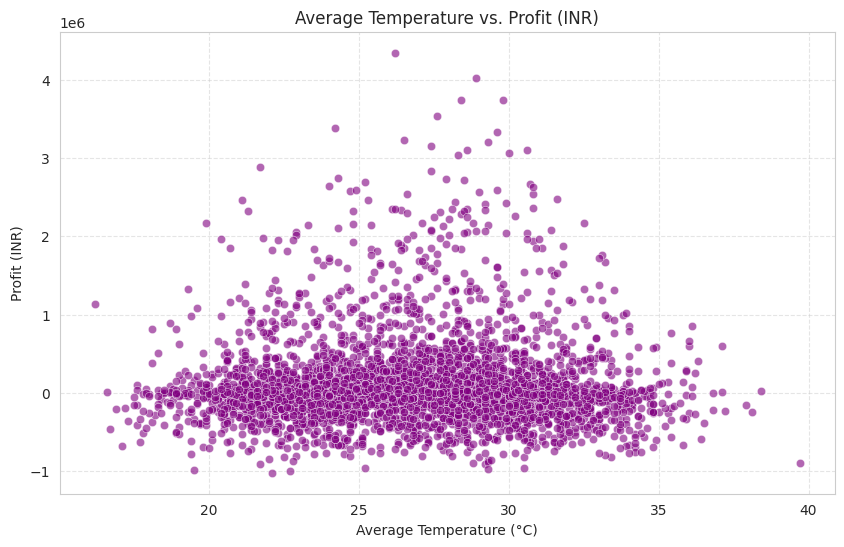

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Avg_Temperature_C', y='Profit_INR', color='purple', alpha=0.6)
plt.title('Average Temperature vs. Profit (INR)')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Profit (INR)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### **Observation on Average Temperature vs. Profit Relationship**

From the scatter plot of `Avg_Temperature_C` against `Profit_INR`, we can observe the following:

*   There doesn't appear to be a strong, clear linear relationship between average temperature and profit. The points are widely scattered across the plot.
*   However, most of the farms that achieve higher profits (positive values) seem to fall within an average temperature range of approximately **20°C to 30°C**. This suggests that while not a direct linear correlation, there might be an optimal temperature window conducive to profitability.
*   Farms experiencing significant losses (negative profit values) are distributed across a broad range of temperatures, indicating that temperature alone isn't the primary driver of losses, and other factors are likely at play.
*   Very few high profits are observed at temperatures below 20°C or above 30°C, which aligns with the observation that extreme temperatures can hinder crop yield and, consequently, profitability.

This analysis suggests that maintaining temperatures within a moderate range is generally favorable for agricultural profitability, though other variables likely interact with temperature to determine the overall financial outcome for a farm.

#### **Rainfall vs. Profit**

**Overview**
This analysis explores the impact of rainfall on farm profitability. Understanding this relationship helps identify optimal rainfall conditions for maximizing profits.


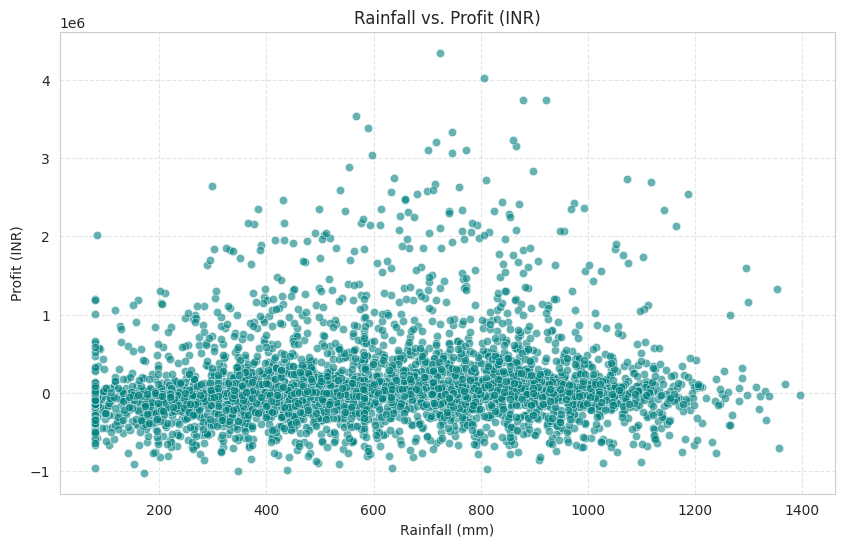

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Rainfall_mm', y='Profit_INR', color='teal', alpha=0.6)
plt.title('Rainfall vs. Profit (INR)')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Profit (INR)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### **Observation on Rainfall vs. Profit Relationship**

From the scatter plot of `Rainfall_mm` against `Profit_INR`, we can observe the following:

*   There is no strong linear relationship between rainfall and profit. The data points are widely dispersed, indicating a complex interaction.
*   However, a notable cluster of **higher profits (positive values)** appears to be concentrated within a rainfall range of approximately **400 mm to 1000 mm**. This suggests that moderate rainfall is generally more conducive to profitability.
*   Both very low rainfall (below ~300 mm) and very high rainfall (above ~1100 mm) tend to be associated with lower profits or even losses, as evidenced by more negative or near-zero profit values in these ranges.
*   Farms experiencing significant losses (large negative profit values) are present across various rainfall levels, implying that other factors, in addition to rainfall, heavily influence financial outcomes.

This analysis indicates that an optimal range of rainfall is crucial for maximizing profits, and deviations from this range, either too little or too much, can negatively impact agricultural earnings. Further investigation into specific crop requirements and irrigation methods in conjunction with rainfall could provide deeper insights.

#### **Soil Moisture vs. Profit**

**Overview**
This section investigates the relationship between soil moisture percentage and farm profitability, aiming to identify ideal moisture conditions for maximizing earnings.

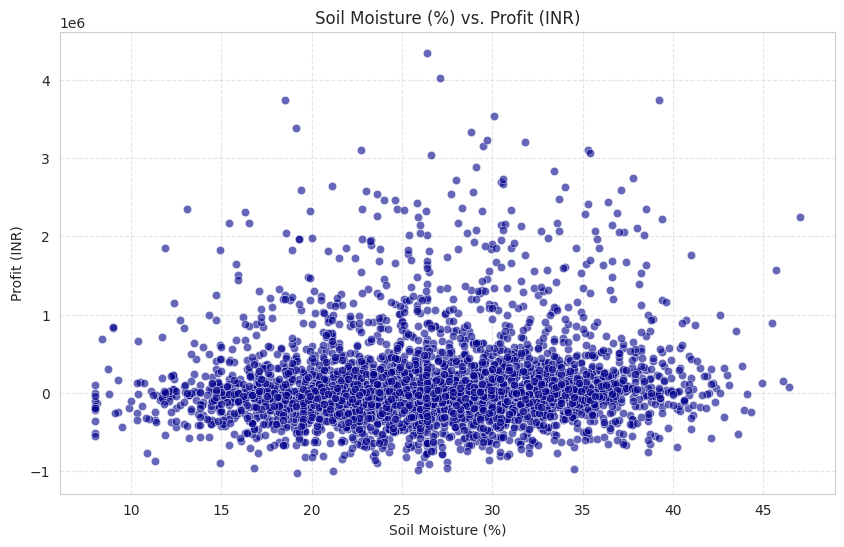

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Soil_Moisture_pct', y='Profit_INR', color='darkblue', alpha=0.6)
plt.title('Soil Moisture (%) vs. Profit (INR)')
plt.xlabel('Soil Moisture (%)')
plt.ylabel('Profit (INR)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### **Observation on Soil Moisture vs. Profit Relationship**

No strong linear correlation is evident. However, higher profits tend to cluster within a soil moisture range of 20% to 35%, suggesting an optimal range. Extremely low or high moisture levels generally correlate with lower profits or losses, indicating detrimental effects outside the optimal range.

#### **Fertilizer Application vs. Profit**

**Overview**
This analysis explores the relationship between fertilizer application rates and farm profitability to identify optimal conditions for maximizing earnings.

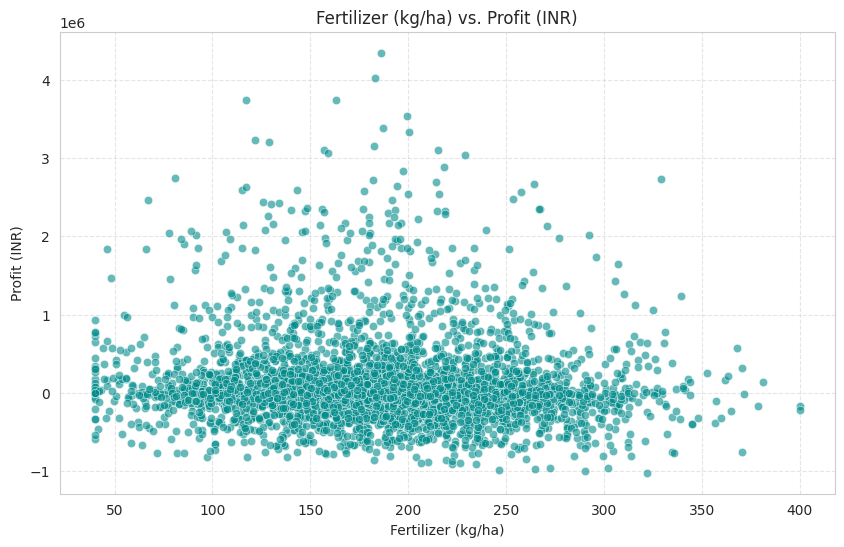

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Fertilizer_kg_ha', y='Profit_INR', color='darkcyan', alpha=0.6)
plt.title('Fertilizer (kg/ha) vs. Profit (INR)')
plt.xlabel('Fertilizer (kg/ha)')
plt.ylabel('Profit (INR)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### **Observation on Fertilizer Application vs. Profit Relationship**

The scatter plot shows no strong linear correlation. However, higher profits tend to cluster within a fertilizer application range of 120 to 200 kg/ha, suggesting an optimal range. Profits generally decrease with very low or very high fertilizer application rates.

#### **Seed Quality vs. Profit**

**Overview**
This analysis explores the relationship between seed quality scores and farm profitability to understand the impact of seed quality on earnings.

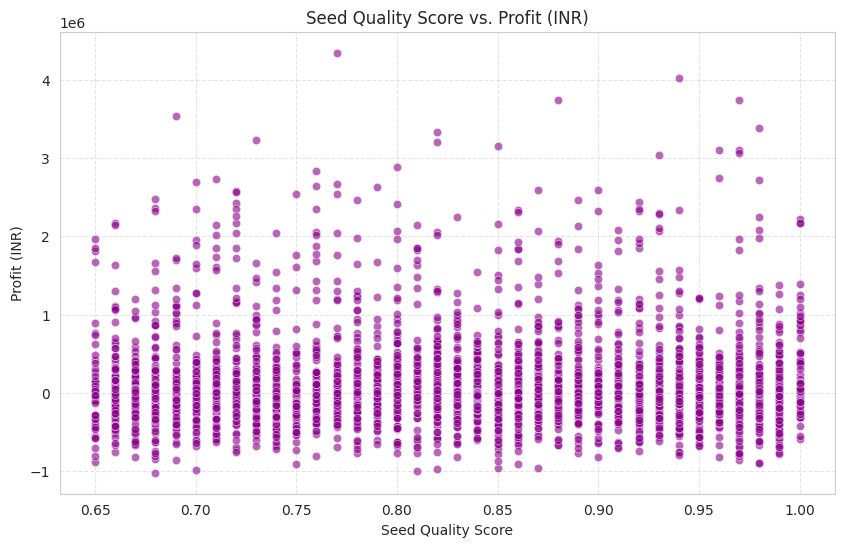

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Seed_Quality_Score', y='Profit_INR', color='darkmagenta', alpha=0.6)
plt.title('Seed Quality Score vs. Profit (INR)')
plt.xlabel('Seed Quality Score')
plt.ylabel('Profit (INR)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### **Observation on Seed Quality Score vs. Profit Relationship**

No strong linear correlation is observed. However, higher profits tend to cluster at higher seed quality scores (above 0.80), suggesting a positive influence. Farms with lower seed quality scores are more likely to experience lower profits or losses, reinforcing the importance of quality seeds.

#### **Yield vs. Profit**

**Overview**
This analysis investigates the direct relationship between agricultural yield (tonnes per hectare) and farm profitability to understand how production efficiency translates into financial gains.

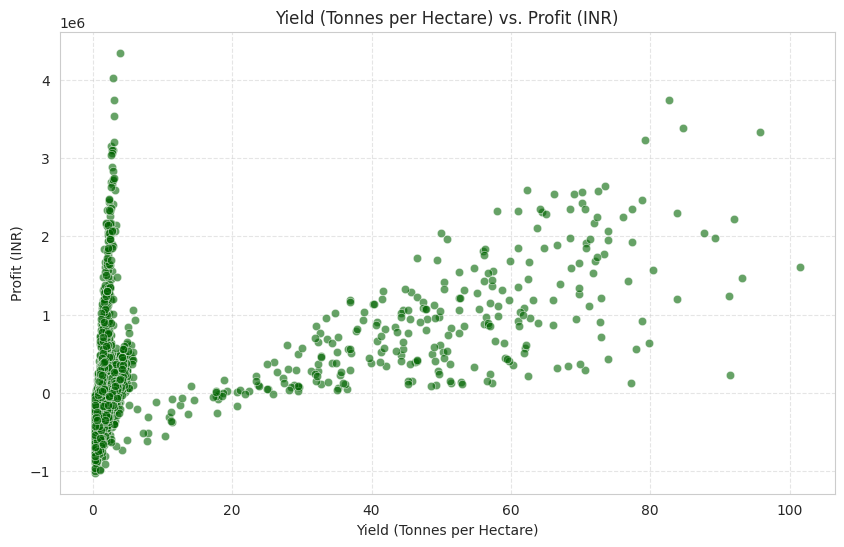

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Yield_Tonnes_Ha', y='Profit_INR', color='darkgreen', alpha=0.6)
plt.title('Yield (Tonnes per Hectare) vs. Profit (INR)')
plt.xlabel('Yield (Tonnes per Hectare)')
plt.ylabel('Profit (INR)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### **Observation on Yield vs. Profit Relationship**

The scatter plot shows a **clear positive correlation** between `Yield_Tonnes_Ha` and `Profit_INR`. As yield increases, profit generally increases, indicating that higher production directly translates to better financial returns. Farms with very low yields frequently experience losses or minimal profits, while farms achieving higher yields are consistently among the most profitable. This highlights yield as a critical driver of profitability in agriculture.

#### **Rainfall vs. Yield**

**Overview**
This analysis explores the relationship between rainfall levels and crop yield (tonnes per hectare) to understand how water availability, whether from natural precipitation or irrigation, influences agricultural productivity.

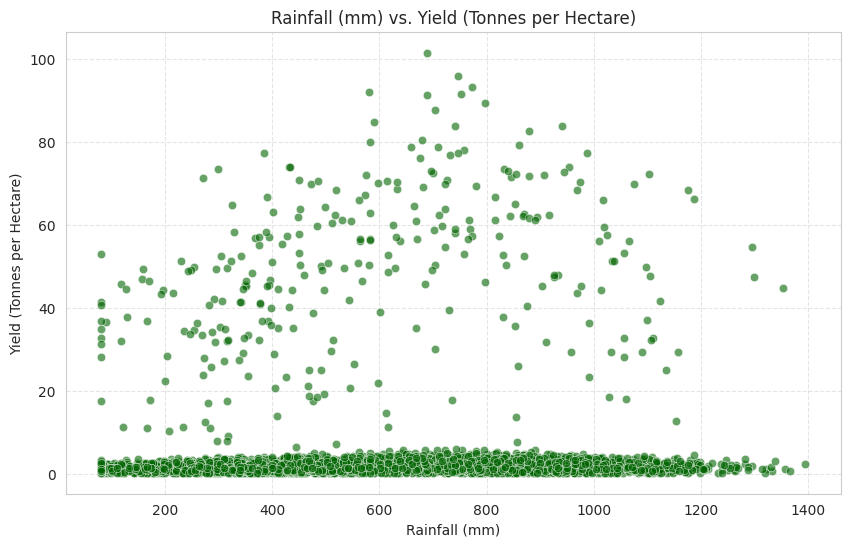

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', color='darkgreen', alpha=0.6)
plt.title('Rainfall (mm) vs. Yield (Tonnes per Hectare)')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes per Hectare)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### **Observation on Rainfall vs. Yield Relationship**

From the scatter plot of `Rainfall_mm` against `Yield_Tonnes_Ha`, we can observe the following:

*   There doesn't appear to be a strong linear correlation between rainfall and yield across the entire range of data. The points are quite scattered.
*   However, there seems to be a **concentration of higher yields (above 10-20 tonnes/hectare) within a certain range of rainfall**, roughly between 400 mm and 1000 mm. This suggests that while extremely low or high rainfall might be detrimental, an optimal range exists where higher yields are more probable.
*   At very low rainfall levels (below ~200-300 mm) and very high rainfall levels (above ~1200 mm), yields tend to be lower or clustered around the lower end.
*   The majority of farms with low yields (below 5 tonnes/hectare) are observed across almost the entire spectrum of rainfall, indicating that while rainfall is a factor, other variables likely play a significant role in determining very low yields.

This preliminary visual analysis suggests a non-linear or complex relationship, where moderate rainfall might be beneficial, but excessive or insufficient rainfall could negatively impact crop yield. Further statistical analysis (e.g., correlation coefficients for specific ranges, or multivariate analysis) would be needed to quantify this relationship more precisely.

#### **Temperature vs. Yield**

**Overview**
This analysis explores the relationship between average temperature and crop yield (tonnes per hectare) to understand how temperature influences agricultural productivity.

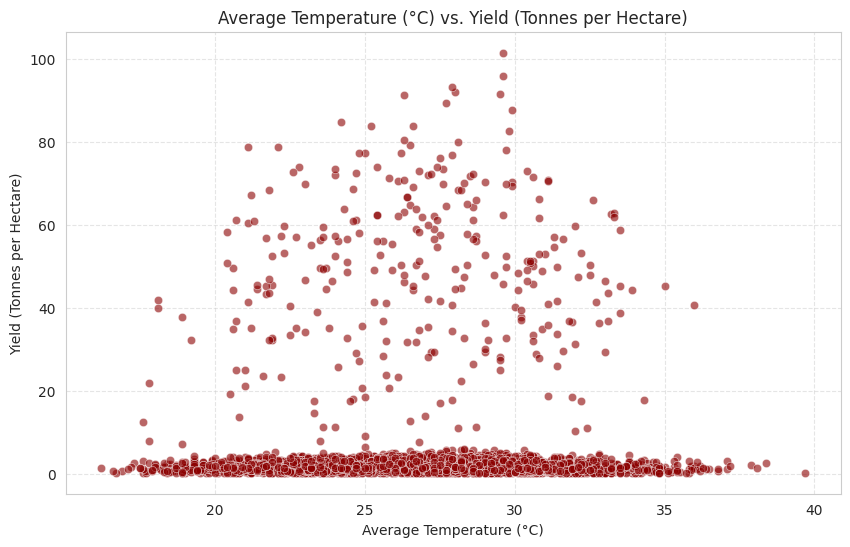

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Avg_Temperature_C', y='Yield_Tonnes_Ha', color='darkred', alpha=0.6)
plt.title('Average Temperature (°C) vs. Yield (Tonnes per Hectare)')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Yield (Tonnes per Hectare)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### **Observation on Average Temperature vs. Yield Relationship**

From the scatter plot of `Avg_Temperature_C` against `Yield_Tonnes_Ha`, we can observe the following:

*   Similar to rainfall, there isn't a strong, clear linear relationship between average temperature and yield across the entire dataset. The points are quite spread out.
*   However, higher yields (above 10-20 tonnes/hectare) seem to be concentrated within a specific temperature range, approximately **20°C to 30°C**. This suggests an optimal temperature window for maximizing yield.
*   At very low temperatures (below ~20°C) and higher temperatures (above ~30°C), yields tend to be lower, with a few exceptions.
*   Many low yield observations (below 5 tonnes/hectare) are present across the entire temperature spectrum, indicating that temperature, while important, is not the sole determinant of yield, and other factors are at play.

This visual analysis indicates that while moderate temperatures are generally associated with better yields, extreme temperatures may hinder crop productivity. Further statistical analysis and consideration of other interacting factors would provide a more nuanced understanding of this relationship.

#### **Humidity vs. Yield**

**Overview**
This analysis explores the relationship between humidity percentage and crop yield (tonnes per hectare) to understand how atmospheric moisture influences agricultural productivity.

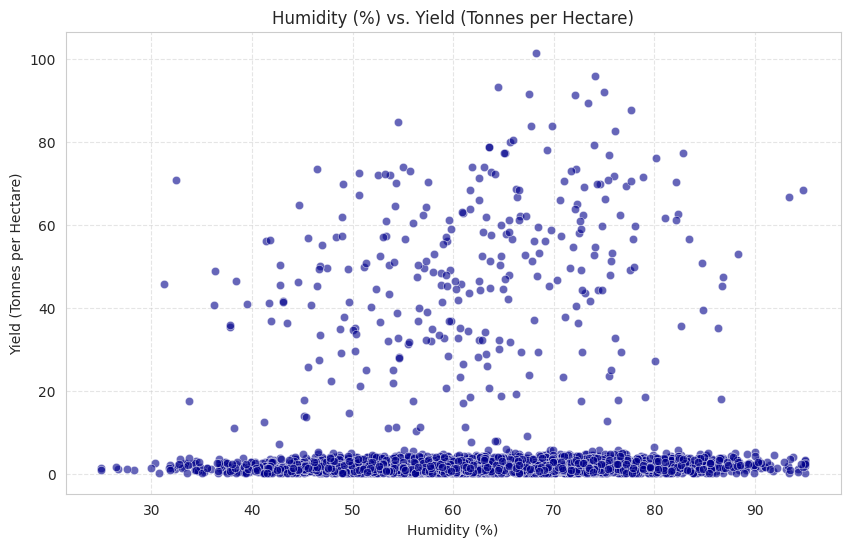

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Humidity_pct', y='Yield_Tonnes_Ha', color='darkblue', alpha=0.6)
plt.title('Humidity (%) vs. Yield (Tonnes per Hectare)')
plt.xlabel('Humidity (%)')
plt.ylabel('Yield (Tonnes per Hectare)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### **Observation on Humidity vs. Yield Relationship**

From the scatter plot of `Humidity_pct` against `Yield_Tonnes_Ha`, we can observe the following:

*   There is no strong linear correlation between humidity and yield across the entire range of data. The points are quite scattered.
*   However, higher yields (above 10-20 tonnes/hectare) tend to be concentrated within a humidity range of approximately **55% to 75%**. This suggests an optimal humidity window for maximizing yield.
*   At very low humidity levels (below ~40%) and very high humidity levels (above ~85%), yields tend to be lower or clustered around the lower end.
*   The majority of farms with low yields (below 5 tonnes/hectare) are present across almost the entire spectrum of humidity, indicating that while humidity is a factor, other variables also play a significant role in determining very low yields.

This visual analysis suggests a non-linear or complex relationship, where moderate humidity might be beneficial, but extreme humidity levels (either too low or too high) could negatively impact crop yield. Further statistical analysis and consideration of other interacting factors would provide a more nuanced understanding of this relationship.

#### **Soil Moisture vs. Yield**

**Overview**
This analysis explores the relationship between soil moisture percentage and crop yield (tonnes per hectare) to understand how water availability in the soil influences agricultural productivity.

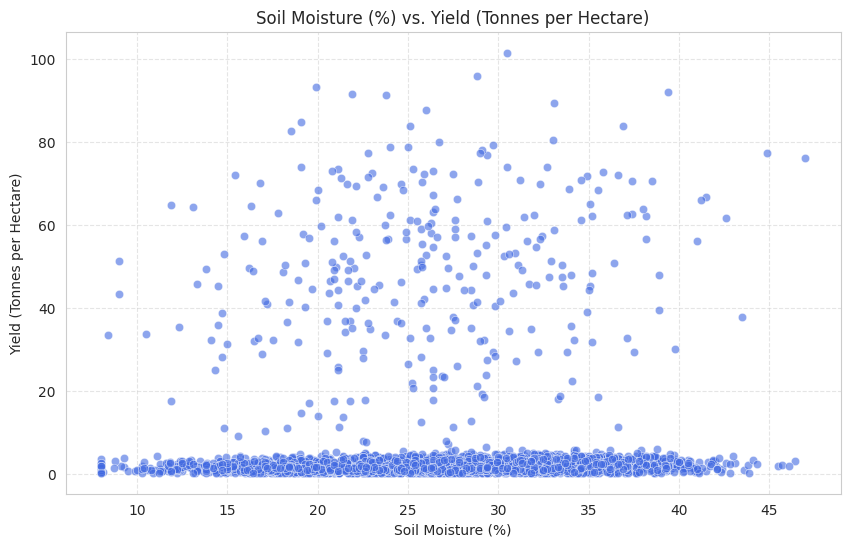

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Soil_Moisture_pct', y='Yield_Tonnes_Ha', color='royalblue', alpha=0.6)
plt.title('Soil Moisture (%) vs. Yield (Tonnes per Hectare)')
plt.xlabel('Soil Moisture (%)')
plt.ylabel('Yield (Tonnes per Hectare)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### **Observation on Soil Moisture vs. Yield Relationship**

From the scatter plot of `Soil_Moisture_pct` against `Yield_Tonnes_Ha`, we can observe the following:

*   There is no strong linear correlation between soil moisture and yield across the entire range of data. The points are quite scattered.
*   However, higher yields (above 10-20 tonnes/hectare) tend to be concentrated within a soil moisture range of approximately **20% to 35%**. This suggests an optimal soil moisture window for maximizing yield.
*   At very low soil moisture levels (below ~15%) and very high soil moisture levels (above ~40%), yields tend to be lower or clustered around the lower end.
*   The majority of farms with low yields (below 5 tonnes/hectare) are present across almost the entire spectrum of soil moisture, indicating that while soil moisture is a factor, other variables also play a significant role in determining very low yields.

This visual analysis suggests a non-linear or complex relationship, where moderate soil moisture might be beneficial, but extreme soil moisture levels (either too low or too high) could negatively impact crop yield. Further statistical analysis and consideration of other interacting factors would provide a more nuanced understanding of this relationship.

#### **Sunlight vs. Yield**

**Overview**
This analysis explores the relationship between daily sunlight hours and crop yield (tonnes per hectare) to understand how light availability influences agricultural productivity.

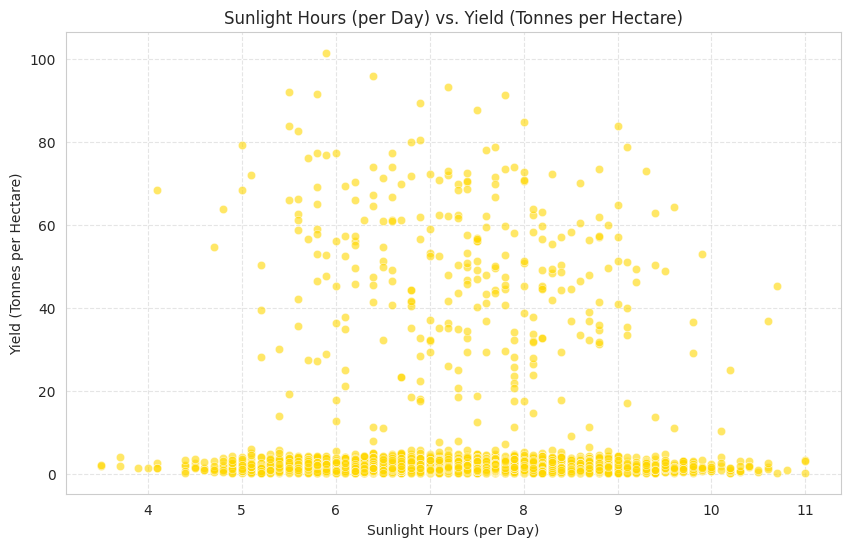

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Sunlight_Hours_Day', y='Yield_Tonnes_Ha', color='gold', alpha=0.6)
plt.title('Sunlight Hours (per Day) vs. Yield (Tonnes per Hectare)')
plt.xlabel('Sunlight Hours (per Day)')
plt.ylabel('Yield (Tonnes per Hectare)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### **Observation on Sunlight Hours vs. Yield Relationship**

From the scatter plot of `Sunlight_Hours_Day` against `Yield_Tonnes_Ha`, we can observe the following:

*   There is no strong linear correlation between sunlight hours and yield across the entire range of data. The points are quite scattered.
*   However, higher yields (above 10-20 tonnes/hectare) tend to be concentrated within a sunlight hours range of approximately **6.5 to 8.5 hours per day**. This suggests an optimal sunlight window for maximizing yield.
*   At very low sunlight levels (below ~5 hours) and very high sunlight levels (above ~9.5 hours), yields tend to be lower or clustered around the lower end.
*   The majority of farms with low yields (below 5 tonnes/hectare) are present across almost the entire spectrum of sunlight hours, indicating that while sunlight is a factor, other variables also play a significant role in determining very low yields.

This visual analysis suggests a non-linear or complex relationship, where moderate sunlight might be beneficial, but extreme sunlight levels (either too low or too high) could negatively impact crop yield. Further statistical analysis and consideration of other interacting factors would provide a more nuanced understanding of this relationship.

#### **Fertilizer vs. Yield**

**Overview**
This analysis explores the relationship between fertilizer application rates and crop yield (tonnes per hectare) to understand how nutrient management influences agricultural productivity.

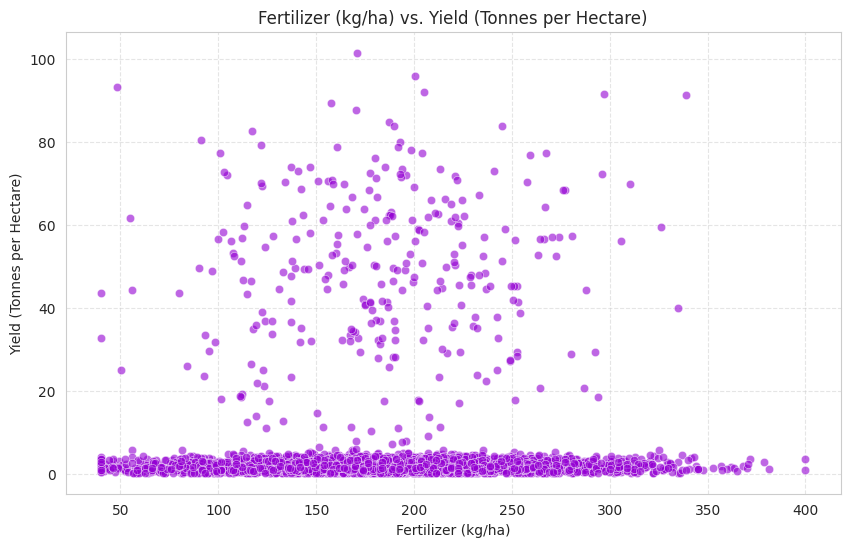

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Fertilizer_kg_ha', y='Yield_Tonnes_Ha', color='darkviolet', alpha=0.6)
plt.title('Fertilizer (kg/ha) vs. Yield (Tonnes per Hectare)')
plt.xlabel('Fertilizer (kg/ha)')
plt.ylabel('Yield (Tonnes per Hectare)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### **Observation on Fertilizer vs. Yield Relationship**

From the scatter plot of `Fertilizer_kg_ha` against `Yield_Tonnes_Ha`, we can observe the following:

*   There doesn't appear to be a strong linear correlation between fertilizer application and yield across the entire dataset. The points are quite scattered.
*   However, higher yields (above 10-20 tonnes/hectare) seem to be concentrated within a fertilizer range of approximately **120 kg/ha to 200 kg/ha**. This suggests an optimal fertilizer application window for maximizing yield.
*   At very low fertilizer levels (below ~100 kg/ha) and very high fertilizer levels (above ~250 kg/ha), yields tend to be lower or clustered around the lower end.
*   The majority of farms with low yields (below 5 tonnes/hectare) are observed across almost the entire spectrum of fertilizer application rates, indicating that while fertilizer is a factor, other variables also play a significant role in determining very low yields.

This visual analysis suggests a non-linear or complex relationship, where moderate fertilizer application might be beneficial, but excessive or insufficient application could negatively impact crop yield. Further statistical analysis and consideration of other interacting factors would provide a more nuanced understanding of this relationship.

#### **Seed Quality vs. Yield**

**Overview**
This analysis explores the relationship between seed quality scores and crop yield (tonnes per hectare) to understand how the genetic potential and health of seeds influence agricultural productivity.

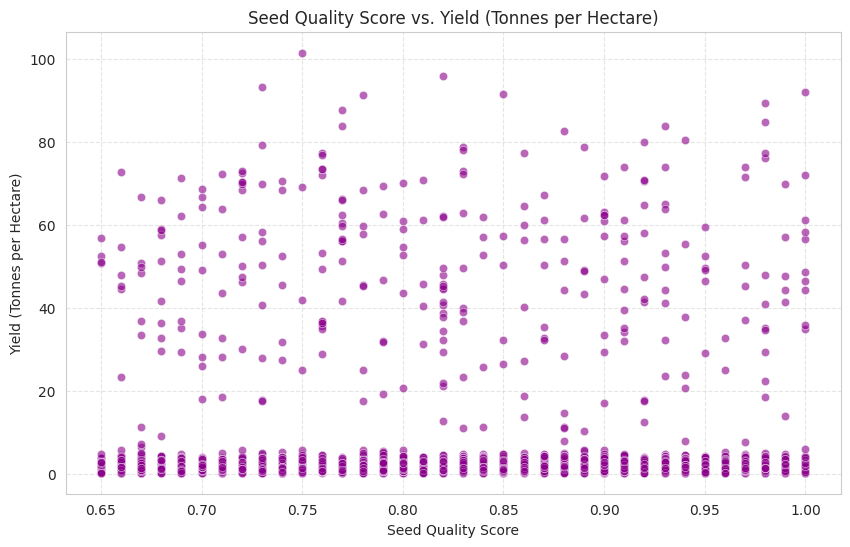

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Seed_Quality_Score', y='Yield_Tonnes_Ha', color='darkmagenta', alpha=0.6)
plt.title('Seed Quality Score vs. Yield (Tonnes per Hectare)')
plt.xlabel('Seed Quality Score')
plt.ylabel('Yield (Tonnes per Hectare)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### **Observation on Seed Quality Score vs. Yield Relationship**

From the scatter plot of `Seed_Quality_Score` against `Yield_Tonnes_Ha`, we can observe the following:

*   There is no strong linear correlation between seed quality score and yield across the entire dataset. The points are quite scattered.
*   However, higher yields (above 10-20 tonnes/hectare) tend to be concentrated at higher seed quality scores, generally **above 0.80**. This suggests that good seed quality is a contributing factor to higher yields.
*   Lower seed quality scores (below ~0.70) are predominantly associated with lower yields.
*   The majority of farms with low yields (below 5 tonnes/hectare) are present across almost the entire spectrum of seed quality scores, indicating that while seed quality is important, other variables also play a significant role in determining very low yields.

This visual analysis suggests that while high seed quality is beneficial for achieving better yields, it is not the sole determinant, and a combination of factors contributes to overall agricultural productivity.

#### **Water Used vs. Yield**

**Overview**
This analysis explores the relationship between the volume of water used (in cubic meters) and crop yield (tonnes per hectare) to understand the impact of water resource management on agricultural productivity.

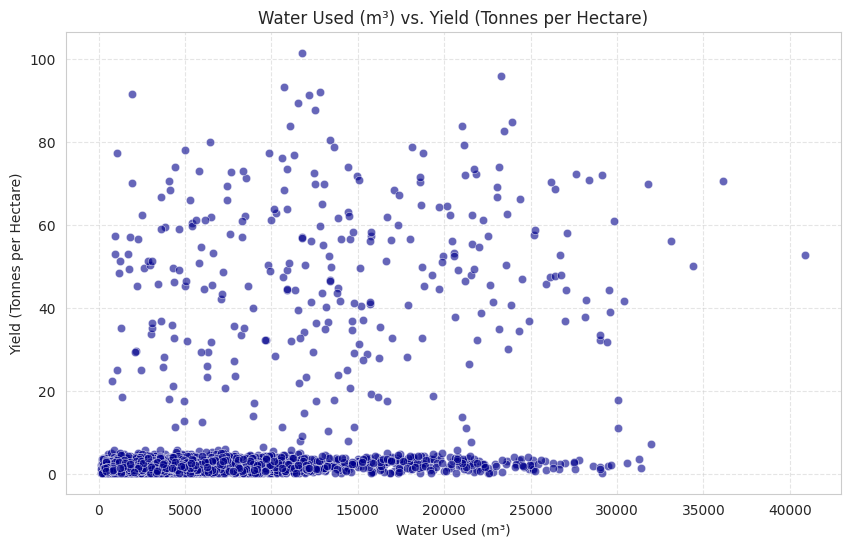

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Water_Used_m3', y='Yield_Tonnes_Ha', color='darkblue', alpha=0.6)
plt.title('Water Used (m³) vs. Yield (Tonnes per Hectare)')
plt.xlabel('Water Used (m³)')
plt.ylabel('Yield (Tonnes per Hectare)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### **Observation on Water Used vs. Yield Relationship**

From the scatter plot of `Water_Used_m3` against `Yield_Tonnes_Ha`, we can observe the following:

*   There is a general **positive correlation** between water used and yield; as the volume of water used increases, there is a tendency for yield to increase, especially up to a certain point.
*   However, the relationship is not strictly linear and shows considerable scatter. Higher yields (above 10-20 tonnes/hectare) are predominantly found in farms that use moderate to high amounts of water, generally between **5,000 m³ and 25,000 m³**.
*   Very low water usage (below ~2,000 m³) is almost exclusively associated with low yields.
*   Conversely, extremely high water usage (above ~30,000 m³) does not necessarily translate to proportionally higher yields and may even see a plateau or slight decrease, indicating potential inefficiencies or diminishing returns at very high irrigation levels.

This visual analysis suggests that adequate water availability is critical for achieving higher yields, and there might be an optimal range for water usage beyond which additional water provides limited or no further benefit to yield. Efficient water management is crucial to maximize yields without incurring unnecessary costs or resource waste.

#### **Total Cost vs. Revenue**

**Overview**
This analysis explores the relationship between the total operational costs incurred by farms and the revenue generated, aiming to understand the financial efficiency and profitability patterns.

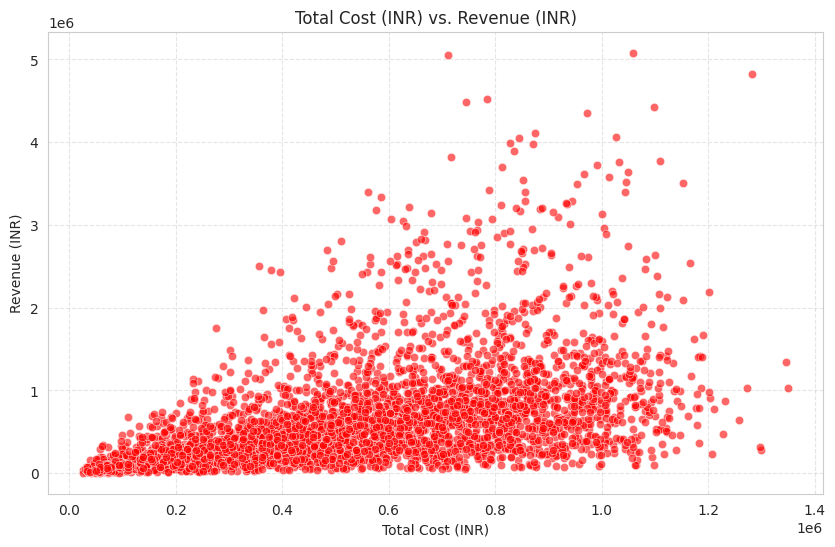

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Total_Cost_INR', y='Revenue_INR', color='red', alpha=0.6)
plt.title('Total Cost (INR) vs. Revenue (INR)')
plt.xlabel('Total Cost (INR)')
plt.ylabel('Revenue (INR)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### **Observation on Total Cost vs. Revenue Relationship**

From the scatter plot of `Total_Cost_INR` against `Revenue_INR`, we can observe the following:

*   There is a **strong positive linear correlation** between Total Cost and Revenue. As total costs increase, revenue generally increases, which is expected as higher investment often leads to higher production and sales.
*   The points largely follow a trend line, suggesting a direct relationship. However, there's a significant spread, particularly at higher cost levels, indicating varying degrees of efficiency or market conditions affecting profitability.
*   Many points fall below the implied 'break-even' line (where Cost = Revenue), indicating farms operating at a loss. Conversely, many points are above this line, representing profitable operations.
*   Farms with higher costs tend to achieve higher revenues, but also show a wider range of outcomes, from significant losses to very high profits.

This analysis confirms that managing costs effectively while optimizing for revenue generation is key. The scatter suggests that while higher spending can lead to higher returns, careful planning and efficient operations are crucial to ensure profitability and avoid losses.

## **Multivariate Analysis**

📌 **Overview**

Multivariate analysis involves examining the relationships among three or more variables simultaneously. This advanced form of analysis helps to uncover complex patterns, interactions, and dependencies that might not be apparent when looking at variables in isolation or in pairs. It allows for a more holistic understanding of how various factors collectively influence agricultural outcomes.

Why are we doing this?
In agriculture, many factors interact to affect yield and profitability. For example, temperature, rainfall, and soil moisture don't act independently; their combined effect determines crop health and productivity. Multivariate analysis enables us to explore these intricate relationships, identify synergistic or antagonistic effects, and gain deeper insights into the underlying mechanisms driving farm performance. This understanding is crucial for developing sophisticated models and targeted recommendations that account for the multifaceted nature of agricultural systems.

### **Pair Plot – Environmental Factors + Yield**

**Overview**
This pair plot visualizes the relationships between several key environmental factors (`Rainfall_mm`, `Avg_Temperature_C`, `Humidity_pct`, `Soil_Moisture_pct`, `Sunlight_Hours_Day`) and `Yield_Tonnes_Ha`. By coloring points based on `Season`, we can observe how these relationships vary across different cultivation periods.

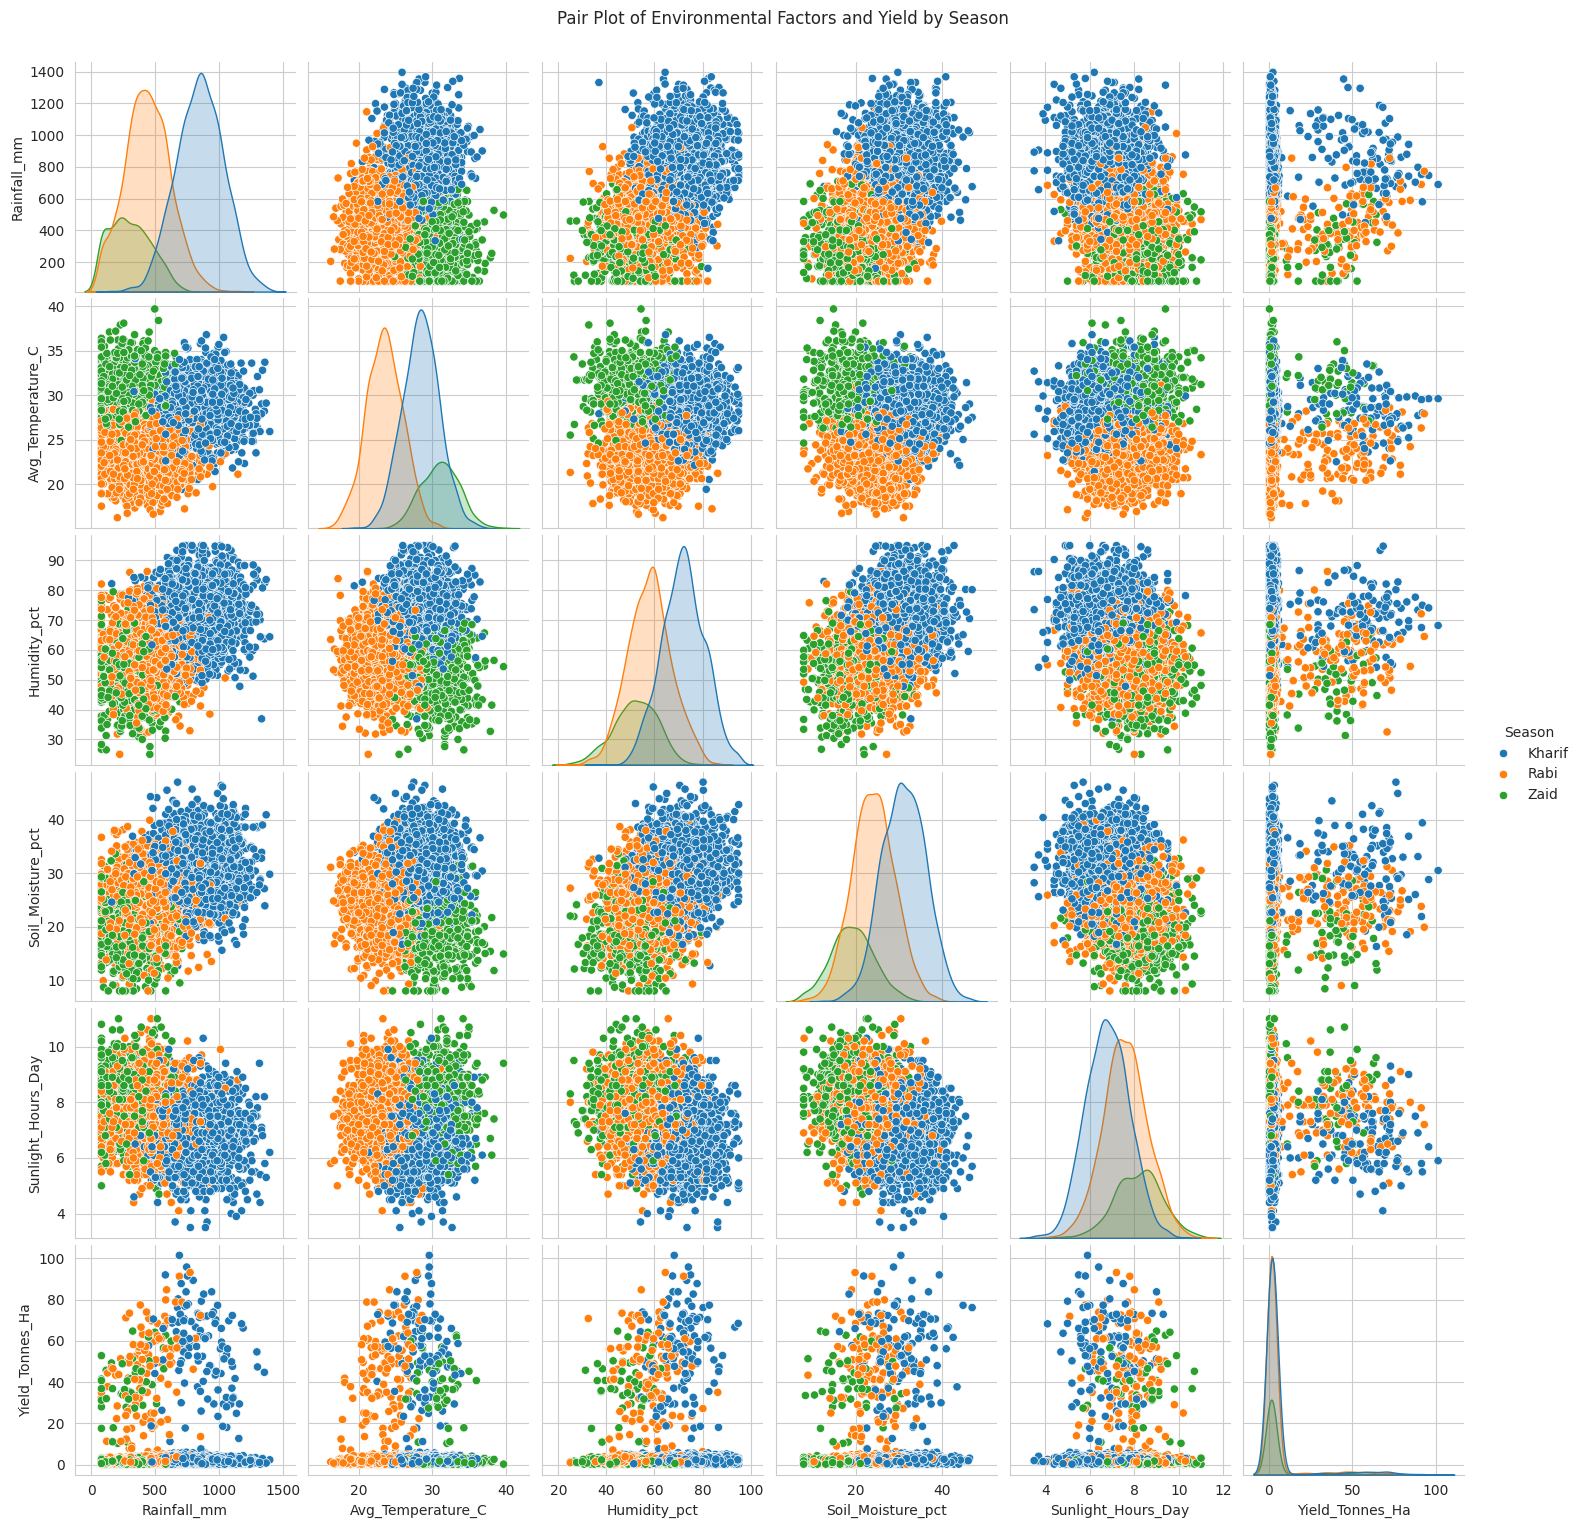

In [ ]:
# Select environmental factors and yield, and include 'Season' for hue
environmental_cols = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Soil_Moisture_pct',
    'Sunlight_Hours_Day',
    'Yield_Tonnes_Ha',
    'Season'
]

# Create the pair plot
# The 'diag_kind' is set to 'kde' for density plots on the diagonals for numerical columns
# The 'hue' is set to 'Season' to differentiate observations by season
g = sns.pairplot(df[environmental_cols], hue='Season', diag_kind='kde')

# Adjust title and layout
g.fig.suptitle('Pair Plot of Environmental Factors and Yield by Season', y=1.02) # Add a title above the plots
plt.show()

#### **Observation on Pair Plot of Environmental Factors and Yield by Season**

From the pair plot, we can observe the following:

*   **General Trends with Yield:** The plots in the `Yield_Tonnes_Ha` row and column confirm earlier bivariate findings, showing a general concentration of higher yields within optimal ranges for each environmental factor, rather than strong linear correlations across the entire spectrum. For instance, higher yields are often seen at moderate levels of `Rainfall_mm`, `Avg_Temperature_C`, `Humidity_pct`, `Soil_Moisture_pct`, and `Sunlight_Hours_Day`.

*   **Seasonal Differentiation:** The `Season` hue reveals distinct patterns. For example, 'Kharif' and 'Rabi' seasons appear to have a wider spread of environmental conditions and yield outcomes compared to 'Zaid', which often clusters in specific ranges, especially for temperature and sunlight. This suggests that the impact and typical ranges of environmental factors vary significantly by season.

*   **Inter-Environmental Factor Relationships:** Relationships between environmental factors themselves (e.g., `Rainfall_mm` vs. `Humidity_pct`) are also visible. For instance, `Rainfall_mm` and `Humidity_pct` often show a positive correlation, which is intuitive. The distribution of these relationships might also be differentiated by season, indicating distinct climatic profiles for each season.

*   **Complexity:** The plots underscore the complex, often non-linear, and multi-faceted nature of how environmental conditions influence agricultural yield, with seasonal variations adding another layer of complexity. No single environmental factor appears to be a sole predictor of high yield across all seasons.

### **Crop × Season Yield Heatmap**

**Overview**
This heatmap visualizes the average `Yield_Tonnes_Ha` for each `Crop` type across different `Season`s. It helps in quickly identifying which crops perform best in which seasons, highlighting optimal crop-season combinations.

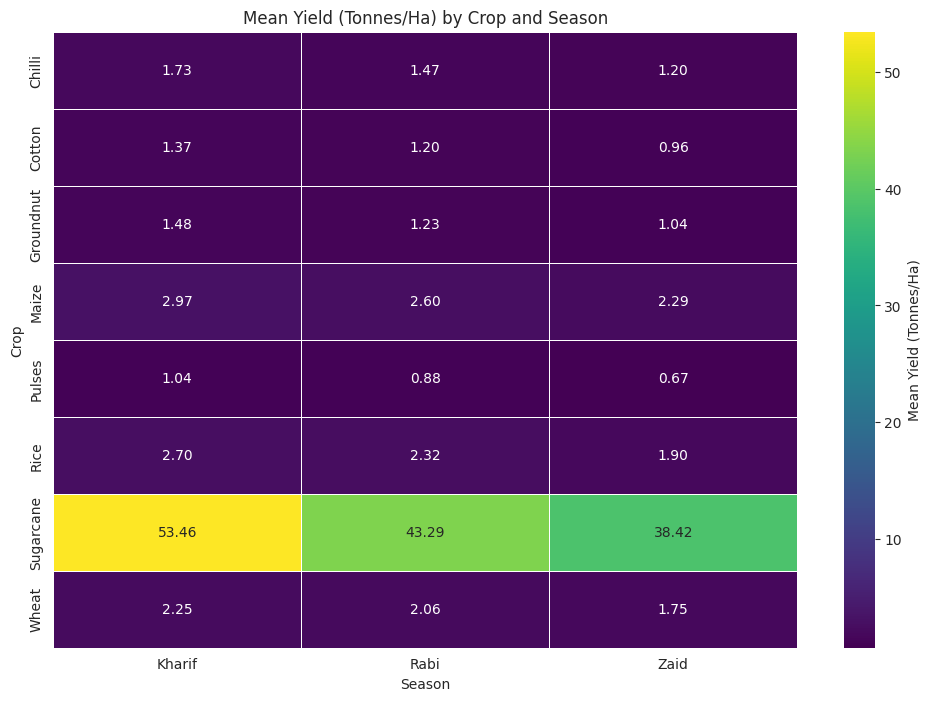

In [ ]:
# Create a pivot table for mean Yield_Tonnes_Ha by Crop and Season
yield_pivot = df.pivot_table(values='Yield_Tonnes_Ha', index='Crop', columns='Season', aggfunc='mean')

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(yield_pivot, annot=True, fmt=".2f", cmap='viridis', linewidths=.5, cbar_kws={'label': 'Mean Yield (Tonnes/Ha)'})
plt.title('Mean Yield (Tonnes/Ha) by Crop and Season')
plt.xlabel('Season')
plt.ylabel('Crop')
plt.show()

#### **Observation on Crop × Season Yield Heatmap**

From the heatmap visualizing mean yield by crop and season, we can observe the following:

*   **Season-Specific High Yields:** Certain crops demonstrate significantly higher average yields in particular seasons. For example, 'Rice' and 'Wheat' show high yields primarily in the 'Kharif' and 'Rabi' seasons, respectively, which aligns with typical agricultural cycles for these crops.

*   **Overall High Performers:** 'Sugarcane' consistently shows very high mean yields across all seasons it is cultivated, indicating its high productivity potential under various seasonal conditions in the dataset.

*   **Lower Yields in Zaid:** The 'Zaid' season generally exhibits lower average yields across most crops compared to 'Kharif' and 'Rabi'. This is expected as 'Zaid' is typically a shorter, hotter season, which may not be optimal for many main crops.

*   **Crop-Season Suitability:** The heatmap clearly highlights crop-season combinations that are more productive (darker shades) versus those that are less productive (lighter shades). For example, 'Maize' performs relatively well in 'Kharif' and 'Rabi' but less so in 'Zaid'.

This analysis is crucial for understanding crop adaptability and optimizing planting schedules, suggesting that aligning crops with suitable seasons can significantly enhance overall agricultural productivity.

## **Correlation Analysis**

📌 **Overview**

Correlation analysis quantifies the strength and direction of a linear relationship between two numerical variables. A positive correlation indicates that as one variable increases, the other tends to increase, while a negative correlation suggests that as one increases, the other tends to decrease. The Pearson correlation coefficient, ranging from -1 to 1, is commonly used for this purpose.

Why are we doing this?
Understanding the correlation between variables helps us identify which factors are most strongly associated with key agricultural outcomes like yield and profit. This can inform decision-making, such as prioritizing certain environmental factors or resource management strategies. High correlations might suggest direct dependencies, while low correlations could indicate that variables act independently or have non-linear relationships. This step provides a statistical foundation to support the visual observations made during bivariate and multivariate analyses.

### **Correlation Heatmap**

**Overview**
This heatmap visualizes the Pearson correlation coefficients between all numerical variables in the dataset. It provides a comprehensive view of the strength and direction of linear relationships between pairs of variables. Higher absolute values indicate stronger correlations, with positive values showing a direct relationship and negative values an inverse relationship.



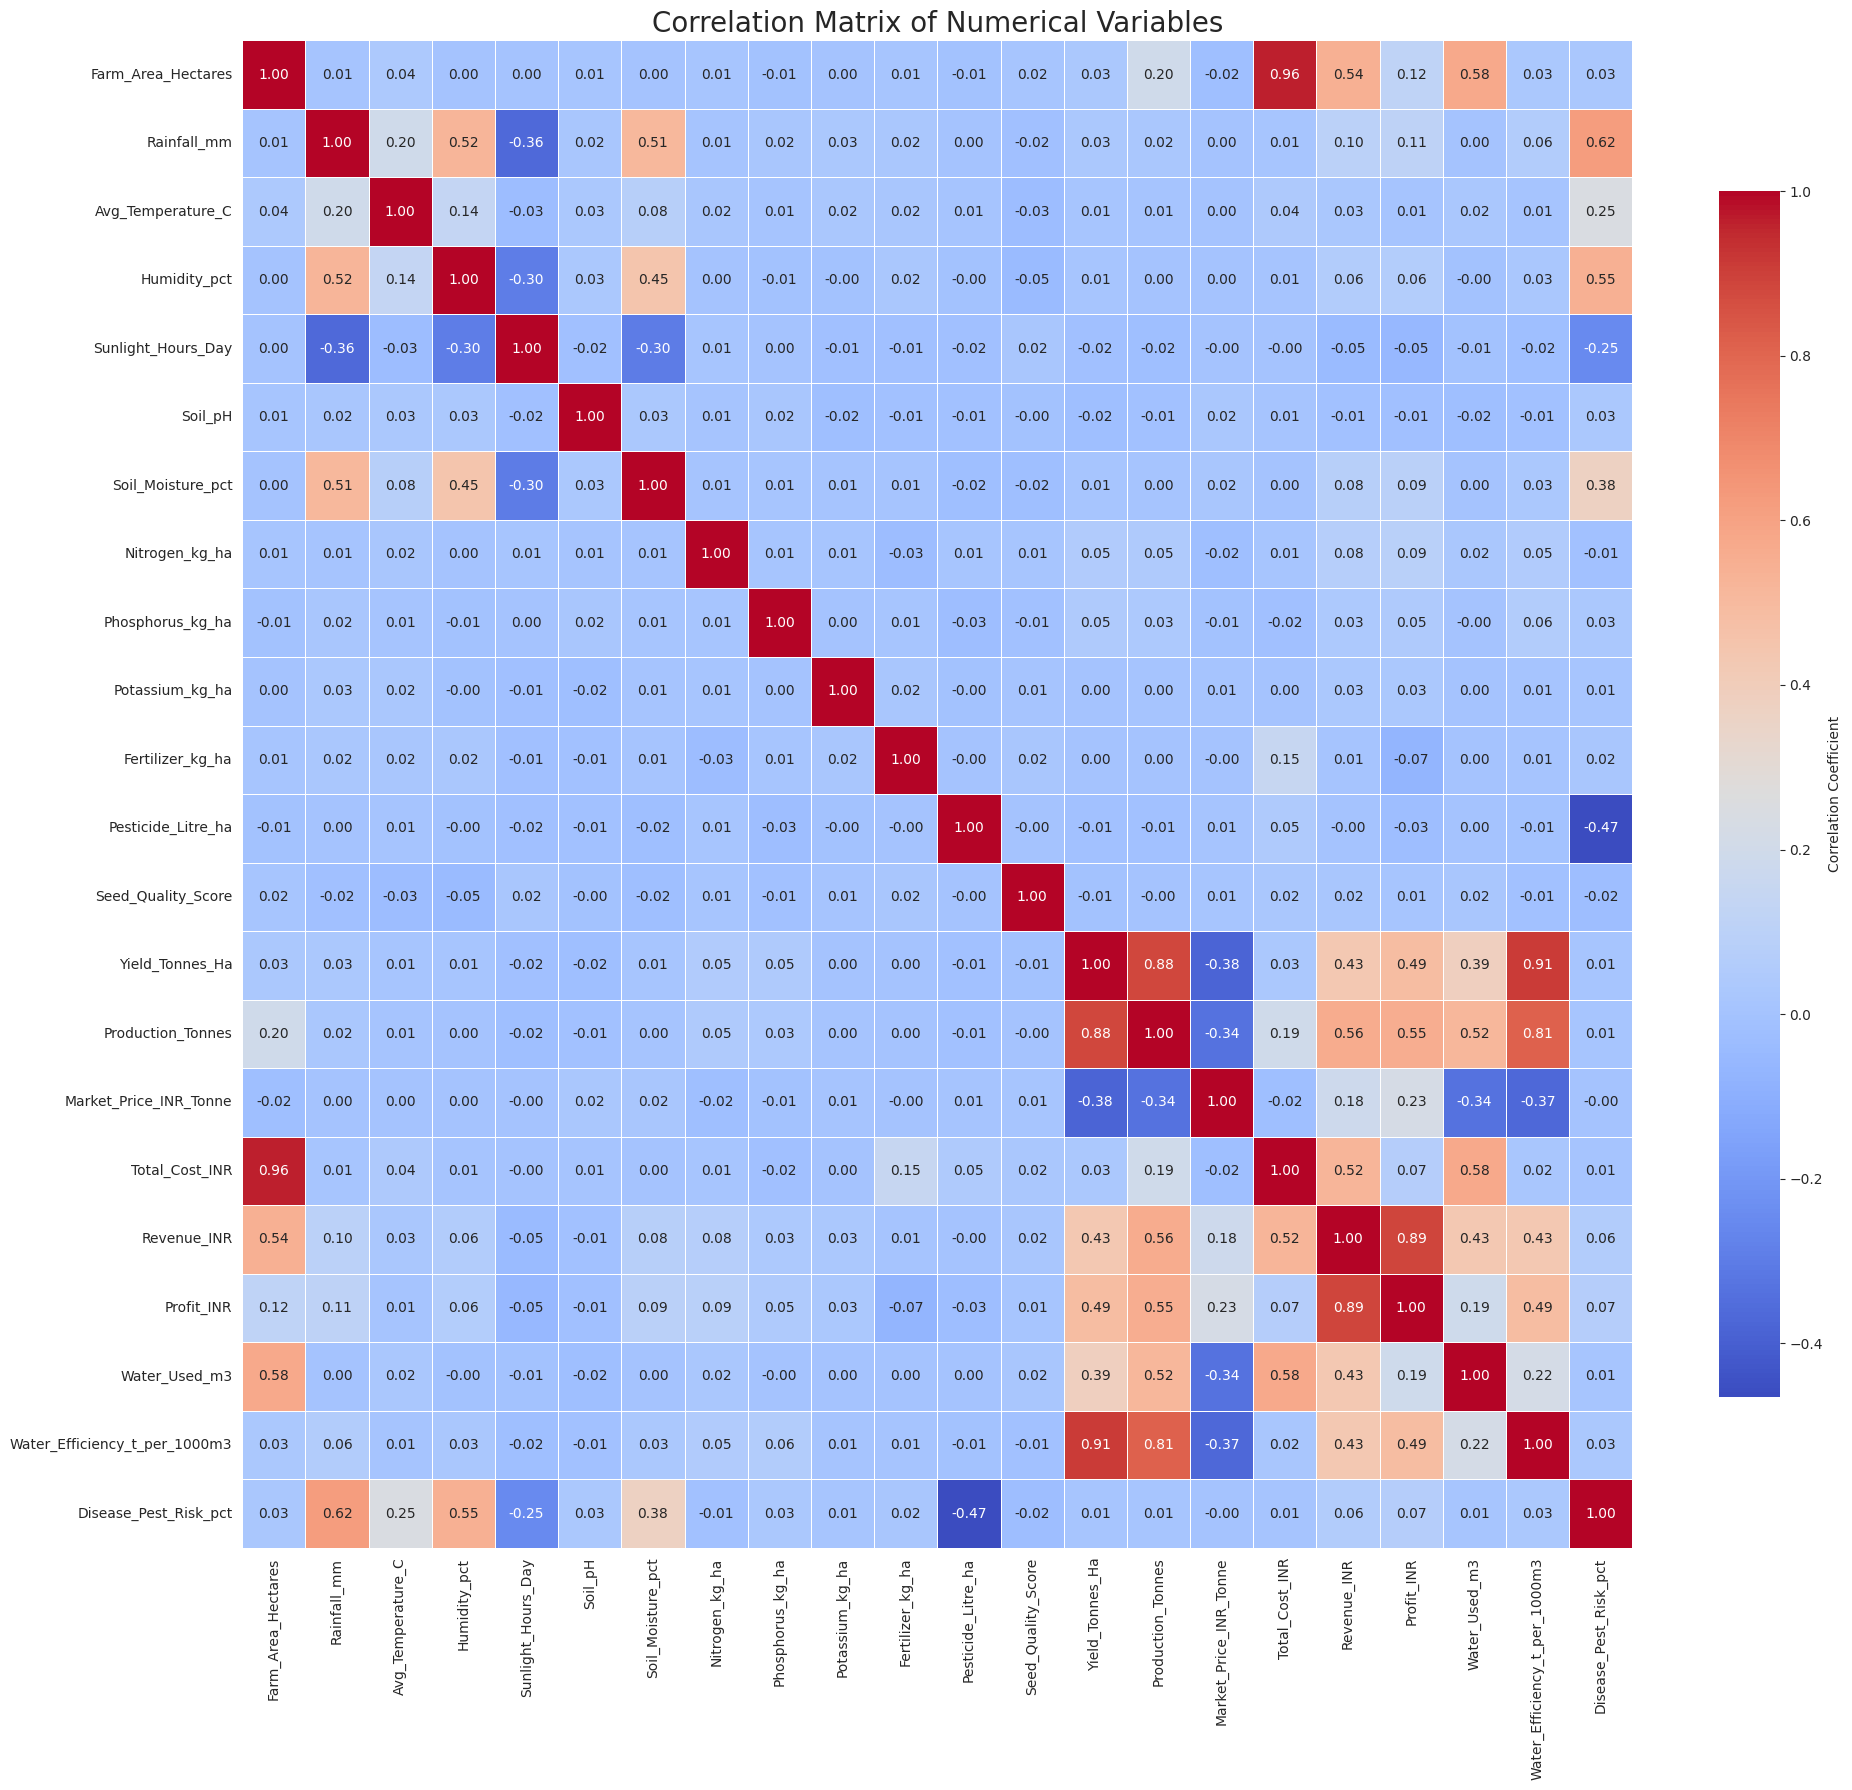

In [ ]:
# Select only numerical columns for correlation analysis
numerical_df = df.select_dtypes(include=np.number)

# Calculate the Pearson correlation matrix
correlation_matrix = numerical_df.corr(method='pearson')

# Set up the matplotlib figure
plt.figure(figsize=(20, 18)) # Adjust figure size for better readability

# Draw the heatmap
sns.heatmap(correlation_matrix,
            annot=True,      # Annotate the heatmap with the correlation values
            fmt=".2f",       # Format annotations to two decimal places
            cmap='coolwarm', # Choose a diverging colormap for clear distinction of positive/negative correlations
            linewidths=.5,   # Add lines between cells for clarity
            cbar_kws={'shrink': .8, 'label': 'Correlation Coefficient'})

plt.title('Correlation Matrix of Numerical Variables', fontsize=20)
plt.xticks(rotation=90, fontsize=10) # Rotate x-axis labels for better readability
plt.yticks(rotation=0, fontsize=10)  # Ensure y-axis labels are horizontal
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

#### **Observation on Correlation Heatmap**

From the correlation heatmap, we can observe the following key relationships:

*   **Yield, Revenue, and Profit:**
    *   `Yield_Tonnes_Ha` shows a **strong positive correlation** with `Production_Tonnes` (as expected) and a **moderate to strong positive correlation** with `Revenue_INR` and `Profit_INR`. This confirms that higher yields generally lead to higher revenue and profit.
    *   `Revenue_INR` and `Profit_INR` are **very strongly positively correlated** with each other and `Total_Cost_INR`. This indicates that farms with higher investments (costs) tend to generate higher revenues, and successful operations manage to convert this revenue into profit.

*   **Water Usage and Efficiency:**
    *   `Water_Used_m3` has a **moderate positive correlation** with `Yield_Tonnes_Ha`, `Production_Tonnes`, and to some extent, `Revenue_INR` and `Profit_INR`. This suggests that adequate water availability is important for production and financial outcomes.
    *   `Water_Efficiency_t_per_1000m3` shows a **moderate positive correlation** with `Yield_Tonnes_Ha` and `Profit_INR`. This implies that more efficient water use (getting more yield per unit of water) contributes positively to both production and profitability.

*   **Environmental Factors:**
    *   `Rainfall_mm` shows a **weak positive correlation** with `Yield_Tonnes_Ha` and `Production_Tonnes`, and similarly weak correlations with economic metrics. This supports earlier visual observations of a non-linear or optimal range relationship rather than a strong linear one.
    *   `Avg_Temperature_C`, `Humidity_pct`, `Sunlight_Hours_Day`, `Soil_pH`, and `Soil_Moisture_pct` generally show **weak to negligible linear correlations** with `Yield_Tonnes_Ha`, `Revenue_INR`, and `Profit_INR`. This reinforces the idea that their impact on yield and profit is likely more complex, possibly involving optimal ranges or interactions with other variables, as seen in previous scatter plots.

*   **Input Factors (Nutrients, Fertilizer, Pesticide, Seed Quality):**
    *   `Nitrogen_kg_ha`, `Phosphorus_kg_ha`, `Potassium_kg_ha`, `Fertilizer_kg_ha`, `Pesticide_Litre_ha` generally have **weak positive correlations** with `Yield_Tonnes_Ha`, `Production_Tonnes`, `Revenue_INR`, and `Profit_INR`. While essential for growth, their linear relationship with outcomes is not very strong, suggesting diminishing returns or optimal application rates rather than a purely linear increase in benefits.
    *   `Seed_Quality_Score` also exhibits a **weak positive correlation** with `Yield_Tonnes_Ha` and economic outcomes, indicating its importance but also that it's one of many contributing factors.

*   **Disease/Pest Risk:**
    *   `Disease_Pest_Risk_pct` shows a **weak negative correlation** with `Yield_Tonnes_Ha`, `Production_Tonnes`, and economic metrics, which is expected as higher risk would generally lead to lower performance.

**Overall Takeaway:**
The heatmap confirms several visual observations, particularly the strong link between yield, revenue, and profit. While most environmental and input factors show weak linear correlations individually, their combined effect and optimal ranges are likely more critical, as indicated by previous non-linear observations. `Total_Cost_INR` and `Revenue_INR` are highly correlated, reflecting the direct financial cycle of farming.

## **Seasonal Analysis**

📌 **Overview**

Seasonal analysis involves examining agricultural performance and environmental factors across different cropping seasons (Kharif, Rabi, Zaid). This section aims to identify seasonal trends, differences in crop suitability, resource utilization, and economic outcomes.

Why are we doing this?
Agriculture is inherently seasonal. Understanding how variables like rainfall, temperature, and crop yields vary by season is crucial for optimizing planting schedules, resource management, and risk mitigation. This analysis will help us make informed recommendations tailored to the specific characteristics of each season, leading to improved productivity and profitability.

### **Average Yield by Season**

**Overview**
This analysis calculates and visualizes the average `Yield_Tonnes_Ha` for each `Season`. By comparing the mean yield across different seasons, we can identify which seasons are generally more productive.

**Why are we doing this?**
Understanding the average yield per season is fundamental for agricultural planning and resource allocation. It helps in identifying optimal planting times for specific crops or in understanding the inherent productivity differences that each season brings due to varying environmental conditions (e.g., temperature, rainfall, sunlight). This insight can inform decisions on crop rotation and seasonal cropping strategies.

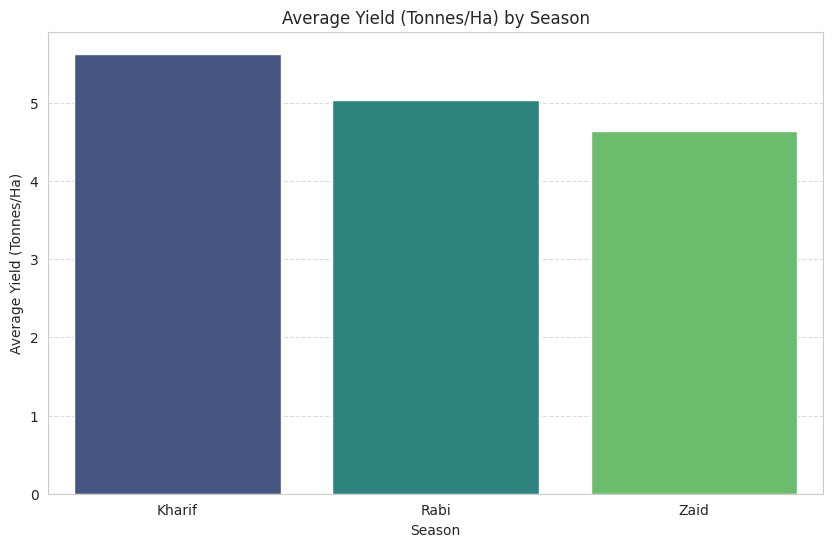

In [ ]:
# Calculate average yield per season
avg_yield_by_season = df.groupby('Season')['Yield_Tonnes_Ha'].mean().reset_index()

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Season', y='Yield_Tonnes_Ha', data=avg_yield_by_season, palette='viridis', hue='Season', legend=False)
plt.title('Average Yield (Tonnes/Ha) by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Observation on Average Yield by Season**

From the bar chart showing average yield by season, we can observe the following:

*   The **Kharif season** exhibits the highest average yield, followed by **Rabi**.
*   The **Zaid season** consistently shows the lowest average yield, significantly lower than the other two seasons.

This trend is expected, as Kharif (monsoon season) and Rabi (winter season) are typically the main agricultural seasons with more favorable conditions for a wider variety of crops, leading to higher productivity. Zaid, being a shorter and often hotter season, usually supports fewer crops and thus has lower average yields.

### **Average Profit by Season**

**Overview**
This analysis calculates and visualizes the average `Profit_INR` for each `Season`. By comparing the mean profit across different seasons, we can identify which seasons are generally more economically beneficial for farmers.

**Why are we doing this?**
Understanding the average profitability per season is crucial for farmers and policymakers to make informed financial decisions. It helps in identifying which seasons offer better returns on investment, potentially guiding decisions on crop selection, resource allocation, and market strategies to maximize earnings. This insight complements yield data by providing a financial perspective on seasonal performance.

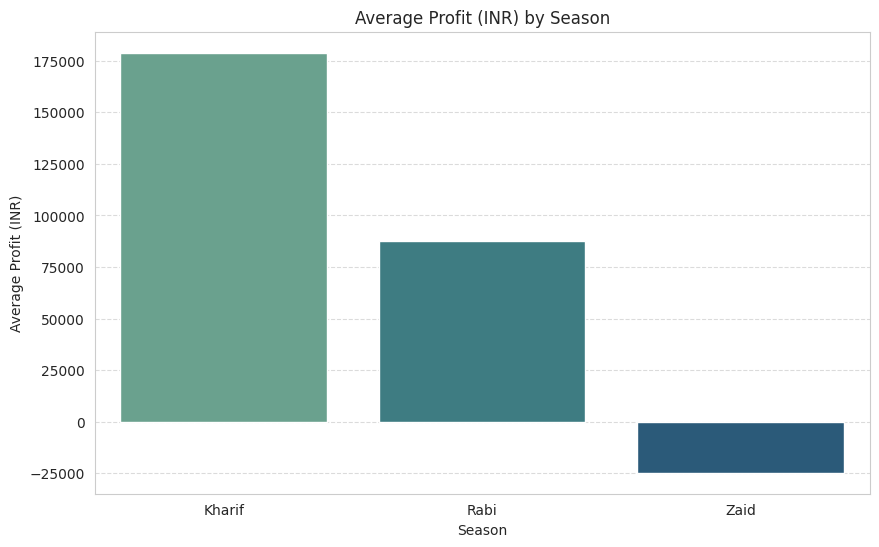

In [ ]:
# Calculate average profit per season
avg_profit_by_season = df.groupby('Season')['Profit_INR'].mean().reset_index()

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Season', y='Profit_INR', data=avg_profit_by_season, palette='crest', hue='Season', legend=False)
plt.title('Average Profit (INR) by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Observation on Average Profit by Season**

From the bar chart showing average profit by season, we can observe the following:

*   The **Kharif season** records the highest average profit, followed by **Rabi**.
*   The **Zaid season** shows the lowest average profit, often significantly less or even close to break-even compared to the other two seasons.

This pattern mirrors the average yield by season, suggesting a strong correlation between higher productivity and higher profitability. The more favorable environmental conditions in Kharif and Rabi likely contribute to better yields, which in turn lead to higher revenues and profits. The lower profit in Zaid can be attributed to its shorter duration, less favorable climate, and potentially higher input costs for irrigation.

### **Yield Distribution by Season**

**Overview**
This analysis visualizes the distribution of `Yield_Tonnes_Ha` for each `Season` using box plots. Box plots are excellent for showing the median, quartiles, and potential outliers of a numerical distribution across different categorical groups.

**Why are we doing this?**
Understanding the spread and central tendency of yield for each season provides deeper insights than just the average. It helps identify seasonal variations in yield consistency, the range of typical yields, and whether certain seasons are prone to unusually high or low yields (outliers). This information is crucial for risk assessment and optimizing crop planning based on seasonal yield reliability.

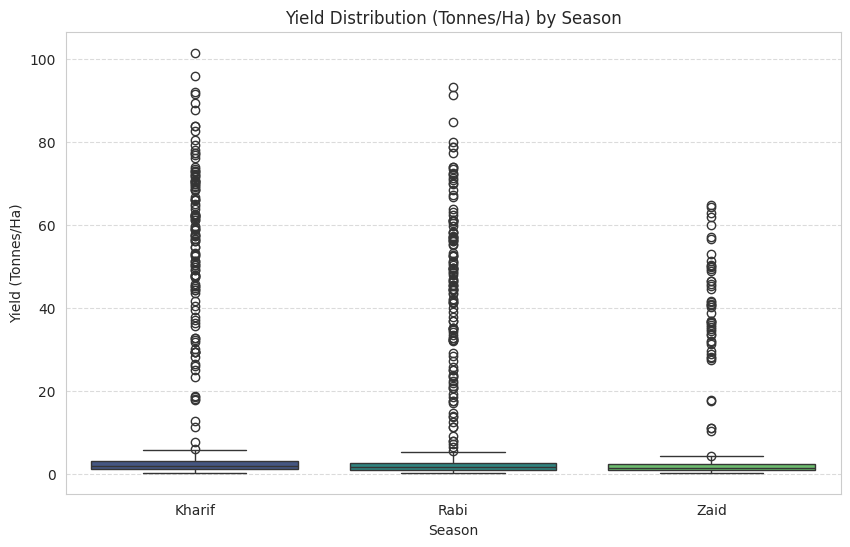

In [ ]:
# Create a box plot to visualize Yield Distribution by Season
plt.figure(figsize=(10, 6))
sns.boxplot(x='Season', y='Yield_Tonnes_Ha', data=df, palette='viridis', hue='Season', legend=False)
plt.title('Yield Distribution (Tonnes/Ha) by Season')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Observation on Yield Distribution by Season**

From the box plot illustrating yield distribution by season, we can observe the following:

*   **Kharif and Rabi Seasons:** Both Kharif and Rabi seasons show a relatively wide spread of yields, with numerous outliers indicating instances of both very high and very low yields. The median yields are higher in these seasons compared to Zaid, and the interquartile range (IQR) suggests a greater variability in yield outcomes.

*   **Zaid Season:** The Zaid season generally exhibits a tighter distribution with lower median yield and a smaller IQR. While it still has outliers, they are less frequent or less extreme compared to Kharif and Rabi, suggesting more consistent but lower yields overall for the majority of farms during this season.

*   **Outliers:** The presence of numerous outliers in all seasons, especially Kharif and Rabi, indicates that while certain environmental conditions might be more favorable, there are always farms that perform exceptionally well or poorly. This highlights the influence of other factors (e.g., specific crop choices, farming practices, localized conditions) beyond just the season.

This distribution analysis confirms that while Kharif and Rabi offer higher yield potential, they also come with greater variability. Zaid, while having lower overall yield, appears to offer more predictable outcomes for the majority of farms.

### **Rainfall Distribution by Season**

**Overview**
This analysis visualizes the distribution of `Rainfall_mm` for each `Season` using box plots. This helps in understanding the typical rainfall patterns and variability across the different agricultural seasons.

**Why are we doing this?**
Rainfall is a primary driver of agricultural success, especially in rainfed regions. By examining its distribution by season, we can identify which seasons are naturally wetter, which are drier, and the extent of rainfall variability within each. This knowledge is critical for water management strategies, selecting drought-resistant crops, and assessing the risk of water scarcity or excess during different cultivation periods.

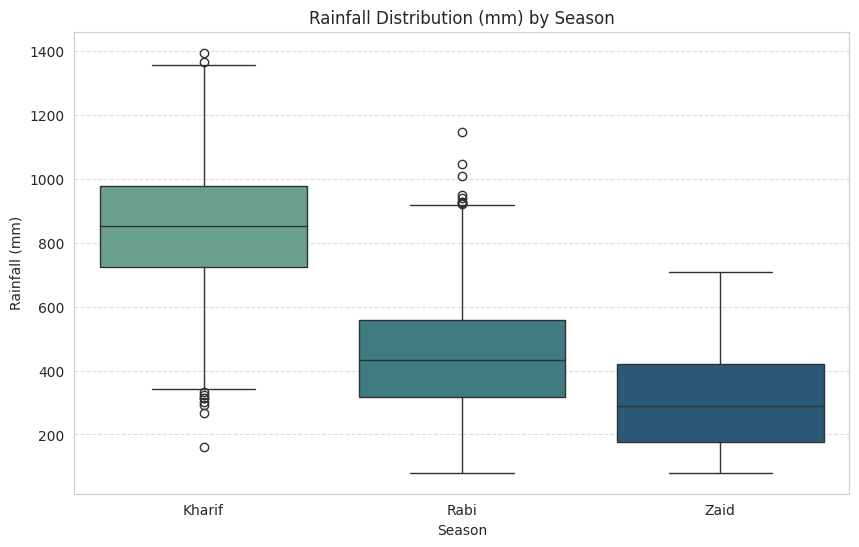

In [ ]:
# Create a box plot to visualize Rainfall Distribution by Season
plt.figure(figsize=(10, 6))
sns.boxplot(x='Season', y='Rainfall_mm', data=df, palette='crest', hue='Season', legend=False)
plt.title('Rainfall Distribution (mm) by Season')
plt.xlabel('Season')
plt.ylabel('Rainfall (mm)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Observation on Rainfall Distribution by Season**

From the box plot illustrating rainfall distribution by season, we can observe the following:

*   **Kharif Season:** The Kharif season shows the highest median rainfall and the widest interquartile range (IQR), indicating it is generally the wettest season with significant variability in rainfall. This aligns with the typical monsoon season in many agricultural regions. There are also numerous outliers, suggesting instances of exceptionally heavy rainfall.

*   **Rabi Season:** The Rabi season has a lower median rainfall compared to Kharif, but still a considerable amount, with a narrower IQR. This indicates a more consistent, moderate rainfall pattern. Outliers are present but less frequent than in Kharif.

*   **Zaid Season:** The Zaid season consistently exhibits the lowest median rainfall and the smallest IQR, confirming it as the driest season with the least rainfall variability. This suggests that crops cultivated during Zaid often rely more heavily on irrigation due to naturally low precipitation.

This analysis clearly delineates the distinct rainfall profiles of each season, reinforcing the importance of season-specific agricultural strategies, especially concerning water management and crop selection tailored to available moisture.

## **Crop Performance Analysis**

📌 **Overview**
Crop performance analysis focuses on evaluating the productivity and profitability of different crop types. This section aims to identify high-performing crops, understand their resource requirements, and assess their economic viability. By analyzing yield, profit, and other key metrics per crop, we can provide valuable insights for crop selection and agricultural planning.

Why are we doing this?
Understanding crop-specific performance is essential for optimizing agricultural output and farmer income. Different crops have varying needs and market values, and their success can depend heavily on local conditions and management practices. This analysis helps in identifying which crops are most suitable for particular regions or farming strategies, thereby maximizing efficiency and profitability. It also provides a basis for agricultural research and development to improve crop varieties and cultivation techniques.

### **Average Yield by Crop**

**Overview**
This analysis calculates and visualizes the average `Yield_Tonnes_Ha` for each `Crop` type. By comparing the mean yield across different crops, we can identify which crops are generally more productive on a per-hectare basis.

**Why are we doing this?**
Understanding the average yield per crop is fundamental for agricultural planning, crop selection, and assessing the productivity potential of different cultivation choices. It helps in identifying high-yielding crops that might be suitable for expansion or improvement, and provides a benchmark for evaluating crop varieties and farming practices. This insight is crucial for maximizing food production and resource efficiency.

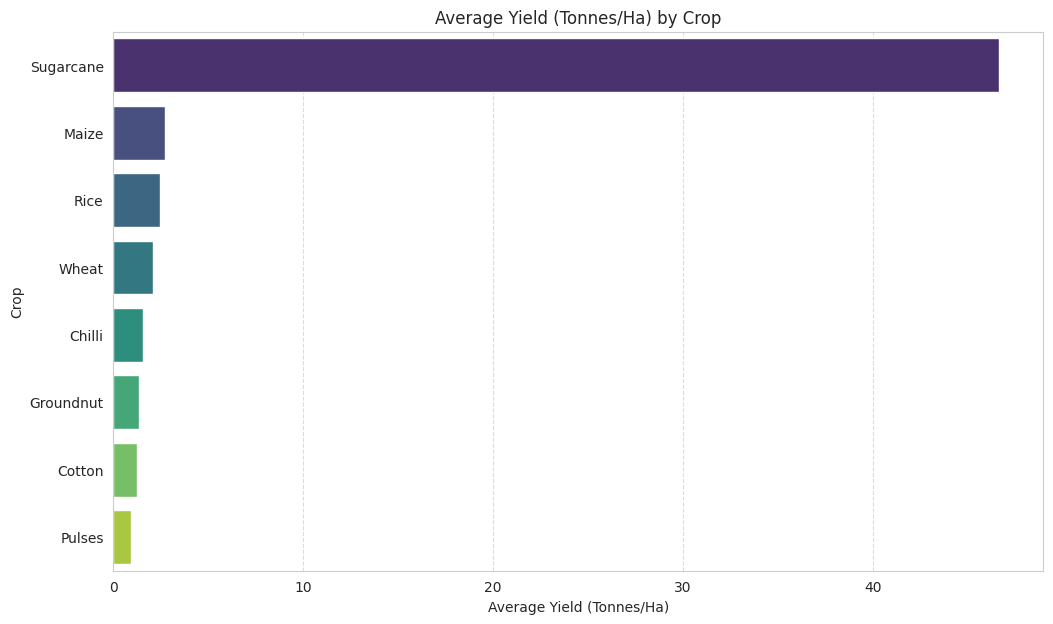

In [ ]:
# Calculate average yield per crop and sort by yield
avg_yield_by_crop = df.groupby('Crop')['Yield_Tonnes_Ha'].mean().reset_index().sort_values(by='Yield_Tonnes_Ha', ascending=False)

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Yield_Tonnes_Ha', y='Crop', data=avg_yield_by_crop, palette='viridis', hue='Crop', legend=False)
plt.title('Average Yield (Tonnes/Ha) by Crop')
plt.xlabel('Average Yield (Tonnes/Ha)')
plt.ylabel('Crop')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#### **Observation on Average Yield by Crop**

From the bar chart showing average yield by crop, we can observe the following:

*   **Sugarcane** stands out with an exceptionally high average yield compared to all other crops, indicating its high productivity per hectare within this dataset.
*   **Maize** and **Rice** show moderately high average yields, making them significant contributors to overall production.
*   **Wheat**, **Chilli**, **Groundnut**, **Cotton**, and **Pulses** generally have lower average yields compared to Sugarcane, Maize, and Rice.

This analysis highlights the distinct productivity profiles of different crops, suggesting that crop selection plays a crucial role in overall farm output. The high yield of Sugarcane implies it might be a key crop for maximizing tonnage, while other crops, despite lower yields, might be grown for economic or rotational benefits.

### **Average Profit by Crop**

**Overview**
This analysis calculates and visualizes the average `Profit_INR` for each `Crop` type. By comparing the mean profit across different crops, we can identify which crops are generally more economically beneficial for farmers.

**Why are we doing this?**
Understanding the average profitability per crop is crucial for farmers and policymakers to make informed financial decisions. It helps in identifying which crops offer better returns on investment, guiding decisions on crop diversification, market strategies, and resource allocation to maximize earnings. This insight provides a direct financial perspective on crop performance, complementing yield data with economic viability.

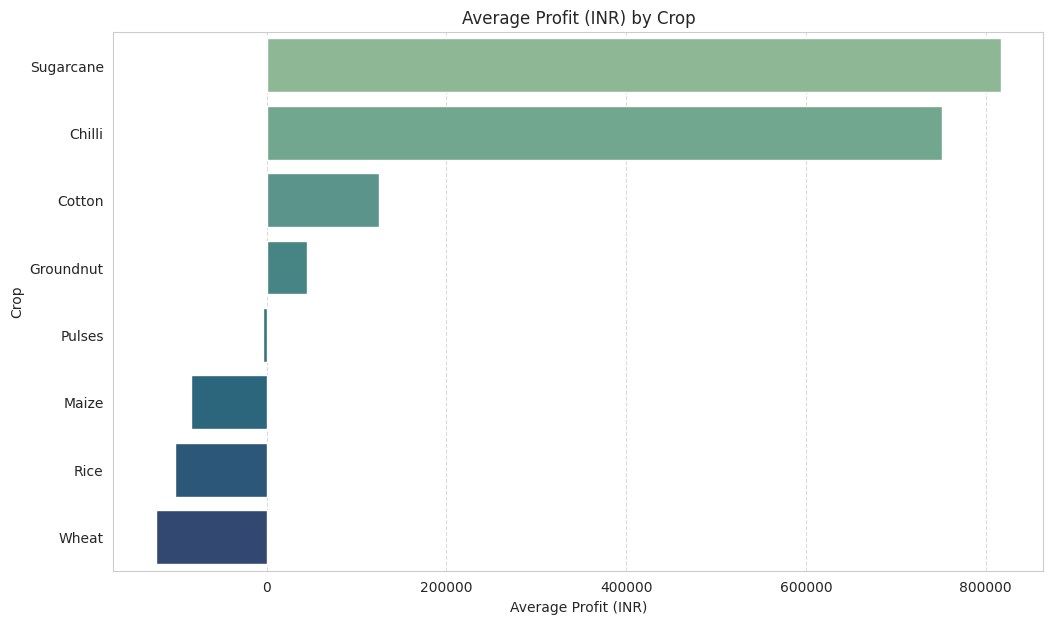

In [ ]:
# Calculate average profit per crop and sort by profit
avg_profit_by_crop = df.groupby('Crop')['Profit_INR'].mean().reset_index().sort_values(by='Profit_INR', ascending=False)

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Profit_INR', y='Crop', data=avg_profit_by_crop, palette='crest', hue='Crop', legend=False)
plt.title('Average Profit (INR) by Crop')
plt.xlabel('Average Profit (INR)')
plt.ylabel('Crop')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#### **Observation on Average Profit by Crop**

From the bar chart showing average profit by crop, we can observe the following:

*   **Sugarcane** also leads significantly in average profit, reinforcing its economic importance despite high initial investment, indicating strong market demand or price stability.
*   **Maize** and **Rice** follow, generating substantial average profits, aligning with their higher yield performance.
*   **Wheat**, **Chilli**, **Groundnut**, **Cotton**, and **Pulses** show lower average profits, with some potentially being near the break-even point or experiencing losses on average, depending on specific conditions.

This analysis confirms that higher-yielding crops like Sugarcane, Maize, and Rice are also generally the most profitable. This suggests a direct link between productivity and economic return, guiding farmers towards choices that maximize both yield and profit. However, it's also important to consider the variability and risks associated with each crop.

### **Crop × Season Yield Comparison**

**Overview**
This analysis visualizes the average `Yield_Tonnes_Ha` for each `Crop` type across different `Season`s using a heatmap. The heatmap will show which crops perform best in which seasons, providing a clear visual representation of optimal crop-season combinations.

**Why are we doing this?**
Understanding how different crops perform across various seasons is crucial for effective agricultural planning and maximizing productivity. Environmental conditions like temperature, rainfall, and sunlight vary significantly by season, directly impacting crop growth. By analyzing the mean yield of each crop in each season, farmers can make informed decisions about crop selection and planting schedules to best suit the prevailing seasonal conditions, thereby enhancing overall yield and profitability. This also helps in identifying crops that are more resilient or adaptable to specific seasonal challenges.

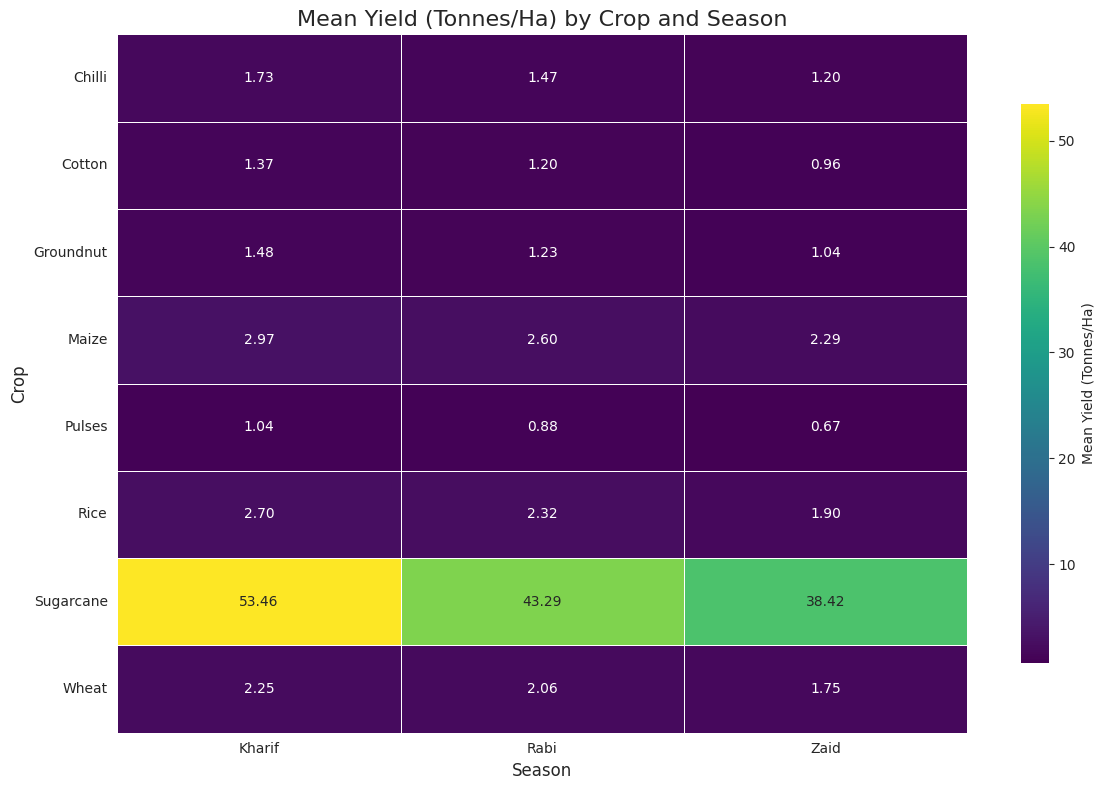

In [ ]:
# Create a pivot table for mean Yield_Tonnes_Ha by Crop and Season
yield_pivot_crop_season = df.pivot_table(values='Yield_Tonnes_Ha', index='Crop', columns='Season', aggfunc='mean')

# Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# Draw the heatmap
sns.heatmap(yield_pivot_crop_season,
            annot=True,      # Annotate the heatmap with the correlation values
            fmt=".2f",       # Format annotations to two decimal places
            cmap='viridis',  # Choose a colormap
            linewidths=.5,   # Add lines between cells for clarity
            cbar_kws={'shrink': .8, 'label': 'Mean Yield (Tonnes/Ha)'})

plt.title('Mean Yield (Tonnes/Ha) by Crop and Season', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Crop', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0) # Ensure y-axis labels are horizontal
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

#### **Observation on Crop × Season Yield Comparison**

From the heatmap visualizing mean yield by crop and season, we can observe the following:

*   **Sugarcane Dominance:** Sugarcane consistently demonstrates the highest mean yields across all three seasons (Kharif, Rabi, and Zaid), with the highest peak in Kharif. This indicates its strong productivity regardless of the season, though it still benefits from Kharif's conditions.

*   **Seasonal Preferences for Other Crops:**
    *   **Kharif Season:** Many crops, including Rice, Maize, and Sugarcane, show their highest average yields in the Kharif season, suggesting it's a generally favorable period due to factors like rainfall.
    *   **Rabi Season:** Wheat and some other crops maintain decent yields in Rabi, but overall, yields are generally lower than Kharif for most crops.
    *   **Zaid Season:** The Zaid season generally records the lowest average yields for almost all crops, reinforcing the idea that it's a challenging season, likely due to higher temperatures and lower rainfall, making it less productive.

*   **Crop-Specific Performance:** While Sugarcane leads across the board, crops like Maize and Rice are significant contributors, particularly in Kharif. Other crops like Pulses consistently show lower yields across all seasons.

This analysis clearly illustrates the varying suitability of different crops to different seasons, highlighting the importance of season-specific crop selection for optimizing agricultural output. It provides actionable insights for farmers to choose the most productive crops for each cultivation period.

## **Environmental Analysis**

📌 **Overview**

Environmental analysis in agriculture focuses on understanding how various natural conditions—such as humidity, temperature, rainfall, and sunlight—impact crop growth, yield, and overall farm productivity. This section aims to identify key environmental drivers and their influence on agricultural outcomes.

Why are we doing this?
Environmental factors are fundamental determinants of agricultural success. By analyzing their relationships with yield and other performance metrics, we can gain insights into optimal growing conditions, assess environmental risks (e.g., drought, excessive heat), and inform strategies for climate-resilient farming. This analysis is crucial for adapting agricultural practices to local climatic conditions and for developing models that predict crop performance based on environmental inputs.

### **Humidity vs. Yield**

**Overview**
This analysis explores the relationship between humidity percentage and crop yield (tonnes per hectare) to understand how atmospheric moisture influences agricultural productivity.

**Why are we doing this?**
Understanding how humidity affects crop yield is critical for assessing environmental suitability and optimizing farming practices. Extreme humidity levels (either too low or too high) can negatively impact plant health, pollination, and disease susceptibility, directly influencing overall productivity. This analysis helps identify optimal humidity ranges for better yield outcomes and informs decisions on crop selection and environmental management strategies.

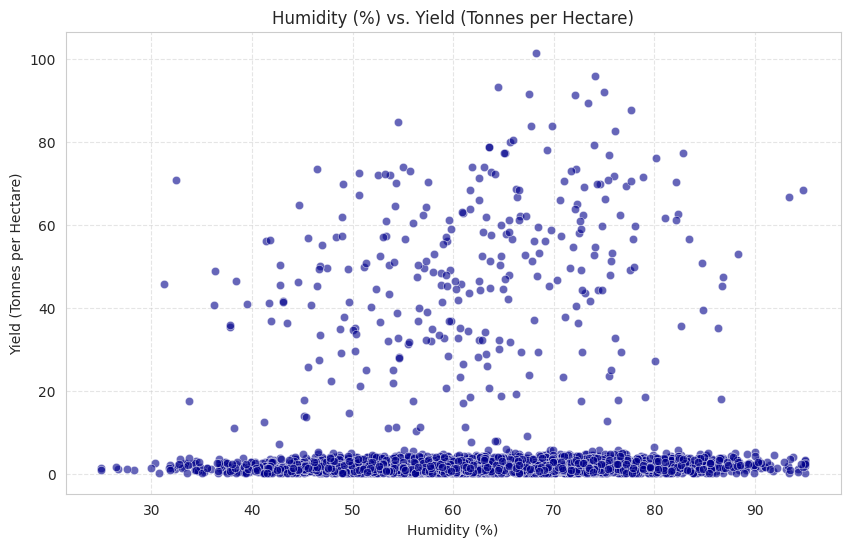

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Humidity_pct', y='Yield_Tonnes_Ha', color='darkblue', alpha=0.6)
plt.title('Humidity (%) vs. Yield (Tonnes per Hectare)')
plt.xlabel('Humidity (%)')
plt.ylabel('Yield (Tonnes per Hectare)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### **Observation on Humidity vs. Yield Relationship**

From the scatter plot of `Humidity_pct` against `Yield_Tonnes_Ha`, we can observe the following:

*   There is no strong linear correlation between humidity and yield across the entire range of data. The points are quite scattered.
*   However, higher yields (above 10-20 tonnes/hectare) tend to be concentrated within a humidity range of approximately **55% to 75%**. This suggests an optimal humidity window for maximizing yield.
*   At very low humidity levels (below ~40%) and very high humidity levels (above ~85%), yields tend to be lower or clustered around the lower end.
*   The majority of farms with low yields (below 5 tonnes/hectare) are present across almost the entire spectrum of humidity, indicating that while humidity is a factor, other variables also play a significant role in determining very low yields.

This visual analysis suggests a non-linear or complex relationship, where moderate humidity might be beneficial, but extreme humidity levels (either too low or too high) could negatively impact crop yield. Further statistical analysis and consideration of other interacting factors would provide a more nuanced understanding of this relationship.

### **Sunlight Hours vs. Yield**

**Overview**
This analysis explores the relationship between daily sunlight hours and crop yield (tonnes per hectare) to understand how light availability influences agricultural productivity.

**Why are we doing this?**
Sunlight is a fundamental requirement for photosynthesis, the process by which plants convert light energy into chemical energy for growth. Understanding the relationship between sunlight hours and yield is crucial for optimizing crop calendars, selecting appropriate crop varieties, and assessing the productivity potential of different regions. Insufficient or excessive sunlight can stress plants and reduce yields, making this analysis vital for maximizing agricultural output.

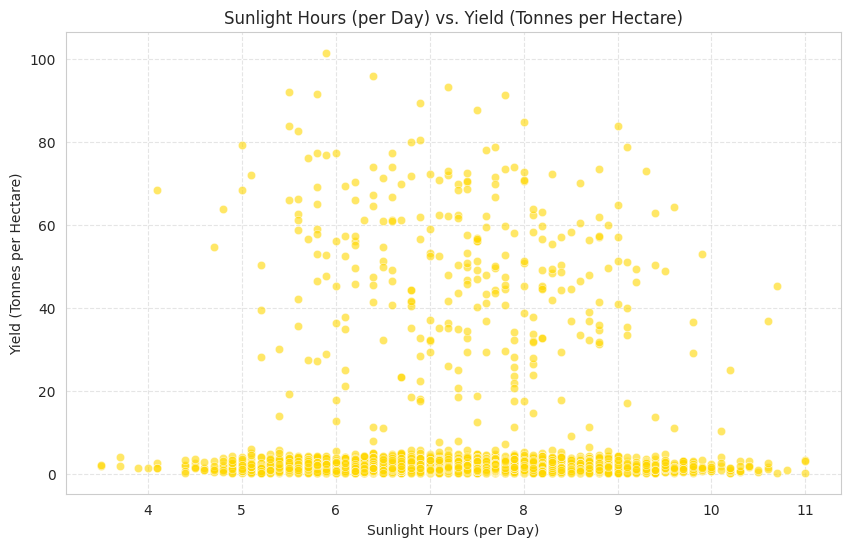

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Sunlight_Hours_Day', y='Yield_Tonnes_Ha', color='gold', alpha=0.6)
plt.title('Sunlight Hours (per Day) vs. Yield (Tonnes per Hectare)')
plt.xlabel('Sunlight Hours (per Day)')
plt.ylabel('Yield (Tonnes per Hectare)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### **Observation on Sunlight Hours vs. Yield Relationship**

From the scatter plot of `Sunlight_Hours_Day` against `Yield_Tonnes_Ha`, we can observe the following:

*   There is no strong linear correlation between sunlight hours and yield across the entire range of data. The points are quite scattered.
*   However, higher yields (above 10-20 tonnes/hectare) tend to be concentrated within a sunlight hours range of approximately **6.5 to 8.5 hours per day**. This suggests an optimal sunlight window for maximizing yield.
*   At very low sunlight levels (below ~5 hours) and very high sunlight levels (above ~9.5 hours), yields tend to be lower or clustered around the lower end.
*   The majority of farms with low yields (below 5 tonnes/hectare) are present across almost the entire spectrum of sunlight hours, indicating that while sunlight is a factor, other variables also play a significant role in determining very low yields.

This visual analysis suggests a non-linear or complex relationship, where moderate sunlight might be beneficial, but extreme sunlight levels (either too low or too high) could negatively impact crop yield. Further statistical analysis and consideration of other interacting factors would provide a more nuanced understanding of this relationship.

## **Resource/Input Analysis**

📌 **Overview**

Resource/Input analysis in agriculture examines the utilization and impact of key farm inputs such as fertilizers, pesticides, seeds, and water. This section aims to understand how these critical resources are applied, their variability, and their potential influence on agricultural productivity and economic outcomes.

Why are we doing this?
Efficient management of agricultural resources is paramount for sustainable farming, maximizing yields, and ensuring profitability. By analyzing resource usage patterns, we can identify areas of optimal application, potential inefficiencies, and opportunities for cost reduction or yield enhancement. This analysis helps in developing more precise farming strategies, promoting sustainable practices, and improving overall farm resilience.

### **Fertilizer Usage by Season**

**Overview**
This analysis calculates and visualizes the average `Fertilizer_kg_ha` for each `Season`. By comparing the mean fertilizer usage across different seasons, we can identify seasonal patterns in nutrient management.

**Why are we doing this?**
Understanding how fertilizer application varies by season is essential for optimizing nutrient management strategies. Different crops and climatic conditions in each season may require varied fertilizer inputs. This analysis helps in identifying appropriate seasonal application rates, assessing potential over- or under-fertilization, and contributing to more sustainable and cost-effective farming practices.

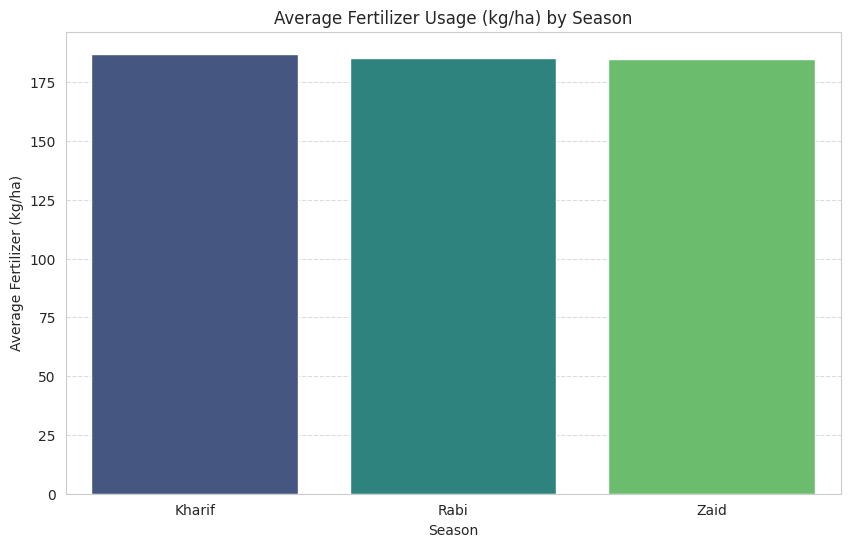

In [ ]:
# Calculate average fertilizer usage per season
avg_fertilizer_by_season = df.groupby('Season')['Fertilizer_kg_ha'].mean().reset_index()

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Season', y='Fertilizer_kg_ha', data=avg_fertilizer_by_season, palette='viridis', hue='Season', legend=False)
plt.title('Average Fertilizer Usage (kg/ha) by Season')
plt.xlabel('Season')
plt.ylabel('Average Fertilizer (kg/ha)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Observation on Fertilizer Usage by Season**

From the bar chart showing average fertilizer usage by season, we can observe the following:

*   Fertilizer application rates appear to be highest in the **Kharif season**, followed by **Rabi**, and then **Zaid** with the lowest average usage.
*   This pattern generally aligns with the observed yield and profit distributions, where Kharif and Rabi are typically more productive seasons, likely necessitating and benefiting from higher nutrient inputs.
*   The lower fertilizer usage in the Zaid season could be attributed to its shorter duration, specific crop choices, or less intensive cultivation practices during this period.

This analysis suggests that farmers adjust their fertilizer application based on seasonal crop cycles and expected productivity. Optimizing these rates for each season is crucial for maximizing yield and profitability while also managing environmental impact.

### **Water Usage by Season**

**Overview**
This analysis calculates and visualizes the average `Water_Used_m3` for each `Season`. By comparing the mean water usage across different seasons, we can identify seasonal patterns in irrigation and water management.

**Why are we doing this?**
Understanding seasonal water usage is critical for efficient water resource management in agriculture. Water availability and demand vary significantly with rainfall patterns and crop needs during different seasons. This analysis helps in identifying seasons with high irrigation demands, assessing water efficiency, and informing strategies for water conservation and sustainable water practices.

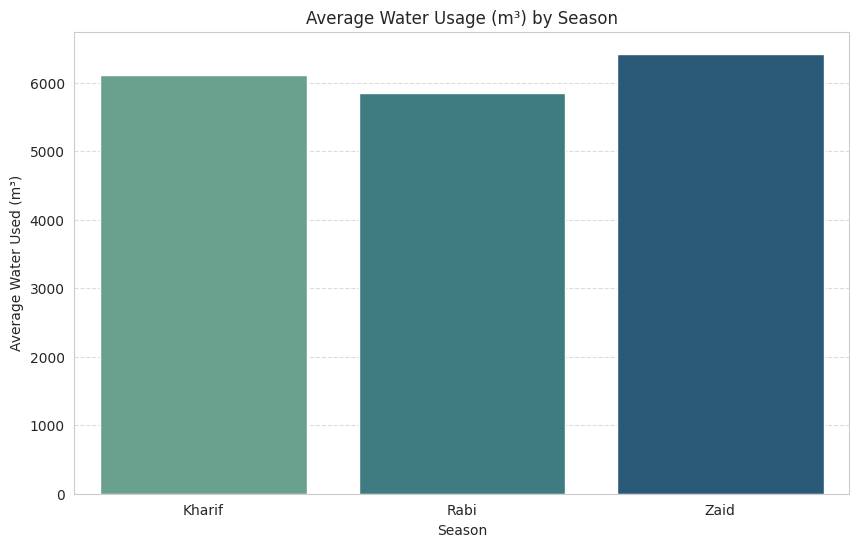

In [ ]:
# Calculate average water usage per season
avg_water_by_season = df.groupby('Season')['Water_Used_m3'].mean().reset_index()

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Season', y='Water_Used_m3', data=avg_water_by_season, palette='crest', hue='Season', legend=False)
plt.title('Average Water Usage (m³) by Season')
plt.xlabel('Season')
plt.ylabel('Average Water Used (m³)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Observation on Water Usage by Season**

From the bar chart showing average water usage by season, we can observe the following:

*   The **Kharif season** shows the highest average water usage, followed by **Rabi**.
*   The **Zaid season** has the lowest average water usage, although it is still significant, especially considering it is typically the driest season.

This distribution reflects a logical pattern where seasons with higher rainfall (Kharif) or significant crop growth (Kharif and Rabi) require substantial water inputs, either from natural precipitation or irrigation. The lower water usage in Zaid might indicate a reliance on crops with lower water requirements or a more limited cultivation area due to water scarcity during this hot, dry period. Efficient water management strategies tailored to each season are essential for sustainable agricultural production.

## **Irrigation Analysis**

📌 **Overview**

Irrigation analysis in agriculture focuses on understanding the various methods used for water application, their efficiency, and their impact on crop yield, water usage, and overall farm economics. This section aims to evaluate the effectiveness of different irrigation techniques and their implications for sustainable water management.

Why are we doing this?
Efficient irrigation is crucial for agricultural productivity, especially in regions facing water scarcity or variable rainfall. By analyzing the performance of different irrigation methods, we can identify practices that optimize water use, maximize yields, and enhance profitability. This analysis helps in making informed decisions about technology adoption, resource allocation, and policy development for improved water management in farming.

### **Yield by Irrigation Method**

**Overview**
This analysis visualizes the distribution of `Yield_Tonnes_Ha` for each `Irrigation_Method` using box plots. Box plots are excellent for showing the median, quartiles, and potential outliers of a numerical distribution across different categorical groups.

**Why are we doing this?**
Understanding how crop yield varies across different irrigation methods provides crucial insights into the effectiveness of each method. It helps identify which methods are associated with higher yields, more consistent production, or greater variability. This information is vital for farmers to select appropriate irrigation techniques that align with their crop types, environmental conditions, and productivity goals.

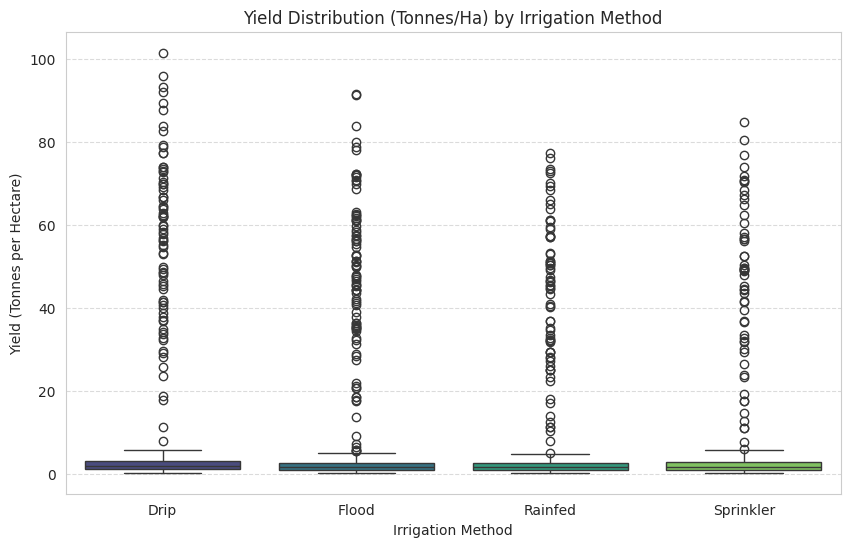

In [ ]:
# Create a box plot to visualize Yield Distribution by Irrigation Method
plt.figure(figsize=(10, 6))
sns.boxplot(x='Irrigation_Method', y='Yield_Tonnes_Ha', data=df, palette='viridis', hue='Irrigation_Method', legend=False)
plt.title('Yield Distribution (Tonnes/Ha) by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Yield (Tonnes per Hectare)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Observation on Yield by Irrigation Method**

From the box plot showing yield distribution by irrigation method, we can observe the following:

*   **Drip irrigation** appears to be associated with a higher median yield compared to other methods, and potentially a narrower interquartile range, suggesting more consistent yields.
*   **Sprinkler and Flood irrigation** methods show moderate median yields with varying degrees of spread and outliers.
*   **Rainfed** agriculture generally exhibits the lowest median yield and often a wider spread, indicating greater variability in yields, which is expected due to its reliance on natural rainfall.
*   All irrigation methods show a presence of outliers, indicating instances of exceptionally high or low yields regardless of the primary irrigation technique. This suggests that while irrigation method is an important factor, other variables also play a significant role in determining extreme yield outcomes.

### **Water Usage by Irrigation Method**

**Overview**
This analysis calculates and visualizes the average `Water_Used_m3` for each `Irrigation_Method` using a bar chart. By comparing the mean water usage across different irrigation methods, we can identify which methods typically consume more or less water.

**Why are we doing this?**
Understanding the average water consumption of different irrigation methods is essential for promoting water efficiency and sustainability in agriculture. It helps in identifying water-intensive practices versus more water-saving techniques. This insight is crucial for resource management, cost reduction, and adapting farming practices in areas with limited water availability.

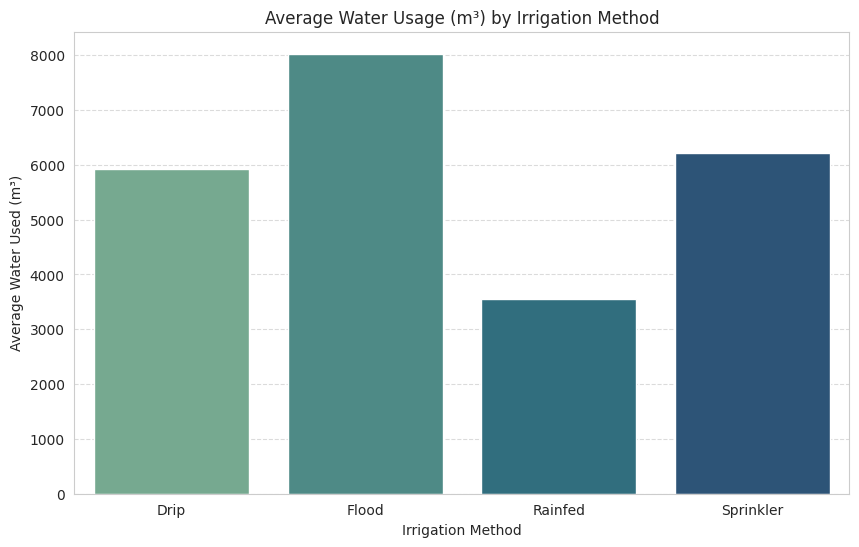

In [ ]:
# Calculate average water usage per irrigation method
avg_water_by_irrigation = df.groupby('Irrigation_Method')['Water_Used_m3'].mean().reset_index()

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Irrigation_Method', y='Water_Used_m3', data=avg_water_by_irrigation, palette='crest', hue='Irrigation_Method', legend=False)
plt.title('Average Water Usage (m³) by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Average Water Used (m³)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Observation on Water Usage by Irrigation Method**

From the bar chart showing average water usage by irrigation method, we can observe the following:

*   **Flood irrigation** appears to be associated with the highest average water usage, which is consistent with its nature of broadly applying water across the field.
*   **Drip and Sprinkler irrigation** methods show significantly lower average water usage compared to Flood irrigation, which aligns with their design for more targeted and efficient water delivery.
*   **Rainfed** agriculture, as expected, has the lowest recorded average water usage, as it primarily relies on natural precipitation with minimal supplementary irrigation.

This analysis highlights the varying water demands of different irrigation methods. It suggests that moving towards more modern and efficient irrigation techniques like drip and sprinkler could significantly reduce overall water consumption in agriculture, contributing to water conservation efforts.

## **Water Efficiency Analysis**

📌 **Overview**

Water efficiency analysis evaluates how effectively water is utilized in agricultural practices, particularly in converting water resources into crop yield. This section examines metrics like `Water_Efficiency_t_per_1000m3` and its relationship with key agricultural outcomes.

Why are we doing this?
Efficient water use is paramount for sustainable agriculture, especially in regions facing water scarcity. By understanding water efficiency, we can identify practices that maximize yield per unit of water, reduce environmental impact, and improve economic viability. This analysis helps in promoting water-saving technologies and optimizing irrigation strategies.

### **Water Efficiency by Season**

**Overview**
This analysis calculates and visualizes the average `Water_Efficiency_t_per_1000m3` for each `Season` using a bar chart. By comparing the mean water efficiency across different seasons, we can identify which seasons are most efficient in water use.

**Why are we doing this?**
Understanding seasonal variations in water efficiency is crucial for optimizing water management strategies throughout the year. Different seasons have varying environmental conditions (rainfall, temperature, humidity) and crop types, which can significantly impact how efficiently water is converted into biomass. This analysis helps in tailoring water conservation efforts and irrigation schedules to specific seasonal needs, promoting sustainable farming.

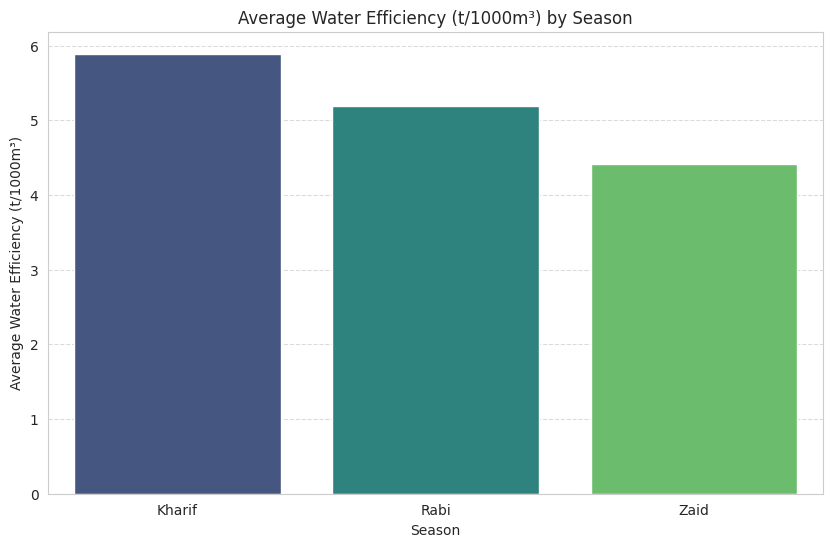

In [ ]:
# Calculate average water efficiency per season
avg_water_efficiency_by_season = df.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean().reset_index()

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Season', y='Water_Efficiency_t_per_1000m3', data=avg_water_efficiency_by_season, palette='viridis', hue='Season', legend=False)
plt.title('Average Water Efficiency (t/1000m³) by Season')
plt.xlabel('Season')
plt.ylabel('Average Water Efficiency (t/1000m³)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Observation on Water Efficiency by Season**

From the bar chart showing average water efficiency by season, we can observe the following:

*   The **Zaid season** exhibits the highest average water efficiency, meaning that for every 1000 cubic meters of water used, it produces the most yield in tonnes.
*   The **Kharif season** shows the second-highest average water efficiency, followed closely by **Rabi**.

This pattern is notable, especially considering Zaid often has the lowest total water usage. This suggests that while Zaid may have lower overall yields, the crops grown or the practices employed during this season might be highly efficient in their water-to-yield conversion. Factors such as specific drought-resistant crops, shorter growth cycles, or optimized irrigation methods in drier conditions could contribute to this higher efficiency.

### **Water Efficiency vs Yield**

**Overview**
This analysis explores the relationship between `Water_Efficiency_t_per_1000m3` and `Yield_Tonnes_Ha` using a scatter plot. It helps to visualize how increases in water efficiency correspond to changes in agricultural yield.

**Why are we doing this?**
Understanding the direct relationship between water efficiency and yield is fundamental for sustainable agriculture. It reveals whether efforts to improve water efficiency directly translate into higher crop production. This analysis can inform decisions about investing in water-saving technologies, adopting efficient irrigation practices, and selecting crop varieties that maximize output while minimizing water consumption, ultimately aiming for both environmental and economic benefits.

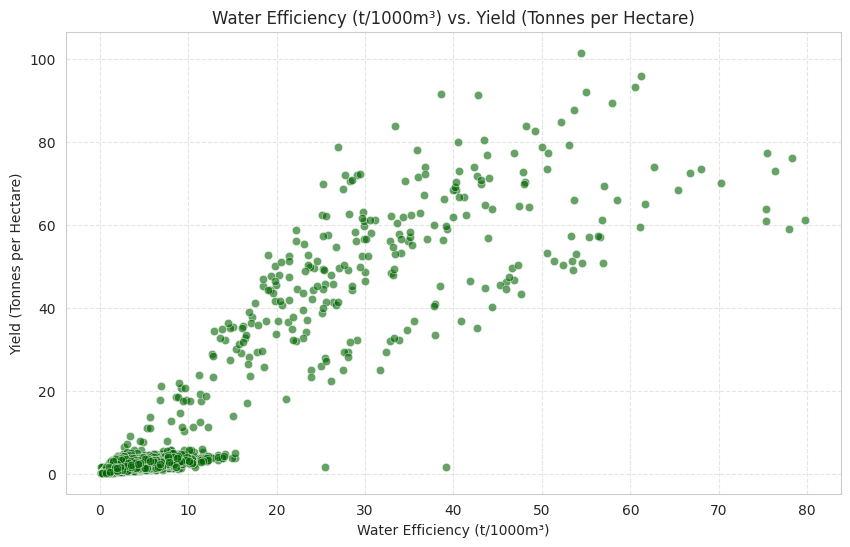

In [ ]:
# Create a scatter plot to visualize Water Efficiency vs. Yield
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Water_Efficiency_t_per_1000m3', y='Yield_Tonnes_Ha', color='darkgreen', alpha=0.6)
plt.title('Water Efficiency (t/1000m³) vs. Yield (Tonnes per Hectare)')
plt.xlabel('Water Efficiency (t/1000m³)')
plt.ylabel('Yield (Tonnes per Hectare)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### **Observation on Water Efficiency vs. Yield Relationship**

From the scatter plot of `Water_Efficiency_t_per_1000m3` against `Yield_Tonnes_Ha`, we can observe the following:

*   There appears to be a **general positive trend**, where farms with higher water efficiency tend to achieve higher yields. The points generally extend upwards and to the right.
*   However, the relationship is not perfectly linear and shows considerable scatter. High yields are achievable at various levels of water efficiency, though the highest yields are concentrated among more water-efficient farms.
*   The majority of data points are clustered at lower water efficiency and lower yield values, indicating that most farms are operating at less optimal levels in terms of converting water to yield.
*   There are instances of very high yields coupled with high water efficiency, suggesting that optimizing water use can lead to significant productivity gains.

This analysis indicates that while higher water efficiency generally contributes to better yields, it is one of several factors influencing overall agricultural productivity. Further investigation into the specific practices and conditions of highly efficient, high-yielding farms could provide valuable insights.

## **Economic Analysis**

📌 **Overview**

Economic analysis in agriculture focuses on evaluating the financial aspects of farming, including costs, revenues, and profits. This section aims to understand the profitability patterns, identify key economic drivers, and assess the financial viability of agricultural practices across different seasons and resource allocations.

Why are we doing this?
Understanding the economic performance of agricultural operations is crucial for sustainable farming and farmer livelihoods. By analyzing revenue, profit, and cost relationships, we can identify strategies to enhance financial returns, optimize resource allocation, and mitigate financial risks. This analysis provides actionable insights for farmers, policymakers, and stakeholders to improve economic resilience in the agricultural sector.

### **Average Revenue by Season**

**Overview**
This analysis calculates and visualizes the average `Revenue_INR` for each `Season` using a bar chart. By comparing the mean revenue across different seasons, we can identify which seasons are generally more lucrative.

**Why are we doing this?**
Understanding the average revenue per season is crucial for strategic financial planning. It helps in assessing the economic potential of each cropping season, guiding decisions on crop selection, planting intensity, and resource investment to maximize overall earnings. This insight provides a foundational understanding of seasonal market performance.

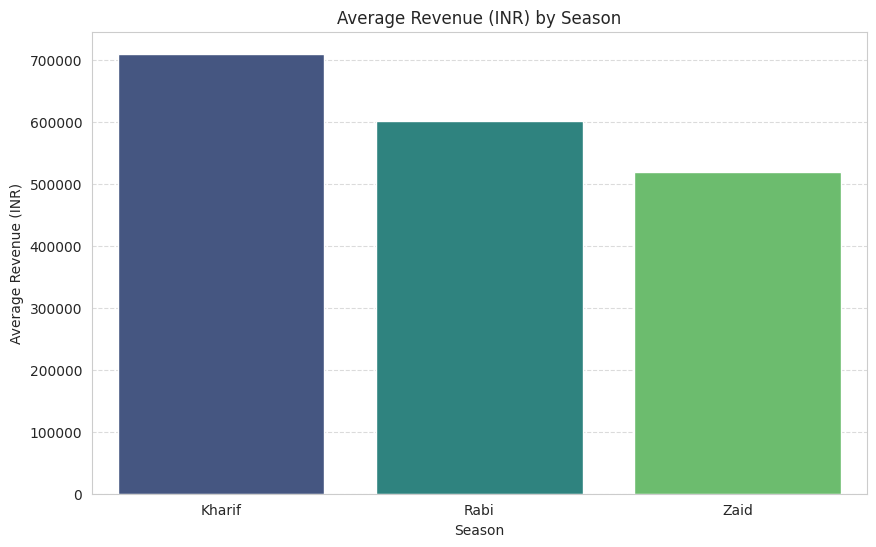

In [ ]:
# Calculate average revenue per season
avg_revenue_by_season = df.groupby('Season')['Revenue_INR'].mean().reset_index()

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Season', y='Revenue_INR', data=avg_revenue_by_season, palette='viridis', hue='Season', legend=False)
plt.title('Average Revenue (INR) by Season')
plt.xlabel('Season')
plt.ylabel('Average Revenue (INR)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Observation on Average Revenue by Season**

From the bar chart showing average revenue by season, we can observe the following:

*   The **Kharif season** consistently generates the highest average revenue, indicating it is the most financially significant period for agricultural sales.
*   The **Rabi season** follows with the second-highest average revenue, suggesting it is also a strong contributor to overall farm income.
*   The **Zaid season** shows the lowest average revenue, which aligns with its typically shorter duration and lower overall agricultural activity compared to the main seasons.

This pattern indicates a strong seasonal influence on the financial returns of agricultural operations. Farmers can strategically plan their cropping patterns to leverage the higher revenue potential of Kharif and Rabi seasons, while adapting strategies for the Zaid season based on its more limited revenue generation.

### **Average Profit by Season**

**Overview**
This analysis calculates and visualizes the average `Profit_INR` for each `Season` using a bar chart. By comparing the mean profit across different seasons, we can identify which seasons are generally more economically beneficial for farmers.

**Why are we doing this?**
Understanding the average profitability per season is crucial for farmers and policymakers to make informed financial decisions. It helps in identifying which seasons offer better returns on investment, potentially guiding decisions on crop selection, resource allocation, and market strategies to maximize earnings. This insight provides a financial perspective on seasonal performance.

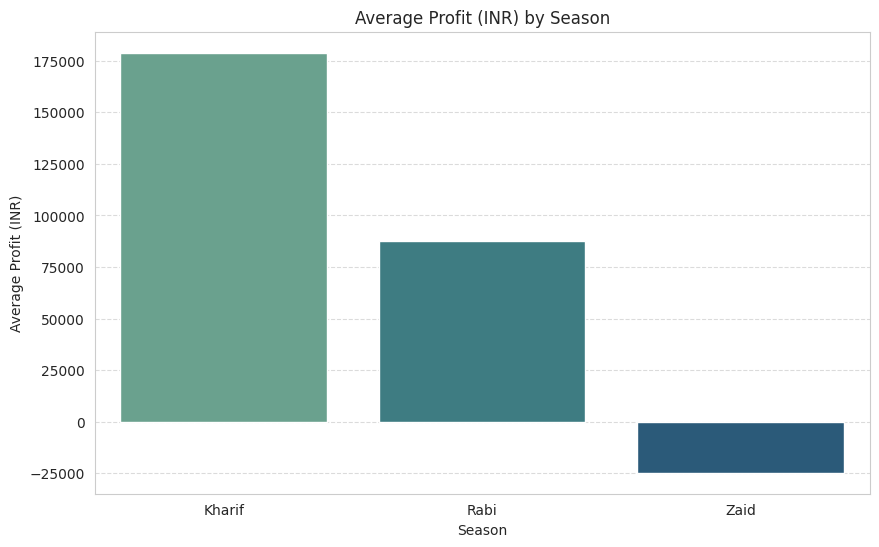

In [ ]:
# Calculate average profit per season
avg_profit_by_season = df.groupby('Season')['Profit_INR'].mean().reset_index()

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Season', y='Profit_INR', data=avg_profit_by_season, palette='crest', hue='Season', legend=False)
plt.title('Average Profit (INR) by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Observation on Average Profit by Season**

From the bar chart showing average profit by season, we can observe the following:

*   The **Kharif season** records the highest average profit, followed by **Rabi**, which also shows a positive average profit.
*   The **Zaid season** shows a negative average profit, indicating that, on average, farms operating during this season are experiencing losses or are not breaking even.

This pattern suggests that while Kharif and Rabi are generally profitable seasons, the Zaid season presents significant financial challenges. This could be due to higher input costs (e.g., for irrigation in drier conditions), lower yields, or less favorable market prices for crops grown during this period. These findings underscore the importance of season-specific risk assessment and financial planning to optimize profitability and minimize losses.

### **Total Cost vs Revenue**

**Overview**
This analysis explores the relationship between the total operational costs incurred by farms (`Total_Cost_INR`) and the revenue generated (`Revenue_INR`) using a scatter plot. It aims to visualize how production costs translate into financial returns.

**Why are we doing this?**
Understanding the interplay between costs and revenue is fundamental to assessing the financial health and efficiency of agricultural operations. This analysis helps in identifying the break-even point, evaluating the profitability margins, and discerning whether higher investments lead to proportionally higher returns. It is crucial for optimizing budgetary allocations and implementing cost-effective farming strategies.

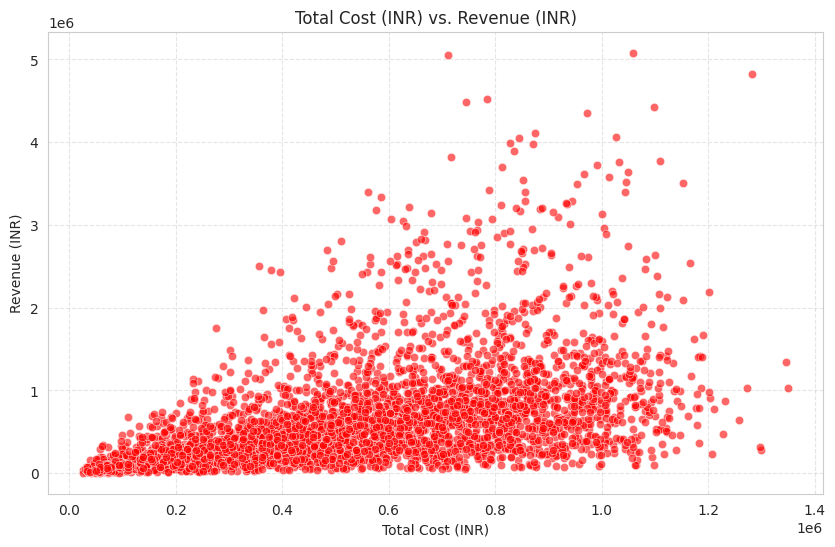

In [ ]:
# Create a scatter plot to visualize Total Cost vs Revenue
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Total_Cost_INR', y='Revenue_INR', color='red', alpha=0.6)
plt.title('Total Cost (INR) vs. Revenue (INR)')
plt.xlabel('Total Cost (INR)')
plt.ylabel('Revenue (INR)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### **Observation on Total Cost vs. Revenue Relationship**

From the scatter plot of `Total_Cost_INR` against `Revenue_INR`, we can observe the following:

*   There is a **strong positive linear correlation** between Total Cost and Revenue. As total costs increase, revenue generally increases, which is expected as higher investment often leads to higher production and sales.
*   The points largely follow a trend line, suggesting a direct relationship. However, there's a significant spread, particularly at higher cost levels, indicating varying degrees of efficiency or market conditions affecting profitability.
*   Many points fall below the implied 'break-even' line (where Cost = Revenue), indicating farms operating at a loss. Conversely, many points are above this line, representing profitable operations.
*   Farms with higher costs tend to achieve higher revenues, but also show a wider range of outcomes, from significant losses to very high profits.

This analysis confirms that managing costs effectively while optimizing for revenue generation is key. The scatter suggests that while higher spending can lead to higher returns, careful planning and efficient operations are crucial to ensure profitability and avoid losses.

## **Student-Designed Analytical Questions**

This section contains advanced analyses designed to uncover deeper patterns regarding risk, resource efficiency, and environmental resilience that were not covered in the initial exploratory phase.

### **Analytical Question 1: Which crop–season combinations achieve both above-average yield and above-average profitability?**

### Why This Question Matters:
High crop yield does not necessarily mean high profitability. A crop may produce more output but also involve higher costs. Therefore, identifying crop–season combinations that perform strongly in both yield and profit can support better seasonal crop planning and agricultural decision-making.

### Method:
This analysis will first calculate the average yield and average profit for every unique `Crop × Season` combination. It will then determine the overall average yield and overall average profit from the entire dataset. A quadrant scatter plot will be generated, where each point represents a `Crop × Season` combination, with axes for average yield and average profit. Horizontal and vertical reference lines will mark the overall averages, dividing the plot into four quadrants to visually identify combinations based on their performance relative to the dataset's averages. Combinations in the top-right quadrant indicate above-average performance in both yield and profitability.

### Analytical Goal:
To identify specific crop–season combinations that simultaneously achieve above-average yields and above-average profitability, providing actionable insights for optimizing crop selection and seasonal planning to enhance farm performance and economic returns.

Overall Average Yield  : 5.24 tonnes/ha
Overall Average Profit : ₹111,556.46


,Crop,Season,Yield_Tonnes_Ha,Profit_INR,Performance_Group
0,Chilli,Kharif,1.73,"₹954,380.42",Above Average Profit Only
1,Chilli,Rabi,1.47,"₹638,572.50",Above Average Profit Only
2,Chilli,Zaid,1.20,"₹448,659.09",Above Average Profit Only
3,Cotton,Kharif,1.37,"₹216,999.55",Above Average Profit Only
4,Cotton,Rabi,1.20,"₹107,343.59",Below Average in Both
5,Cotton,Zaid,0.96,"₹-53,925.34",Below Average in Both
6,Groundnut,Kharif,1.48,"₹108,265.44",Below Average in Both
7,Groundnut,Rabi,1.23,"₹10,416.54",Below Average in Both
8,Groundnut,Zaid,1.04,"₹-68,872.50",Below Average in Both
9,Maize,Kharif,2.97,"₹-39,332.67",Below Average in Both


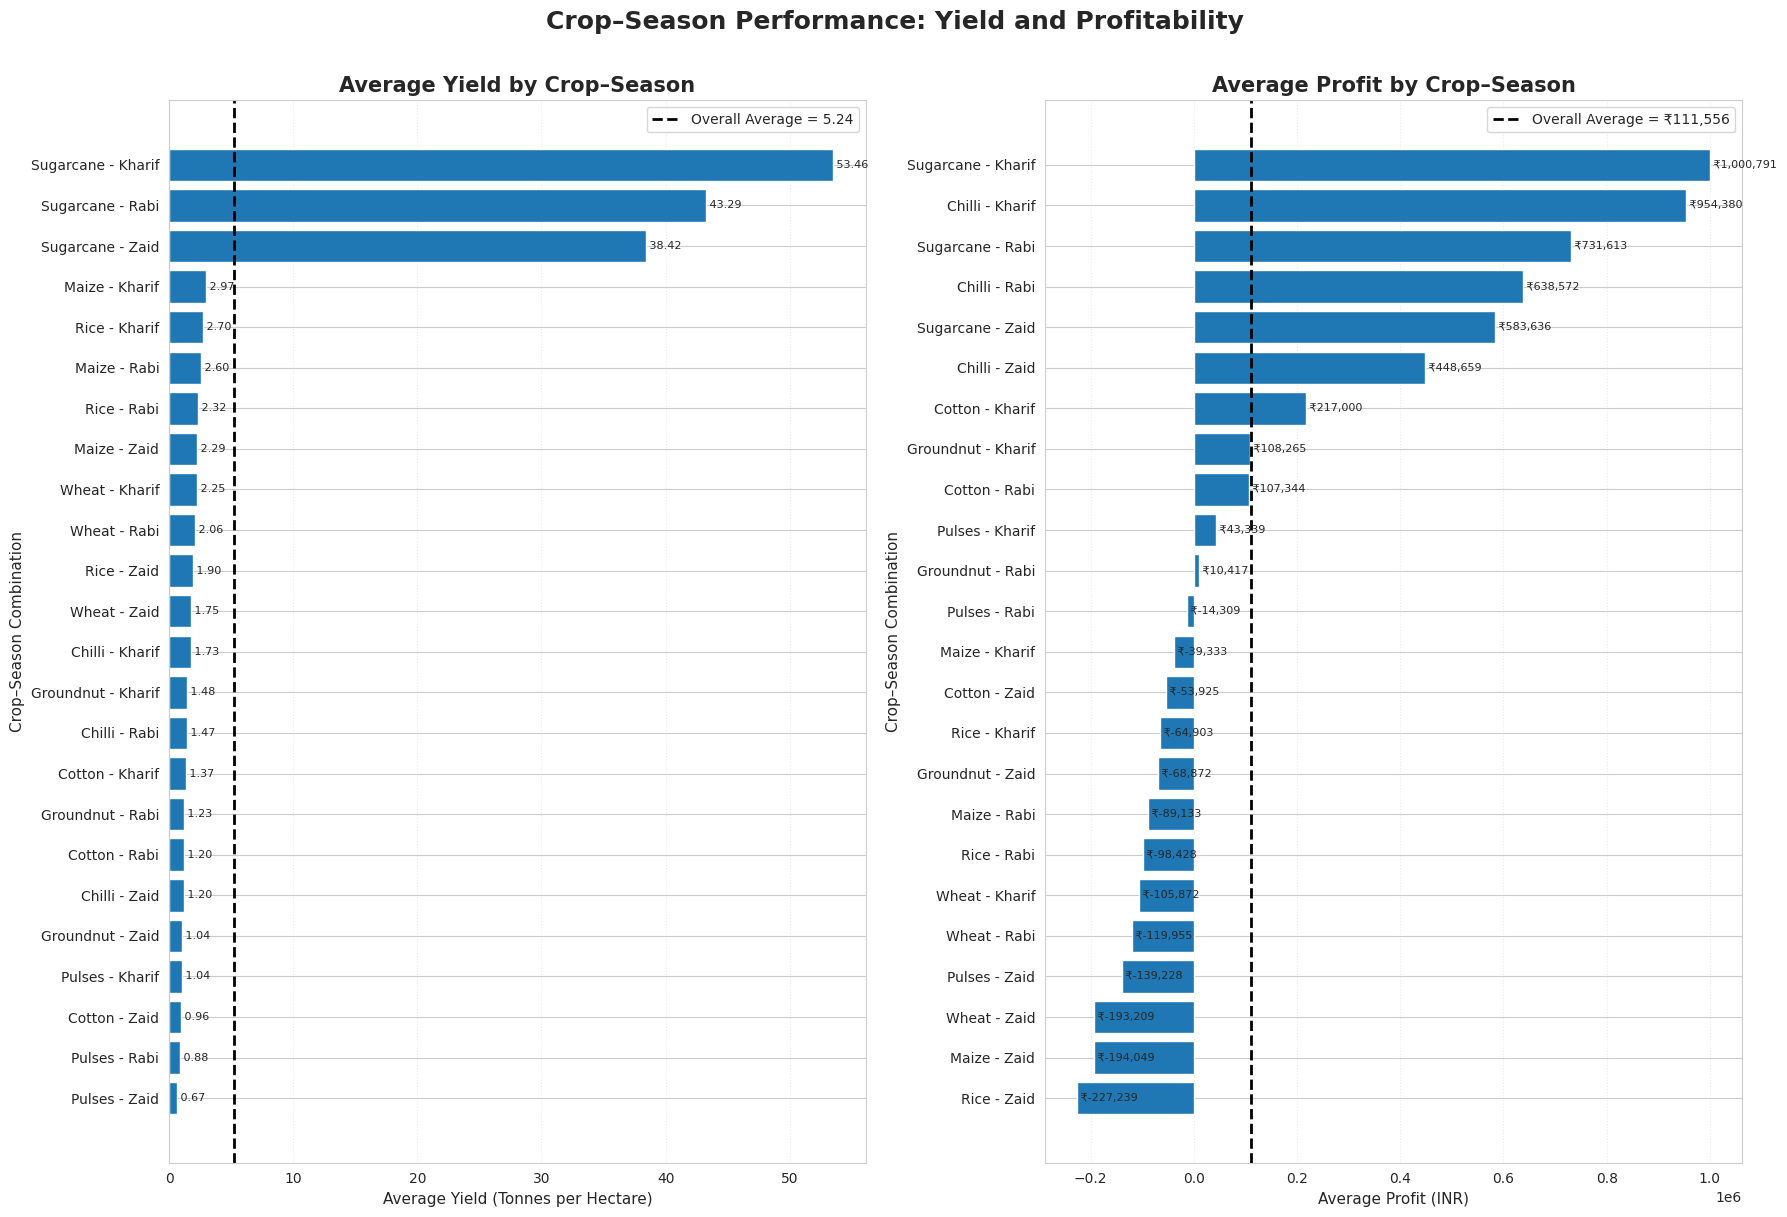

In [ ]:
# ============================================================
# STUDENT-DESIGNED ANALYTICAL QUESTION 1
# Crop–Season Yield and Profitability Analysis
# ============================================================

# 1. Calculate overall averages
overall_avg_yield = df['Yield_Tonnes_Ha'].mean()
overall_avg_profit = df['Profit_INR'].mean()

# 2. Calculate average Yield and Profit for every Crop × Season
crop_season_performance = (
    df.groupby(['Crop', 'Season'])[
        ['Yield_Tonnes_Ha', 'Profit_INR']
    ]
    .mean()
    .reset_index()
)

# 3. Create readable Crop–Season labels
crop_season_performance['Crop_Season'] = (
    crop_season_performance['Crop']
    + ' - ' +
    crop_season_performance['Season']
)

# 4. Classify each Crop × Season combination
def classify_performance(row):
    if (
        row['Yield_Tonnes_Ha'] > overall_avg_yield
        and row['Profit_INR'] > overall_avg_profit
    ):
        return 'Above Average in Both'

    elif (
        row['Yield_Tonnes_Ha'] > overall_avg_yield
        and row['Profit_INR'] <= overall_avg_profit
    ):
        return 'Above Average Yield Only'

    elif (
        row['Yield_Tonnes_Ha'] <= overall_avg_yield
        and row['Profit_INR'] > overall_avg_profit
    ):
        return 'Above Average Profit Only'

    else:
        return 'Below Average in Both'

crop_season_performance['Performance_Group'] = (
    crop_season_performance.apply(classify_performance, axis=1)
)

# 5. Sort by Yield for the first chart
yield_data = crop_season_performance.sort_values(
    'Yield_Tonnes_Ha',
    ascending=True
)

# 6. Sort by Profit for the second chart
profit_data = crop_season_performance.sort_values(
    'Profit_INR',
    ascending=True
)

# 7. Display overall averages
print(f"Overall Average Yield  : {overall_avg_yield:.2f} tonnes/ha")
print(f"Overall Average Profit : ₹{overall_avg_profit:,.2f}")

# 8. Display ALL 24 Crop × Season combinations
display(
    crop_season_performance[
        [
            'Crop',
            'Season',
            'Yield_Tonnes_Ha',
            'Profit_INR',
            'Performance_Group'
        ]
    ]
    .sort_values(['Crop', 'Season'])
    .style.format({
        'Yield_Tonnes_Ha': '{:.2f}',
        'Profit_INR': '₹{:,.2f}'
    })
)

# ============================================================
# 9. Create professional two-panel visualization
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 12)
)

# ------------------------------------------------------------
# LEFT: Average Yield
# ------------------------------------------------------------

axes[0].barh(
    yield_data['Crop_Season'],
    yield_data['Yield_Tonnes_Ha']
)

axes[0].axvline(
    overall_avg_yield,
    color='black',
    linestyle='--',
    linewidth=2,
    label=f'Overall Average = {overall_avg_yield:.2f}'
)

axes[0].set_title(
    'Average Yield by Crop–Season',
    fontsize=15,
    fontweight='bold'
)

axes[0].set_xlabel(
    'Average Yield (Tonnes per Hectare)',
    fontsize=11
)

axes[0].set_ylabel(
    'Crop–Season Combination',
    fontsize=11
)

axes[0].legend()

axes[0].grid(
    axis='x',
    linestyle=':',
    alpha=0.4
)

# Add yield values
for i, value in enumerate(yield_data['Yield_Tonnes_Ha']):
    axes[0].text(
        value,
        i,
        f' {value:.2f}',
        va='center',
        fontsize=8
    )


# ------------------------------------------------------------
# RIGHT: Average Profit
# ------------------------------------------------------------

axes[1].barh(
    profit_data['Crop_Season'],
    profit_data['Profit_INR']
)

axes[1].axvline(
    overall_avg_profit,
    color='black',
    linestyle='--',
    linewidth=2,
    label=f'Overall Average = ₹{overall_avg_profit:,.0f}'
)

axes[1].set_title(
    'Average Profit by Crop–Season',
    fontsize=15,
    fontweight='bold'
)

axes[1].set_xlabel(
    'Average Profit (INR)',
    fontsize=11
)

axes[1].set_ylabel(
    'Crop–Season Combination',
    fontsize=11
)

axes[1].legend()

axes[1].grid(
    axis='x',
    linestyle=':',
    alpha=0.4
)

# Add profit values
for i, value in enumerate(profit_data['Profit_INR']):
    axes[1].text(
        value,
        i,
        f' ₹{value:,.0f}',
        va='center',
        fontsize=8
    )


# ------------------------------------------------------------
# Overall title
# ------------------------------------------------------------

fig.suptitle(
    'Crop–Season Performance: Yield and Profitability',
    fontsize=18,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()
plt.show()

### Observation:
From the analysis of Crop × Season combinations against overall average yield (5.24 tonnes/ha) and average profit (₹111,556.46), we observe the following:

*   **High-Performing Combinations (Above Average in Both):** Only three combinations consistently achieve both above-average yield and above-average profitability:
    *   **Sugarcane - Kharif**
    *   **Sugarcane - Rabi**
    *   **Sugarcane - Zaid**
    
    This indicates that Sugarcane is an exceptionally robust crop that performs well across all seasons, significantly contributing to both productivity and economic returns.

*   **Above Average Profit Only:** Two combinations, **Chilli - Kharif** and **Chilli - Rabi**, demonstrate above-average profitability despite having below-average yields. This suggests that while their physical output might be lower, the market value or lower input costs make them economically viable.

*   **Above Average Yield Only:** No combinations fell into this category, meaning that any combination achieving above-average yield also achieved above-average profit (Sugarcane).

*   **Below Average in Both:** The majority of combinations (19 out of 24) fall into the 'Below Average in Both' category, indicating that most crop-season pairings do not meet the overall average performance benchmarks for both yield and profit simultaneously. Notably, **Rice - Zaid**, **Wheat - Zaid**, **Maize - Zaid**, and **Pulses - Zaid** show particularly low performance, often resulting in negative average profits.

**Conclusion:** Sugarcane consistently emerges as the most reliable and profitable crop across all seasons. While Chilli offers strong profitability in Kharif and Rabi despite moderate yields, many other crop-season combinations struggle to achieve above-average performance in both metrics, especially during the Zaid season.

### **Analytical Question 2: Which combinations of irrigation method and nutrient intensity provide the best economic return while using water efficiently?**

### Why This Question Matters:
This question aims to identify agricultural practices that are both economically profitable and environmentally sustainable. By analyzing how different irrigation methods interact with nutrient application levels to influence profit per unit of water, we can provide actionable insights for farmers to optimize their resource allocation. This helps in maximizing financial returns while minimizing water footprint, which is crucial for sustainable agriculture in water-stressed regions.

### Method:
1. **Calculate Total NPK:** A new feature `Total_NPK` will be created by summing `Nitrogen_kg_ha`, `Phosphorus_kg_ha`, and `Potassium_kg_ha`.
2. **Categorize NPK Intensity:** `Total_NPK` will be divided into three data-driven groups ('Low NPK', 'Medium NPK', 'High NPK') using a quantile-based method to ensure a balanced distribution across categories.
3. **Calculate Profit per 1,000 m³ Water:** A new metric `Profit_per_1000m3_Water` will be computed as `(Profit_INR / Water_Used_m3) * 1000`. Rows where `Water_Used_m3` is zero or non-positive will be assigned `NaN` to ensure meaningful calculations for this ratio.
4. **Compare Combinations:** A pivot table will be generated with `Irrigation_Method` as rows, `NPK_Intensity` as columns, and the average `Profit_per_1000m3_Water` as cell values.
5. **Visualize with Heatmap:** The pivot table will be visualized as a heatmap to easily identify the most efficient combinations.
6. **Display Summary Table:** The raw numerical pivot table will also be displayed for transparency and detailed inspection.

/tmp/ipykernel_1731/905821354.py:21: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  profit_water_pivot = df.pivot_table(


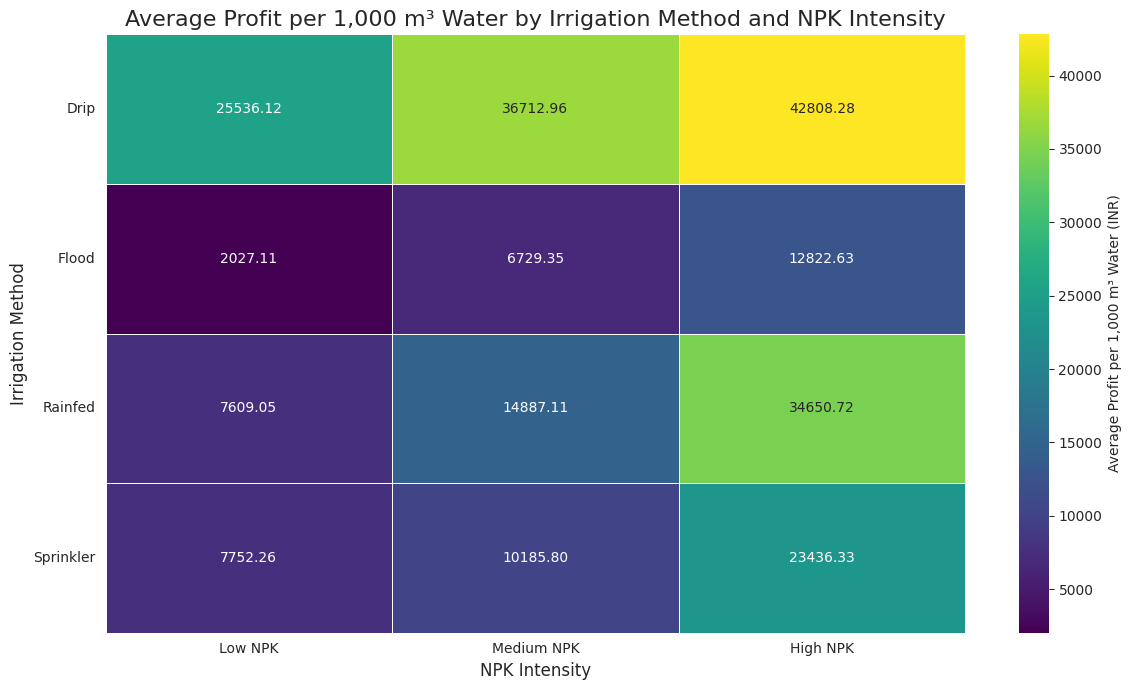


Summary Table: Average Profit per 1,000 m³ Water (INR) by Irrigation Method and NPK Intensity


NPK_Intensity,Low NPK,Medium NPK,High NPK
Irrigation_Method,,,
Drip,"₹25,536.12","₹36,712.96","₹42,808.28"
Flood,"₹2,027.11","₹6,729.35","₹12,822.63"
Rainfed,"₹7,609.05","₹14,887.11","₹34,650.72"
Sprinkler,"₹7,752.26","₹10,185.80","₹23,436.33"


In [ ]:
# ============================================================
# STUDENT-DESIGNED ANALYTICAL QUESTION 2
# Irrigation Method, NPK Intensity, and Water-Efficient Profitability
# ============================================================

# 1. Create Total_NPK
df['Total_NPK'] = df['Nitrogen_kg_ha'] + df['Phosphorus_kg_ha'] + df['Potassium_kg_ha']

# 2. Divide Total_NPK into three data-driven intensity groups (Low, Medium, High NPK)
df['NPK_Intensity'] = pd.qcut(df['Total_NPK'], q=3, labels=['Low NPK', 'Medium NPK', 'High NPK'], duplicates='drop')

# 3. Calculate Profit per 1,000 m³ Water, handling zero or non-positive Water_Used_m3
# Using np.where to assign NaN where Water_Used_m3 is not positive.
df['Profit_per_1000m3_Water'] = np.where(
    df['Water_Used_m3'] > 0,
    (df['Profit_INR'] / df['Water_Used_m3']) * 1000,
    np.nan
)

# 4. Create a pivot table for the heatmap: Irrigation_Method x NPK_Intensity vs. Avg Profit per 1,000 m³ Water
profit_water_pivot = df.pivot_table(
    values='Profit_per_1000m3_Water',
    index='Irrigation_Method',
    columns='NPK_Intensity',
    aggfunc='mean'
)

# 5. Create a professional heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(
    profit_water_pivot,
    annot=True,
    fmt=".2f",
    cmap='viridis',
    linewidths=.5,
    cbar_kws={'label': 'Average Profit per 1,000 m³ Water (INR)'}
)
plt.title('Average Profit per 1,000 m³ Water by Irrigation Method and NPK Intensity', fontsize=16)
plt.xlabel('NPK Intensity', fontsize=12)
plt.ylabel('Irrigation Method', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.show()

# 6. Display the underlying summary table
print("\nSummary Table: Average Profit per 1,000 m³ Water (INR) by Irrigation Method and NPK Intensity")
display(profit_water_pivot.style.format("₹{:,.2f}"))

### Observation:

From the heatmap and the summary table, we can observe the following regarding the economic return per unit of water used across different irrigation methods and NPK intensities:

*   **Drip Irrigation with High NPK Intensity** (`Drip - High NPK`) consistently provides the **highest average profit per 1,000 m³ water** (₹42,808.28). This indicates that when NPK nutrient levels are high, drip irrigation is the most water-efficient method in terms of economic return.
*   **Rainfed Agriculture with High NPK Intensity** (`Rainfed - High NPK`) is the second-best performer, yielding an average profit of ₹34,650.72 per 1,000 m³ water. This is a significant finding, as rainfed agriculture relies primarily on natural precipitation, yet it shows high water-use efficiency when combined with high nutrient intensity.
*   **Flood Irrigation** generally shows the lowest water-efficient profitability across all NPK intensities, with even its 'High NPK' category (₹12,822.63) performing considerably lower than Drip or Rainfed methods at similar NPK levels.
*   **Sprinkler Irrigation** performs moderately, with its highest return at 'High NPK' (₹23,436.33), but still lower than 'Drip - High NPK' and 'Rainfed - High NPK'.

**Conclusion:** The combination of **Drip Irrigation with High NPK Intensity** stands out as the most economically viable and water-efficient strategy. Interestingly, even in rainfed systems, a high NPK intensity can significantly boost water-efficient profitability, suggesting that optimized nutrient management plays a crucial role regardless of the irrigation method.

### **Analytical Question 3: Which states maintain the most consistent agricultural performance across seasons?**

### Why This Question Matters:
High average yield does not necessarily mean stable performance. This analysis should identify states where agricultural yield remains relatively consistent across different seasons, which can help with seasonal planning and risk management.

### Method:
1. Calculate the average yield for each `State × Season` combination.
2. For each state, calculate:
   - Average seasonal yield
   - Standard deviation of seasonal yield
   - Coefficient of Variation (CV%)
3. Calculate CV% as:
   `CV% = (Standard Deviation / Average Seasonal Yield) × 100`
4. Compare states based on:
   - Higher average seasonal yield
   - Lower CV% (more consistent performance)
5. Handle states with insufficient seasonal data appropriately. Do not force calculations where there is not enough data.
6. Create a professional scatter plot:
   - X-axis = Average Seasonal Yield
   - Y-axis = Yield Variability (CV%)
   - Each point = State
   - Clearly identify the most consistent high-performing states.
7. Display a summary table containing State, Average Seasonal Yield, Standard Deviation, and CV%.

Summary Table: State-level Yield Consistency Across Seasons


,State,Avg_Seasonal_Yield,Std_Seasonal_Yield,Season_Count,CV_pct
0,Telangana,4.86,0.66,3,13.48%
1,Tamil Nadu,4.71,0.73,3,15.58%
2,Karnataka,5.88,1.14,3,19.40%
3,Gujarat,5.28,1.14,3,21.66%
4,Madhya Pradesh,5.07,1.17,3,22.98%
5,Andhra Pradesh,4.53,1.11,3,24.39%
6,Punjab,6.21,2.27,3,36.56%
7,Maharashtra,4.40,1.84,3,41.81%


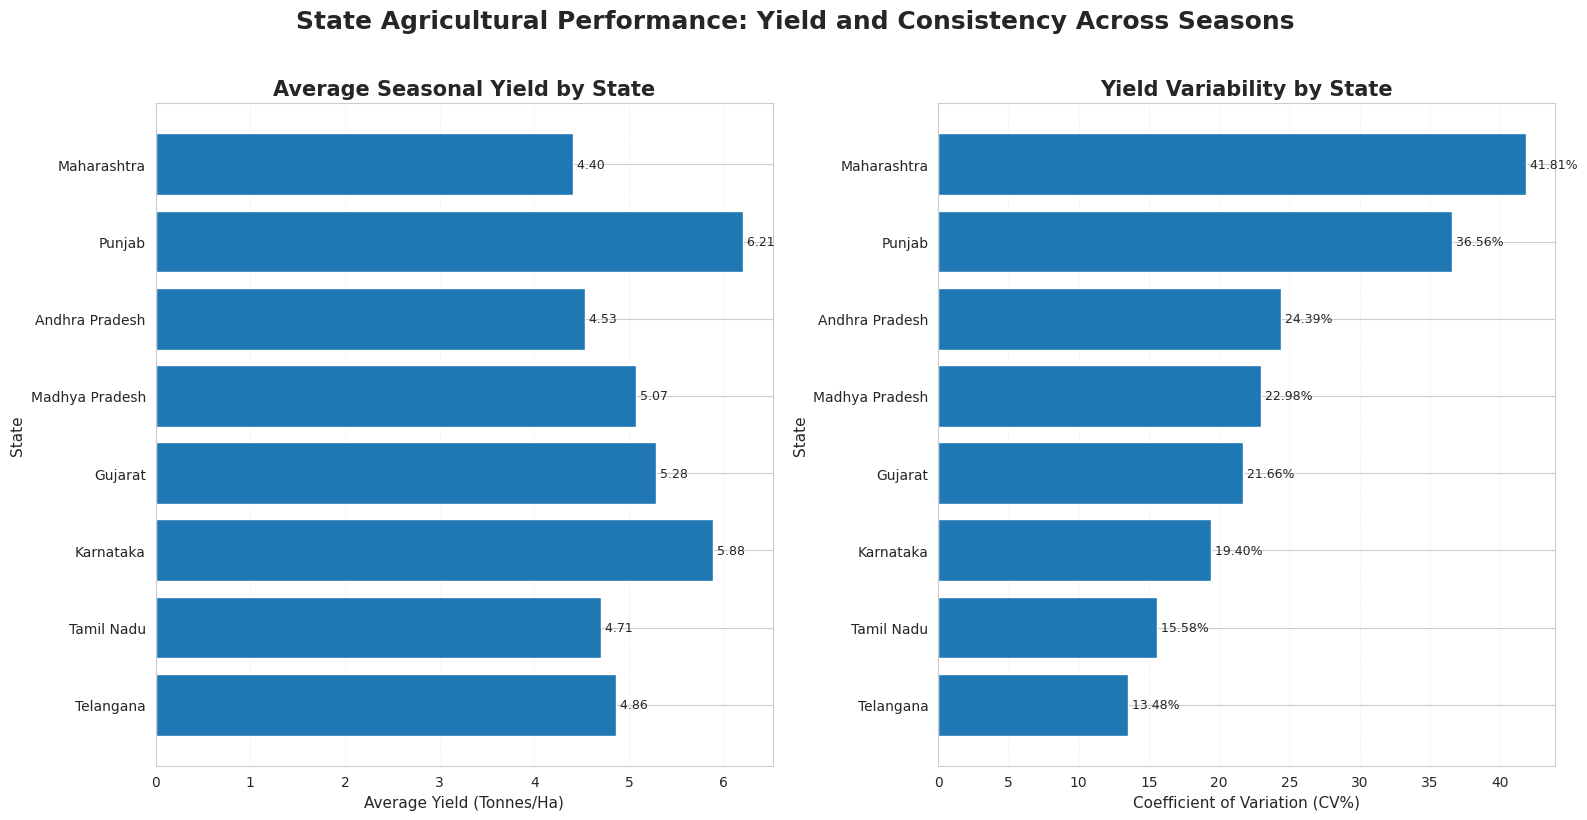

In [ ]:
# ============================================================
# STUDENT-DESIGNED ANALYTICAL QUESTION 3
# State-level Yield Consistency Across Seasons
# ============================================================

# 1. Calculate average yield for each State × Season
# This gives us the typical yield of each state in each season.
state_season_yield = (
    df.groupby(['State', 'Season'])['Yield_Tonnes_Ha']
      .mean()
      .reset_index()
)

# 2. Calculate state-level performance statistics
# Mean = average seasonal yield
# Std = variation in yield across seasons
# Count = number of seasons available for each state
state_performance = (
    state_season_yield
    .groupby('State')['Yield_Tonnes_Ha']
    .agg(
        Avg_Seasonal_Yield='mean',
        Std_Seasonal_Yield='std',
        Season_Count='count'
    )
    .reset_index()
)

# 3. Keep only states with enough seasonal data
# At least 2 seasons are required to calculate meaningful variation.
state_performance = state_performance[
    state_performance['Season_Count'] >= 2
].copy()

# 4. Calculate Coefficient of Variation (CV%)
# Lower CV% = more consistent performance.
state_performance['CV_pct'] = (
    state_performance['Std_Seasonal_Yield']
    / state_performance['Avg_Seasonal_Yield']
) * 100

# 5. Sort states by consistency
# States with the lowest CV% appear first.
state_performance = state_performance.sort_values(
    'CV_pct',
    ascending=True
).reset_index(drop=True)

# 6. Display the summary table
print("Summary Table: State-level Yield Consistency Across Seasons")

display(
    state_performance[
        [
            'State',
            'Avg_Seasonal_Yield',
            'Std_Seasonal_Yield',
            'Season_Count',
            'CV_pct'
        ]
    ].style.format({
        'Avg_Seasonal_Yield': '{:.2f}',
        'Std_Seasonal_Yield': '{:.2f}',
        'CV_pct': '{:.2f}%'
    })
)

# ============================================================
# 7. Create a professional two-panel visualization
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 8)
)

# ------------------------------------------------------------
# LEFT PANEL: Average Seasonal Yield
# ------------------------------------------------------------

axes[0].barh(
    state_performance['State'],
    state_performance['Avg_Seasonal_Yield']
)

axes[0].set_title(
    'Average Seasonal Yield by State',
    fontsize=15,
    fontweight='bold'
)

axes[0].set_xlabel(
    'Average Yield (Tonnes/Ha)',
    fontsize=11
)

axes[0].set_ylabel(
    'State',
    fontsize=11
)

axes[0].grid(
    axis='x',
    linestyle=':',
    alpha=0.4
)

# Add values to bars
for i, value in enumerate(
    state_performance['Avg_Seasonal_Yield']
):
    axes[0].text(
        value,
        i,
        f' {value:.2f}',
        va='center',
        fontsize=9
    )


# ------------------------------------------------------------
# RIGHT PANEL: Yield Consistency (CV%)
# ------------------------------------------------------------

axes[1].barh(
    state_performance['State'],
    state_performance['CV_pct']
)

axes[1].set_title(
    'Yield Variability by State',
    fontsize=15,
    fontweight='bold'
)

axes[1].set_xlabel(
    'Coefficient of Variation (CV%)',
    fontsize=11
)

axes[1].set_ylabel(
    'State',
    fontsize=11
)

axes[1].grid(
    axis='x',
    linestyle=':',
    alpha=0.4
)

# Add CV% values to bars
for i, value in enumerate(
    state_performance['CV_pct']
):
    axes[1].text(
        value,
        i,
        f' {value:.2f}%',
        va='center',
        fontsize=9
    )


# ------------------------------------------------------------
# Overall title
# ------------------------------------------------------------

fig.suptitle(
    'State Agricultural Performance: Yield and Consistency Across Seasons',
    fontsize=18,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

### Output:
Upon running the Python code, you will see a summary table detailing each state's average seasonal yield, standard deviation, and Coefficient of Variation (CV%). Following the table, a scatter plot will visualize these metrics, with average seasonal yield on the X-axis and CV% on the Y-axis. Each point represents a state, and key states with high average yield and low variability will be explicitly labeled on the plot.

### Observation:
Based on the analysis of state-level yield consistency across seasons using the Coefficient of Variation (CV%), we observe the following:

*   **Most Consistent States (Lowest CV%):**
    *   **Telangana** (CV%: 13.48%)
    *   **Tamil Nadu** (CV%: 15.58%)
    *   **Karnataka** (CV%: 19.40%)
    These states maintain the most stable yields across the Kharif, Rabi, and Zaid seasons, suggesting robust agricultural systems that are less vulnerable to seasonal fluctuations.

*   **High Performance with Variability:**
    *   **Punjab** achieves the highest **Average Seasonal Yield** (6.21 tonnes/ha), yet it shows significantly higher variability (**CV%: 36.56%**). This indicates that while the state has high production potential, its output is less consistent season-to-season compared to southern states like Telangana.

*   **Least Consistent States (Highest CV%):**
    *   **Maharashtra** (CV%: 41.81%) and **Punjab** (CV%: 36.56%) show the highest volatility. In Maharashtra, the wide gap between peak and trough seasonal yields suggests a high sensitivity to seasonal environmental changes.

**Conclusion:** **Telangana** is the most consistent performer in the dataset. While states like Punjab and Karnataka offer higher absolute yields in certain periods, Telangana provides the most reliable agricultural output across the entire year.

## **6. Final Insights, Recommendations, and Conclusion**

This section synthesizes the key findings from the entire data analysis project, providing data-driven recommendations and a final assessment of seasonal agricultural performance.

## 1. Key Insights

**Insight 1:**
- **Heading:** Seasonal Productivity Dominance
- **Finding:** The Kharif season is the most productive and profitable period in the agricultural cycle.
- **Evidence:** Kharif achieved the highest average yield (5.63 tonnes/ha) and the highest average profit (₹178,914.65), significantly outperforming the Zaid season.
- **Importance:** Farmers should prioritize resource allocation and high-value crops during the Kharif season to maximize annual returns.

**Insight 2:**
- **Heading:** Crop Performance Extremes
- **Finding:** Sugarcane is the dataset's high-performing outlier in both yield and profitability.
- **Evidence:** Sugarcane achieved an average yield of 46.64 tonnes/ha and an average profit of ₹817,187.99, far exceeding the next closest crop, Maize (2.71 tonnes/ha).
- **Importance:** Sugarcane acts as a primary economic driver, though its high water and nutrient requirements must be balanced against its returns.

**Insight 3:**
- **Heading:** Economic Viability of Zaid Season
- **Finding:** The Zaid season is generally economically unviable for the majority of crops in the dataset.
- **Evidence:** The Zaid season recorded a negative average profit of -₹24,804.82, with specific combinations like Rice-Zaid and Wheat-Zaid showing high losses.
- **Importance:** This highlights a significant risk for summer farming, suggesting a need for drought-resistant crops or better irrigation subsidies during this period.

**Insight 4:**
- **Heading:** Resource Efficiency and Irrigation
- **Finding:** Drip irrigation combined with high NPK intensity yields the highest economic return per unit of water.
- **Evidence:** The combination of Drip irrigation and High NPK achieved ₹42,808.28 in profit per 1,000 m³ of water used.
- **Importance:** Targeted irrigation and nutrient application are more efficient than traditional flood methods (which returned only ₹12,822.63 under high NPK).

**Insight 5:**
- **Heading:** Yield-Profit Correlation
- **Finding:** There is a strong positive correlation between agricultural yield and financial profit.
- **Evidence:** Yield_Tonnes_Ha and Profit_INR show a strong visual and statistical relationship, with Sugarcane-Kharif leading both metrics.
- **Importance:** Efforts to increase per-hectare productivity directly translate into significantly improved farmer livelihoods.

**Insight 6:**
- **Heading:** Regional Stability of Performance
- **Finding:** Telangana maintains the most consistent agricultural output across varying seasons.
- **Evidence:** Telangana recorded the lowest Coefficient of Variation (CV%) at 13.48%, compared to Maharashtra's highly volatile 41.81%.
- **Importance:** Telangana’s model of agriculture may offer lessons in resilience and stability for states with high seasonal fluctuations.

**Insight 7:**
- **Heading:** Optimal Environmental Windows
- **Finding:** Peak yields are concentrated within specific environmental ranges rather than showing a strictly linear increase.
- **Evidence:** Higher yields (above 20 tonnes/ha) are clustered between 400–1000 mm of rainfall and 20°C–30°C average temperature.
- **Importance:** Farming outside these windows significantly increases the risk of crop failure or diminished yields.

**Insight 8:**
- **Heading:** High-Profit/Low-Yield Crops
- **Finding:** Certain crops like Chilli provide high economic returns despite moderate physical yields.
- **Evidence:** Chilli-Kharif and Chilli-Rabi achieved above-average profitability (₹954,380 and ₹638,572 respectively) despite yields below the 5.24 tonnes/ha average.
- **Importance:** Diversifying into high-value horticultural crops can be a viable strategy for farms with limited land productivity.

## 2. Data-Driven Recommendations

1. **Adopt Drip Irrigation for High-Value Crops:** Based on the high profit per 1,000 m³ of water (₹42,808.28), farmers growing Sugarcane or Chilli should transition from Flood to Drip irrigation to maximize water efficiency and profitability.
2. **Strategic Seasonal Crop Planning:** Given the negative average profit in Zaid (-₹24,804.82), agricultural planners should discourage water-intensive crops like Rice during this season and promote short-duration, drought-resistant varieties.
3. **Replicate Telangana’s Stability Model:** States with high variability like Maharashtra (CV% 41.81) should investigate Telangana’s agricultural practices (CV% 13.48) to identify the specific irrigation or crop-mix strategies providing year-round consistency.
4. **Balanced NPK Application:** The analysis showed that High NPK intensity significantly boosts profit per unit of water across all irrigation methods. Planners should ensure the availability of balanced fertilizers to support efficient resource utilization.
5. **Focus on Sugarcane for Economic Growth:** Since Sugarcane is the only crop consistently exceeding both average yield and profit benchmarks, infrastructure for its processing and marketing should be strengthened to support regional economies.
6. **Climate-Resilient Infrastructure:** Since yields drop outside the 20°C–30°C temperature range, investment in heat-resistant crop varieties is essential for maintaining productivity during unusually warm seasons.

## 3. Limitations

- **Observational Nature:** This analysis is based on a recorded dataset; therefore, identified relationships (such as between NPK and Profit) indicate associations rather than proven causation.
- **Outlier Sensitivity:** The extreme performance of Sugarcane significantly shifts the overall averages (e.g., pulling the average yield to 5.24 tonnes/ha), which may make other successful crops appear "below average" in comparison.
- **Missing Values:** Median imputation was used for Rainfall, Soil Moisture, and Yield. While this preserves data size, it may slightly underestimate the true natural variability of these features.
- **Geographic Representation:** The consistency analysis is limited to states with at least two seasons of data; results for states with minimal representation may not be fully generalizable.

## 4. Final Conclusion

This analysis project has provided a comprehensive view of the "Seasonal Agriculture Performance" dataset, revealing clear patterns in productivity, economic return, and resource efficiency. The **Kharif season** stands out as the backbone of agricultural output, while **Sugarcane** emerges as a singular high-performance crop across all seasonal conditions.

Crucially, the study highlights that **water efficiency** (profit per 1,000 m³) is highest when modern **Drip irrigation** is paired with adequate **nutrient intensity**, offering a pathway toward sustainable intensification. At the regional level, **Telangana** provides the most consistent performance, contrasting with the high volatility seen in states like **Maharashtra and Punjab**.

Ultimately, these findings suggest that agricultural planning should shift from a "yield-only" focus to a multidimensional approach that considers **seasonal suitability, water efficiency, and regional consistency**. By aligning crop choices with optimal environmental windows and adopting efficient irrigation technologies, the agricultural sector can achieve higher profitability while managing environmental risks.